<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/09_exploratory_mixstyle_domain_generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 09 — Exploratory MixStyle Domain Generalization

## Objective

This notebook performs a post-hoc exploratory domain-generalization
experiment motivated by the external generalization gap observed in
Notebook 08.

Three additional models are investigated:

1. MobileNetV3-Small + MixStyle
2. MobileNetV3-Small Sparse Top-2 MoE + MixStyle
3. MobileNetV3-Small Sparse Top-2 MoE + Knowledge Distillation + MixStyle

The objective is to determine whether explicit feature-statistics
augmentation can reduce cross-dataset generalization gaps without
increasing deployable model complexity.

## Methodological status

This experiment is exploratory and was designed after the original
external-validation results were observed.

The following restrictions are imposed:

- CBIS-DDSM remains the only training/development dataset.
- CMMD and INbreast are never used for training.
- External labels are never used for model selection.
- MixStyle hyperparameters are frozen before training.
- No external threshold optimization is allowed.
- No external calibration is allowed.
- No external fine-tuning or domain adaptation is allowed.
- External evaluation is performed only after internal model selection.

Notebook 08 remains unchanged as the original external-validation
experiment.

## **ENVIRONMENT AND REPRODUCIBILITY**

### **Mount Google Drive**

In [1]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


### **Install/Import Dependencies**

In [2]:
!pip install -q albumentations

In [3]:
import gc
import json
import math
import random
import time
import warnings

from datetime import datetime
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from torch.utils.data import (
    DataLoader,
    Dataset,
)

from torchvision.models import (
    MobileNet_V3_Small_Weights,
    mobilenet_v3_small,
)

warnings.filterwarnings(
    "ignore"
)

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "CUDA available:",
    torch.cuda.is_available(),
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### **Reproducibility**

In [4]:
DG_SEED = 42


def set_global_seed(
    seed: int = 42,
    deterministic: bool = False,
):
    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )

    torch.backends.cudnn.deterministic = (
        deterministic
    )

    torch.backends.cudnn.benchmark = (
        not deterministic
    )


set_global_seed(
    DG_SEED,
    deterministic=False,
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type
    == "cuda"
)


print(
    "Seed:",
    DG_SEED,
)

print(
    "Device:",
    DEVICE,
)

print(
    "AMP:",
    USE_AMP,
)

Seed: 42
Device: cuda
AMP: True


## **FREEZE THE EXPLORATORY DG PROTOCOL**

### **Pre-specified Mixstyle Configuration**

In [5]:
MIXSTYLE_PROBABILITY = 0.5
MIXSTYLE_ALPHA = 0.1

MIXSTYLE_FEATURE_INDICES = (
    3,
    6,
)

MIXSTYLE_MIXING = "random"


DG_PROTOCOL = {
    "experiment_name": (
        "Exploratory MixStyle "
        "Domain Generalization"
    ),

    "experiment_status": (
        "post_hoc_exploratory"
    ),

    "motivation": (
        "Substantial external generalization "
        "gap observed in Notebook 08."
    ),

    "source_domain": (
        "CBIS-DDSM"
    ),

    "external_domains": [
        "CMMD",
        "INbreast",
    ],

    "models": [
        "MobileNetV3-Small + MixStyle",
        (
            "MobileNetV3-Small Sparse "
            "Top-2 MoE + MixStyle"
        ),
        (
            "MobileNetV3-Small Sparse "
            "Top-2 MoE + Knowledge "
            "Distillation + MixStyle"
        ),
    ],

    "ablation_design": {
        "baseline_mixstyle": {
            "moe": False,
            "knowledge_distillation": False,
            "mixstyle": True,
        },

        "moe_mixstyle": {
            "moe": True,
            "knowledge_distillation": False,
            "mixstyle": True,
        },

        "moe_kd_mixstyle": {
            "moe": True,
            "knowledge_distillation": True,
            "mixstyle": True,
        },
    },

    "mixstyle": {
        "probability": (
            MIXSTYLE_PROBABILITY
        ),

        "beta_alpha": (
            MIXSTYLE_ALPHA
        ),

        "mixing_strategy": (
            MIXSTYLE_MIXING
        ),

        "feature_indices": list(
            MIXSTYLE_FEATURE_INDICES
        ),

        "training_only": True,

        "learnable_parameters": 0,
    },

    "model_selection_domain": (
        "CBIS-DDSM validation only"
    ),

    "external_training": False,
    "external_finetuning": False,
    "external_calibration": False,
    "external_threshold_tuning": False,
    "external_hyperparameter_tuning": False,

    "external_data_used_for_model_selection": False,

    "protocol_frozen_before_new_model_training": True,

    "random_seed": (
        DG_SEED
    ),
}


print(
    json.dumps(
        DG_PROTOCOL,
        indent=4,
    )
)

{
    "experiment_name": "Exploratory MixStyle Domain Generalization",
    "experiment_status": "post_hoc_exploratory",
    "motivation": "Substantial external generalization gap observed in Notebook 08.",
    "source_domain": "CBIS-DDSM",
    "external_domains": [
        "CMMD",
        "INbreast"
    ],
    "models": [
        "MobileNetV3-Small + MixStyle",
        "MobileNetV3-Small Sparse Top-2 MoE + MixStyle",
        "MobileNetV3-Small Sparse Top-2 MoE + Knowledge Distillation + MixStyle"
    ],
    "ablation_design": {
        "baseline_mixstyle": {
            "moe": false,
            "knowledge_distillation": false,
            "mixstyle": true
        },
        "moe_mixstyle": {
            "moe": true,
            "knowledge_distillation": false,
            "mixstyle": true
        },
        "moe_kd_mixstyle": {
            "moe": true,
            "knowledge_distillation": true,
            "mixstyle": true
        }
    },
    "mixstyle": {
        "probability": 0.5

### **Project Paths**

In [6]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research"
)

PROCESSED_ROOT = (
    PROJECT_ROOT
    / "processed"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
)

DG_OUTPUT_ROOT = (
    OUTPUT_ROOT
    / "exploratory_mixstyle_dg"
)


# ============================================================
# New MixStyle experiment outputs
# ============================================================

BASELINE_MIXSTYLE_OUTPUT_DIR = (
    DG_OUTPUT_ROOT
    / "baseline_mixstyle"
)

MOE_MIXSTYLE_OUTPUT_DIR = (
    DG_OUTPUT_ROOT
    / "moe_mixstyle"
)

KD_MIXSTYLE_OUTPUT_DIR = (
    DG_OUTPUT_ROOT
    / "moe_kd_mixstyle"
)


BASELINE_MIXSTYLE_CHECKPOINT_DIR = (
    BASELINE_MIXSTYLE_OUTPUT_DIR
    / "checkpoints"
)

MOE_MIXSTYLE_CHECKPOINT_DIR = (
    MOE_MIXSTYLE_OUTPUT_DIR
    / "checkpoints"
)

KD_MIXSTYLE_CHECKPOINT_DIR = (
    KD_MIXSTYLE_OUTPUT_DIR
    / "checkpoints"
)


for directory in [
    DG_OUTPUT_ROOT,
    BASELINE_MIXSTYLE_OUTPUT_DIR,
    MOE_MIXSTYLE_OUTPUT_DIR,
    KD_MIXSTYLE_OUTPUT_DIR,
    BASELINE_MIXSTYLE_CHECKPOINT_DIR,
    MOE_MIXSTYLE_CHECKPOINT_DIR,
    KD_MIXSTYLE_CHECKPOINT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# Frozen CBIS-DDSM splits
# ============================================================

TRAIN_CSV_PATH = (
    PROCESSED_ROOT
    / "cbis_train.csv"
)

VAL_CSV_PATH = (
    PROCESSED_ROOT
    / "cbis_val.csv"
)


# ============================================================
# Original non-DG checkpoints
# ============================================================

ORIGINAL_BASELINE_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "student_mobilenetv3_small_baseline"
)

ORIGINAL_BASELINE_CHECKPOINT_PATH = (
    ORIGINAL_BASELINE_OUTPUT_DIR
    / "checkpoints"
    / "mobilenetv3_small_baseline_best.pt"
)


ORIGINAL_MOE_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "student_mobilenetv3_small_sparse_top2_moe"
)

ORIGINAL_MOE_CHECKPOINT_PATH = (
    ORIGINAL_MOE_OUTPUT_DIR
    / "checkpoints"
    / "mobilenetv3_small_sparse_top2_moe_best.pt"
)


ORIGINAL_KD_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "student_mobilenetv3_small_sparse_top2_moe_kd"
)

ORIGINAL_KD_CHECKPOINT_PATH = (
    ORIGINAL_KD_OUTPUT_DIR
    / "checkpoints"
    / "mobilenetv3_small_sparse_top2_moe_kd_best.pt"
)


# ============================================================
# Cached Mammo-CLIP teacher targets
# ============================================================

TRAIN_TEACHER_TARGET_PATH = (
    ORIGINAL_KD_OUTPUT_DIR
    / "teacher_targets"
    / "cbis_train_mammoclip_targets.npz"
)

VAL_TEACHER_TARGET_PATH = (
    ORIGINAL_KD_OUTPUT_DIR
    / "teacher_targets"
    / "cbis_val_mammoclip_targets.npz"
)


# ============================================================
# Notebook 08 original external validation
# ============================================================

NOTEBOOK08_OUTPUT_ROOT = (
    OUTPUT_ROOT
    / "external_validation"
)

ORIGINAL_EXTERNAL_RESULTS_PATH = (
    NOTEBOOK08_OUTPUT_ROOT
    / "final_primary_external_results.csv"
)


# ============================================================
# Frozen DG protocol
# ============================================================

DG_PROTOCOL_PATH = (
    DG_OUTPUT_ROOT
    / "mixstyle_dg_protocol_frozen.json"
)


print(
    "DG output root:",
    DG_OUTPUT_ROOT,
)

DG output root: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg


### **Save Frozen Protocol Immediately**

In [7]:
with open(
    DG_PROTOCOL_PATH,
    "w",
) as file:
    json.dump(
        DG_PROTOCOL,
        file,
        indent=4,
    )


print(
    "Frozen DG protocol saved:"
)

print(
    DG_PROTOCOL_PATH
)

Frozen DG protocol saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/mixstyle_dg_protocol_frozen.json


## **VERIFY SOURCE-ONLY TRAINING ARTIFACTS**

### **Required Artifact Check**

In [8]:
required_paths = [
    TRAIN_CSV_PATH,
    VAL_CSV_PATH,

    ORIGINAL_BASELINE_CHECKPOINT_PATH,
    ORIGINAL_MOE_CHECKPOINT_PATH,
    ORIGINAL_KD_CHECKPOINT_PATH,

    TRAIN_TEACHER_TARGET_PATH,
    VAL_TEACHER_TARGET_PATH,

    ORIGINAL_EXTERNAL_RESULTS_PATH,
]


for path in (
    required_paths
):
    print(
        f"{'FOUND' if path.exists() else 'MISSING':7s}",
        path,
    )


assert all(
    path.exists()
    for path
    in required_paths
)


print(
    "\nAll required source artifacts found."
)

FOUND   /content/drive/MyDrive/Research/processed/cbis_train.csv
FOUND   /content/drive/MyDrive/Research/processed/cbis_val.csv
FOUND   /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt
FOUND   /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt
FOUND   /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_best.pt
FOUND   /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_train_mammoclip_targets.npz
FOUND   /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_val_mammoclip_targets.npz
FOUND   /content/drive/MyDrive/Research/outputs/external_validation/final_primary_external_results.csv

All required source artifacts found.


### **Load CBIS-DDSM Splits**

In [9]:
train_df = (
    pd.read_csv(
        TRAIN_CSV_PATH
    )
    .reset_index(
        drop=True
    )
)


val_df = (
    pd.read_csv(
        VAL_CSV_PATH
    )
    .reset_index(
        drop=True
    )
)


LABEL_COLUMN = (
    "label"
    if "label"
    in train_df.columns
    else "cancer"
)


PATIENT_COLUMN = (
    "patient_id"
    if "patient_id"
    in train_df.columns
    else "patient"
)


print(
    "Train shape:",
    train_df.shape,
)

print(
    "Validation shape:",
    val_df.shape,
)


print(
    "\nTrain patients:",
    train_df[
        PATIENT_COLUMN
    ].nunique(),
)

print(
    "Validation patients:",
    val_df[
        PATIENT_COLUMN
    ].nunique(),
)


print(
    "\nTrain labels:"
)

display(
    train_df[
        LABEL_COLUMN
    ].value_counts(
        dropna=False
    )
    .sort_index()
)


print(
    "\nValidation labels:"
)

display(
    val_df[
        LABEL_COLUMN
    ].value_counts(
        dropna=False
    )
    .sort_index()
)

Train shape: (2482, 5)
Validation shape: (621, 5)

Train patients: 1252
Validation patients: 314

Train labels:


,count
cancer,
0,1394
1,1088



Validation labels:


,count
cancer,
0,334
1,287


### **Verify patient Separation**

In [10]:
train_patients = set(
    train_df[
        PATIENT_COLUMN
    ].astype(str)
)


val_patients = set(
    val_df[
        PATIENT_COLUMN
    ].astype(str)
)


patient_overlap = (
    train_patients
    .intersection(
        val_patients
    )
)


print(
    "Patient overlap:",
    len(
        patient_overlap
    ),
)


assert (
    len(
        patient_overlap
    )
    == 0
)


print(
    "Patient-level split integrity passed."
)

Patient overlap: 0
Patient-level split integrity passed.


### **Restore CBIS-DDSM to Local Runtime**

In [11]:
import shutil
import time
from pathlib import Path


DRIVE_DATASET_ZIP = Path(
    "/content/drive/MyDrive/Research/datasets/"
    "cbis_ddsm_awsaf.zip"
)

LOCAL_DATA_PARENT = Path(
    "/content"
)

CBIS_ROOT = (
    LOCAL_DATA_PARENT
    / "cbis_ddsm_awsaf"
)

CBIS_JPEG_ROOT = (
    CBIS_ROOT
    / "jpeg"
)


print("Dataset archive :", DRIVE_DATASET_ZIP)
print("Local CBIS root :", CBIS_ROOT)
print("JPEG root       :", CBIS_JPEG_ROOT)


# ============================================================
# Extract only when the local JPEG folder is not available
# ============================================================

if not CBIS_JPEG_ROOT.exists():

    if not DRIVE_DATASET_ZIP.exists():
        raise FileNotFoundError(
            "No dataset archive found: "
            f"{DRIVE_DATASET_ZIP}"
        )

    print(
        "\nExtracting CBIS-DDSM "
        "to Colab local storage..."
    )

    extraction_start = time.perf_counter()

    shutil.unpack_archive(
        filename=str(
            DRIVE_DATASET_ZIP
        ),
        extract_dir=str(
            CBIS_ROOT
        ),
    )

    extraction_time = (
        time.perf_counter()
        - extraction_start
    )

    print(
        "Extraction complete."
    )

    print(
        "Extraction time:",
        f"{extraction_time:.2f} seconds",
    )

else:

    print(
        "\nDataset already available "
        "in Colab local storage."
    )


# ============================================================
# Verification
# ============================================================

print(
    "\nCBIS root exists:",
    CBIS_ROOT.exists(),
)

print(
    "JPEG folder exists:",
    CBIS_JPEG_ROOT.exists(),
)


assert CBIS_ROOT.exists(), (
    f"CBIS root was not created: "
    f"{CBIS_ROOT}"
)

assert CBIS_JPEG_ROOT.exists(), (
    f"JPEG directory was not found: "
    f"{CBIS_JPEG_ROOT}"
)


print(
    "\nCBIS-DDSM local dataset is ready."
)

Dataset archive : /content/drive/MyDrive/Research/datasets/cbis_ddsm_awsaf.zip
Local CBIS root : /content/cbis_ddsm_awsaf
JPEG root       : /content/cbis_ddsm_awsaf/jpeg

Extracting CBIS-DDSM to Colab local storage...
Extraction complete.
Extraction time: 163.90 seconds

CBIS root exists: True
JPEG folder exists: True

CBIS-DDSM local dataset is ready.


### **Verify One Known CSV Image**

In [12]:
sample_relative_path = Path(
    train_df.loc[
        0,
        "image_path",
    ]
)


sample_local_path = (
    LOCAL_DATA_PARENT
    / sample_relative_path
)


print(
    "CSV relative path:"
)

print(
    sample_relative_path
)


print(
    "\nExpected local path:"
)

print(
    sample_local_path
)


print(
    "\nExists:",
    sample_local_path.exists(),
)


assert (
    sample_local_path.exists()
)


print(
    "\nSample image successfully "
    "located."
)

CSV relative path:
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547/1-126.jpg

Expected local path:
/content/cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547/1-126.jpg

Exists: True

Sample image successfully located.


### **Resolve Image Paths**

In [13]:
def resolve_image_path(
    raw_path,
):
    raw_path = str(
        raw_path
    ).replace(
        "\\",
        "/",
    )

    path = Path(
        raw_path
    )


    if (
        path.is_absolute()
        and path.exists()
    ):
        return path


    candidate_roots = [
        Path(
            "/content"
        ),

        PROJECT_ROOT,

        PROJECT_ROOT
        / "datasets",

        PROJECT_ROOT
        / "data",

        Path(
            "/content/datasets"
        ),

        Path(
            "/content/data"
        ),
    ]


    candidates = [
        root
        / path

        for root
        in candidate_roots
    ]


    parts = (
        path.parts
    )


    if (
        parts
        and parts[0]
        == "cbis_ddsm_awsaf"
    ):
        relative_path = Path(
            *parts[
                1:
            ]
        )

        for root in (
            candidate_roots
        ):
            candidates.append(
                root
                / "cbis_ddsm_awsaf"
                / relative_path
            )


    if (
        parts
        and parts[0]
        == "jpeg"
    ):
        for root in (
            candidate_roots
        ):
            candidates.append(
                root
                / "cbis_ddsm_awsaf"
                / path
            )


    for candidate in (
        candidates
    ):
        if candidate.exists():
            return candidate


    raise FileNotFoundError(
        f"Unable to resolve image path: "
        f"{raw_path}"
    )

In [14]:
train_df[
    "resolved_path"
] = (
    train_df[
        "image_path"
    ]
    .map(
        resolve_image_path
    )
    .astype(str)
)


val_df[
    "resolved_path"
] = (
    val_df[
        "image_path"
    ]
    .map(
        resolve_image_path
    )
    .astype(str)
)


print(
    "Train resolved:",
    train_df[
        "resolved_path"
    ].notna().sum(),
    "/",
    len(
        train_df
    ),
)


print(
    "Validation resolved:",
    val_df[
        "resolved_path"
    ].notna().sum(),
    "/",
    len(
        val_df
    ),
)

Train resolved: 2482 / 2482
Validation resolved: 621 / 621


### **Audit All Original Checkpoints**

In [15]:
def load_checkpoint_cpu(
    path,
):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            path,
            map_location="cpu",
        )

In [16]:
baseline_checkpoint = (
    load_checkpoint_cpu(
        ORIGINAL_BASELINE_CHECKPOINT_PATH
    )
)

moe_checkpoint = (
    load_checkpoint_cpu(
        ORIGINAL_MOE_CHECKPOINT_PATH
    )
)

kd_checkpoint = (
    load_checkpoint_cpu(
        ORIGINAL_KD_CHECKPOINT_PATH
    )
)


original_checkpoints = {
    "Baseline": baseline_checkpoint,
    "MoE": moe_checkpoint,
    "MoE+KD": kd_checkpoint,
}


for (
    model_name,
    checkpoint,
) in original_checkpoints.items():

    print(
        "\n"
        + "=" * 72
    )

    print(
        model_name
    )

    print(
        "=" * 72
    )

    print(
        "Checkpoint keys:"
    )

    print(
        list(
            checkpoint.keys()
        )
    )


    scalar_metadata = {
        key: value
        for key, value
        in checkpoint.items()
        if isinstance(
            value,
            (
                str,
                int,
                float,
                bool,
            ),
        )
    }


    print(
        "\nScalar metadata:"
    )

    print(
        json.dumps(
            scalar_metadata,
            indent=4,
            default=str,
        )
    )


    if (
        "configuration"
        in checkpoint
    ):
        print(
            "\nConfiguration:"
        )

        print(
            json.dumps(
                checkpoint[
                    "configuration"
                ],
                indent=4,
                default=str,
            )
        )


Baseline
Checkpoint keys:
['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'train_metrics', 'val_metrics', 'best_val_auc', 'feature_dim', 'image_height', 'image_width', 'threshold', 'training_stage']

Scalar metadata:
{
    "epoch": 8,
    "best_val_auc": 0.7716466022658517,
    "feature_dim": 576,
    "image_height": 512,
    "image_width": 320,
    "threshold": 0.5,
    "training_stage": "mobilenetv3_small_baseline"
}

MoE
Checkpoint keys:
['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'best_epoch', 'best_val_auc', 'epochs_without_improvement', 'history', 'train_metrics', 'val_metrics', 'cumulative_training_time_seconds', 'configuration']

Scalar metadata:
{
    "epoch": 8,
    "best_epoch": 8,
    "best_val_auc": 0.7523524379811806,
    "epochs_without_improvement": 0,
    "cumulative_training_time_seconds": 4001.1338090896606
}

Configuration:
{
    "model": "MobileNetV3-Small Spa

### **Original Experiment Files**

In [17]:
for (
    model_name,
    output_directory,
) in [
    (
        "Baseline",
        ORIGINAL_BASELINE_OUTPUT_DIR,
    ),
    (
        "MoE",
        ORIGINAL_MOE_OUTPUT_DIR,
    ),
    (
        "MoE+KD",
        ORIGINAL_KD_OUTPUT_DIR,
    ),
]:

    print(
        "\n"
        + "=" * 72
    )

    print(
        model_name
    )

    print(
        "=" * 72
    )


    for path in sorted(
        output_directory.rglob("*")
    ):
        if (
            path.is_file()
            and path.suffix.lower()
            in {
                ".csv",
                ".json",
            }
        ):
            print(
                " -",
                path,
            )


Baseline
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_evaluation_summary.json
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_threshold_comparison.csv
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_validation_predictions.csv
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/mobilenetv3_small_baseline_history.csv

MoE
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/baseline_vs_sparse_moe.csv
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/mobilenetv3_small_sparse_top2_moe_history.csv
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/mobilenetv3_small_sparse_top2_moe_history_enriched.csv
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_evaluation_summary.json
 - /content/drive/MyDrive/Research/

## **EXACT STUDENT PREPROCESSING**

### **Student Transforms**

In [18]:
STUDENT_IMAGE_HEIGHT = 512
STUDENT_IMAGE_WIDTH = 320


IMAGENET_MEAN = np.asarray(
    [
        0.485,
        0.456,
        0.406,
    ],
    dtype=np.float32,
).reshape(
    1,
    1,
    3,
)


IMAGENET_STD = np.asarray(
    [
        0.229,
        0.224,
        0.225,
    ],
    dtype=np.float32,
).reshape(
    1,
    1,
    3,
)


student_train_transform = (
    A.Compose([
        A.Resize(
            height=(
                STUDENT_IMAGE_HEIGHT
            ),
            width=(
                STUDENT_IMAGE_WIDTH
            ),
            interpolation=(
                cv2.INTER_LINEAR
            ),
        ),

        A.Affine(
            scale=(
                0.97,
                1.03,
            ),
            translate_percent=(
                -0.02,
                0.02,
            ),
            rotate=(
                -5,
                5,
            ),
            shear=(
                -2,
                2,
            ),
            border_mode=(
                cv2.BORDER_CONSTANT
            ),
            fill=0,
            p=0.4,
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.08,
            contrast_limit=0.08,
            p=0.3,
        ),
    ])
)


student_val_transform = (
    A.Compose([
        A.Resize(
            height=(
                STUDENT_IMAGE_HEIGHT
            ),
            width=(
                STUDENT_IMAGE_WIDTH
            ),
            interpolation=(
                cv2.INTER_LINEAR
            ),
        ),
    ])
)


print(
    "Student input size:",
    (
        STUDENT_IMAGE_HEIGHT,
        STUDENT_IMAGE_WIDTH,
    ),
)

Student input size: (512, 320)


### **CBIS Student Dataset**

In [19]:
class CBISStudentDataset(
    Dataset
):
    def __init__(
        self,
        dataframe,
        transform,
    ):
        self.dataframe = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )

        self.transform = (
            transform
        )


    def __len__(
        self,
    ):
        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index,
    ):
        row = (
            self.dataframe
            .iloc[
                index
            ]
        )


        image_path = Path(
            row[
                "resolved_path"
            ]
        )


        image = (
            Image.open(
                image_path
            )
            .convert(
                "RGB"
            )
        )


        image = np.asarray(
            image
        )


        if (
            self.transform
            is not None
        ):
            image = (
                self.transform(
                    image=image
                )[
                    "image"
                ]
            )


        image = image.astype(
            np.float32
        )


        image_min = float(
            image.min()
        )

        image_max = float(
            image.max()
        )


        image = (
            image
            - image_min
        ) / (
            image_max
            - image_min
            + 1e-8
        )


        image = (
            image
            - IMAGENET_MEAN
        ) / IMAGENET_STD


        image = np.transpose(
            image,
            (
                2,
                0,
                1,
            ),
        )


        image = (
            np.ascontiguousarray(
                image
            )
        )


        return {
            "images": (
                torch
                .from_numpy(
                    image
                )
                .float()
            ),

            "labels": (
                torch.tensor(
                    float(
                        row[
                            LABEL_COLUMN
                        ]
                    ),
                    dtype=torch.float32,
                )
            ),

            "image_path": str(
                row[
                    "image_path"
                ]
            ),

            "path": str(
                image_path
            ),

            "patient_id": str(
                row[
                    PATIENT_COLUMN
                ]
            ),
        }

## **MIXSTYLE IMPLEMENTATION**

### **MixStyle Module**

In [20]:
class MixStyle(
    nn.Module
):
    def __init__(
        self,
        p=0.5,
        alpha=0.1,
        eps=1e-6,
    ):
        super().__init__()

        if not (
            0.0
            <= p
            <= 1.0
        ):
            raise ValueError(
                "p must be between 0 and 1."
            )

        if alpha <= 0:
            raise ValueError(
                "alpha must be positive."
            )

        self.p = float(
            p
        )

        self.alpha = float(
            alpha
        )

        self.eps = float(
            eps
        )


    def forward(
        self,
        x,
    ):
        # MixStyle is strictly training-only.
        if not self.training:
            return x


        if random.random() > self.p:
            return x


        if x.ndim != 4:
            raise ValueError(
                "MixStyle expects a BCHW "
                f"tensor, received {x.shape}."
            )


        batch_size = (
            x.size(0)
        )


        # Nothing useful can be mixed
        # when the batch contains one image.
        if batch_size <= 1:
            return x


        mu = x.mean(
            dim=(
                2,
                3,
            ),
            keepdim=True,
        )


        variance = x.var(
            dim=(
                2,
                3,
            ),
            keepdim=True,
            unbiased=False,
        )


        sigma = (
            variance
            + self.eps
        ).sqrt()


        # The statistics themselves are not
        # treated as optimization targets.
        mu = mu.detach()
        sigma = sigma.detach()


        normalized = (
            x
            - mu
        ) / sigma


        beta_distribution = (
            torch.distributions.Beta(
                self.alpha,
                self.alpha,
            )
        )


        mixing_weight = (
            beta_distribution
            .sample(
                (
                    batch_size,
                    1,
                    1,
                    1,
                )
            )
            .to(
                device=x.device,
                dtype=x.dtype,
            )
        )


        permutation = (
            torch.randperm(
                batch_size,
                device=x.device,
            )
        )


        mixed_mu = (
            mixing_weight
            * mu
            +
            (
                1.0
                - mixing_weight
            )
            * mu[
                permutation
            ]
        )


        mixed_sigma = (
            mixing_weight
            * sigma
            +
            (
                1.0
                - mixing_weight
            )
            * sigma[
                permutation
            ]
        )


        mixed_features = (
            normalized
            * mixed_sigma
            + mixed_mu
        )


        return mixed_features

### **Basic MixStyle Sanity Test**

In [21]:
set_global_seed(
    DG_SEED
)


mixstyle_test = MixStyle(
    p=1.0,
    alpha=(
        MIXSTYLE_ALPHA
    ),
)


test_features = torch.randn(
    8,
    24,
    64,
    40,
)


# ---------------------------------------
# Training mode
# ---------------------------------------

mixstyle_test.train()


mixed_features = (
    mixstyle_test(
        test_features.clone()
    )
)


print(
    "Training input shape:",
    test_features.shape,
)

print(
    "Training output shape:",
    mixed_features.shape,
)

print(
    "Mean absolute change:",
    float(
        (
            mixed_features
            - test_features
        )
        .abs()
        .mean()
    ),
)


assert (
    mixed_features.shape
    == test_features.shape
)


assert (
    not torch.allclose(
        mixed_features,
        test_features,
    )
)


# ---------------------------------------
# Evaluation mode
# ---------------------------------------

mixstyle_test.eval()


eval_features = (
    mixstyle_test(
        test_features.clone()
    )
)


assert torch.equal(
    eval_features,
    test_features,
)


print(
    "\nMixStyle training perturbation:"
    " passed."
)

print(
    "MixStyle inference no-op:"
    " passed."
)

Training input shape: torch.Size([8, 24, 64, 40])
Training output shape: torch.Size([8, 24, 64, 40])
Mean absolute change: 0.006290948949754238

MixStyle training perturbation: passed.
MixStyle inference no-op: passed.


### **Verify That MixStyle Has Zero Parameters**

In [22]:
mixstyle_parameter_count = sum(
    parameter.numel()
    for parameter
    in mixstyle_test.parameters()
)


print(
    "MixStyle parameter count:",
    mixstyle_parameter_count,
)


assert (
    mixstyle_parameter_count
    == 0
)


print(
    "MixStyle adds no learnable "
    "parameters."
)

MixStyle parameter count: 0
MixStyle adds no learnable parameters.


## **DETERMINE FIXED INJECTION LOCATIONS IN MOBILENETV3-SMALL**

### **Probe MobileNetV3 Feature Stages**

In [23]:
probe_backbone = (
    mobilenet_v3_small(
        weights=None
    )
    .to(
        DEVICE
    )
    .eval()
)


probe_input = torch.randn(
    1,
    3,
    STUDENT_IMAGE_HEIGHT,
    STUDENT_IMAGE_WIDTH,
    device=DEVICE,
)


probe_rows = []


with torch.inference_mode():

    x = probe_input

    for (
        block_index,
        block,
    ) in enumerate(
        probe_backbone.features
    ):
        x = block(
            x
        )

        probe_rows.append({
            "feature_index": (
                block_index
            ),

            "channels": int(
                x.shape[1]
            ),

            "height": int(
                x.shape[2]
            ),

            "width": int(
                x.shape[3]
            ),

            "mixstyle_after_block": (
                block_index
                in MIXSTYLE_FEATURE_INDICES
            ),
        })


feature_probe_df = (
    pd.DataFrame(
        probe_rows
    )
)


display(
    feature_probe_df
)

,feature_index,channels,height,width,mixstyle_after_block
0,0,16,256,160,False
1,1,16,128,80,False
2,2,24,64,40,False
3,3,24,64,40,True
4,4,40,32,20,False
5,5,40,32,20,False
6,6,40,32,20,True
7,7,48,32,20,False
8,8,48,32,20,False
9,9,96,16,10,False


### **Architecture Wrapper With Fixed Mixstyle Injection**

In [24]:
class MobileNetV3SmallMixStyleBackbone(
    nn.Module
):
    def __init__(
        self,
        pretrained=True,
        mixstyle_probability=0.5,
        mixstyle_alpha=0.1,
        mixstyle_feature_indices=(
            3,
            6,
        ),
    ):
        super().__init__()


        weights = (
            MobileNet_V3_Small_Weights
            .IMAGENET1K_V1

            if pretrained
            else None
        )


        backbone = (
            mobilenet_v3_small(
                weights=weights
            )
        )


        self.features = (
            backbone.features
        )


        self.avgpool = (
            nn.AdaptiveAvgPool2d(
                1
            )
        )


        self.feature_dim = int(
            backbone.classifier[
                0
            ].in_features
        )


        self.mixstyle = (
            MixStyle(
                p=(
                    mixstyle_probability
                ),
                alpha=(
                    mixstyle_alpha
                ),
            )
        )


        self.mixstyle_feature_indices = (
            tuple(
                int(index)
                for index
                in mixstyle_feature_indices
            )
        )


    def encode(
        self,
        images,
    ):
        x = images


        for (
            block_index,
            block,
        ) in enumerate(
            self.features
        ):
            x = block(
                x
            )


            if (
                block_index
                in self.mixstyle_feature_indices
            ):
                x = (
                    self.mixstyle(
                        x
                    )
                )


        pooled_features = (
            self.avgpool(
                x
            )
        )


        pooled_features = (
            torch.flatten(
                pooled_features,
                start_dim=1,
            )
        )


        return (
            pooled_features,
            x,
        )

### **Baseline + MixStyle Model**

In [25]:
class MobileNetV3SmallMixStyleBaseline(
    MobileNetV3SmallMixStyleBackbone
):
    def __init__(
        self,
        pretrained=True,
    ):
        super().__init__(
            pretrained=pretrained,
            mixstyle_probability=(
                MIXSTYLE_PROBABILITY
            ),
            mixstyle_alpha=(
                MIXSTYLE_ALPHA
            ),
            mixstyle_feature_indices=(
                MIXSTYLE_FEATURE_INDICES
            ),
        )


        self.classifier = (
            nn.Linear(
                self.feature_dim,
                1,
            )
        )


    def forward(
        self,
        images,
    ):
        (
            pooled_features,
            _,
        ) = self.encode(
            images
        )


        logits = (
            self.classifier(
                pooled_features
            )
        )


        return logits

### **Verify Baseline+MixStyle Parameter Count**

In [26]:
baseline_mixstyle_model = (
    MobileNetV3SmallMixStyleBaseline(
        pretrained=False
    )
)


baseline_mixstyle_parameter_count = sum(
    parameter.numel()
    for parameter
    in baseline_mixstyle_model.parameters()
)


print(
    "Baseline + MixStyle parameters:",
    f"{baseline_mixstyle_parameter_count:,}",
)


print(
    "Original Baseline parameters:",
    f"{927_585:,}",
)


assert (
    baseline_mixstyle_parameter_count
    == 927_585
)


print(
    "\nMixStyle does not change "
    "Baseline parameter count."
)

Baseline + MixStyle parameters: 927,585
Original Baseline parameters: 927,585

MixStyle does not change Baseline parameter count.


### **Strict Checkpoint Compatibility Test**

In [27]:
original_baseline_state_dict = (
    baseline_checkpoint[
        "model_state_dict"
    ]
)


baseline_mixstyle_compatibility_model = (
    MobileNetV3SmallMixStyleBaseline(
        pretrained=False
    )
)


load_result = (
    baseline_mixstyle_compatibility_model
    .load_state_dict(
        original_baseline_state_dict,
        strict=True,
    )
)


print(
    "Strict state-dict loading passed."
)


print(
    load_result
)

Strict state-dict loading passed.
<All keys matched successfully>


### **Inference-equivalence Test**

In [28]:
def build_original_baseline():
    model = (
        mobilenet_v3_small(
            weights=None
        )
    )

    feature_dim = int(
        model.classifier[
            0
        ].in_features
    )

    model.classifier = (
        nn.Linear(
            feature_dim,
            1,
        )
    )

    return model

In [29]:
original_baseline_test_model = (
    build_original_baseline()
)


original_baseline_test_model.load_state_dict(
    original_baseline_state_dict,
    strict=True,
)


baseline_mixstyle_test_model = (
    MobileNetV3SmallMixStyleBaseline(
        pretrained=False
    )
)


baseline_mixstyle_test_model.load_state_dict(
    original_baseline_state_dict,
    strict=True,
)


original_baseline_test_model = (
    original_baseline_test_model
    .to(
        DEVICE
    )
    .eval()
)


baseline_mixstyle_test_model = (
    baseline_mixstyle_test_model
    .to(
        DEVICE
    )
    .eval()
)


test_input = torch.randn(
    4,
    3,
    512,
    320,
    device=DEVICE,
)


with torch.inference_mode():

    original_logits = (
        original_baseline_test_model(
            test_input
        )
    )


    mixstyle_eval_logits = (
        baseline_mixstyle_test_model(
            test_input
        )
    )


maximum_absolute_difference = float(
    (
        original_logits
        - mixstyle_eval_logits
    )
    .abs()
    .max()
    .cpu()
)


print(
    "Maximum inference difference:",
    maximum_absolute_difference,
)


assert torch.allclose(
    original_logits,
    mixstyle_eval_logits,
    atol=1e-6,
    rtol=1e-6,
)


print(
    "\nInference-equivalence test passed."
)

print(
    "MixStyle is functionally absent "
    "during evaluation."
)

Maximum inference difference: 0.0

Inference-equivalence test passed.
MixStyle is functionally absent during evaluation.


### **Exact Sparse Top-2 MoE Head**

In [30]:
class BinaryExpert(
    nn.Module
):
    def __init__(
        self,
        input_dim=576,
        hidden_dim=128,
        dropout=0.2,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),

            nn.Hardswish(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim,
                1,
            ),
        )


    def forward(
        self,
        features,
    ):
        return self.network(
            features
        )

In [31]:
class SparseTop2MoEHead(
    nn.Module
):
    def __init__(
        self,
        input_dim=576,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        eps=1e-8,
    ):
        super().__init__()


        if top_k > num_experts:
            raise ValueError(
                "top_k cannot exceed "
                "num_experts."
            )


        self.input_dim = (
            input_dim
        )

        self.num_experts = (
            num_experts
        )

        self.top_k = (
            top_k
        )

        self.eps = (
            eps
        )


        self.router = nn.Sequential(
            nn.Linear(
                input_dim,
                router_hidden_dim,
            ),

            nn.Hardswish(),

            nn.Dropout(
                router_dropout
            ),

            nn.Linear(
                router_hidden_dim,
                num_experts,
            ),
        )


        self.experts = nn.ModuleList([
            BinaryExpert(
                input_dim=(
                    input_dim
                ),
                hidden_dim=(
                    expert_hidden_dim
                ),
                dropout=(
                    expert_dropout
                ),
            )
            for _ in range(
                num_experts
            )
        ])


        nn.init.normal_(
            self.router[
                -1
            ].weight,
            mean=0.0,
            std=0.01,
        )


        nn.init.zeros_(
            self.router[
                -1
            ].bias
        )


    def forward(
        self,
        features,
    ):
        router_logits = (
            self.router(
                features
            )
        )


        router_probabilities = (
            torch.softmax(
                router_logits,
                dim=1,
            )
        )


        (
            topk_probabilities,
            topk_indices,
        ) = torch.topk(
            router_probabilities,
            k=self.top_k,
            dim=1,
        )


        topk_probabilities = (
            topk_probabilities
            /
            topk_probabilities.sum(
                dim=1,
                keepdim=True,
            ).clamp_min(
                self.eps
            )
        )


        sparse_gates = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter(
                dim=1,
                index=(
                    topk_indices
                ),
                src=(
                    topk_probabilities
                ),
            )
        )


        expert_logits = (
            torch.cat(
                [
                    expert(
                        features
                    )
                    for expert
                    in self.experts
                ],
                dim=1,
            )
        )


        combined_logits = (
            sparse_gates
            * expert_logits
        ).sum(
            dim=1,
            keepdim=True,
        )


        mean_router_probability = (
            router_probabilities
            .float()
            .mean(
                dim=0
            )
        )


        balance_loss = (
            self.num_experts
            * torch.sum(
                mean_router_probability
                ** 2
            )
            - 1.0
        )


        hard_assignments = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter(
                dim=1,
                index=(
                    topk_indices
                ),
                value=1.0,
            )
        )


        expert_usage = (
            hard_assignments
            .float()
            .sum(
                dim=0
            )
            /
            (
                features.size(0)
                * self.top_k
            )
        )


        normalized_router_entropy = (
            -(
                router_probabilities
                .float()
                * torch.log(
                    router_probabilities
                    .float()
                    .clamp_min(
                        self.eps
                    )
                )
            )
            .sum(
                dim=1
            )
            .mean()
            /
            math.log(
                self.num_experts
            )
        )


        return {
            "logits": (
                combined_logits
            ),

            "expert_logits": (
                expert_logits
            ),

            "router_logits": (
                router_logits
            ),

            "router_probabilities": (
                router_probabilities
            ),

            "sparse_gates": (
                sparse_gates
            ),

            "topk_indices": (
                topk_indices
            ),

            "expert_usage": (
                expert_usage
            ),

            "balance_loss": (
                balance_loss
            ),

            "router_entropy": (
                normalized_router_entropy
            ),
        }

### **MoE + MixStyle Architecture**

In [32]:
class MobileNetV3SmallSparseMoEMixStyle(
    MobileNetV3SmallMixStyleBackbone
):
    def __init__(
        self,
        pretrained=True,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
    ):
        super().__init__(
            pretrained=(
                pretrained
            ),
            mixstyle_probability=(
                MIXSTYLE_PROBABILITY
            ),
            mixstyle_alpha=(
                MIXSTYLE_ALPHA
            ),
            mixstyle_feature_indices=(
                MIXSTYLE_FEATURE_INDICES
            ),
        )


        self.num_experts = int(
            num_experts
        )

        self.top_k = int(
            top_k
        )


        self.moe_head = (
            SparseTop2MoEHead(
                input_dim=(
                    self.feature_dim
                ),
                num_experts=(
                    self.num_experts
                ),
                top_k=(
                    self.top_k
                ),
                expert_hidden_dim=(
                    expert_hidden_dim
                ),
                router_hidden_dim=(
                    router_hidden_dim
                ),
                expert_dropout=(
                    expert_dropout
                ),
                router_dropout=(
                    router_dropout
                ),
            )
        )


    def forward(
        self,
        images,
        return_features=False,
    ):
        (
            pooled_features,
            raw_features,
        ) = self.encode(
            images
        )


        moe_output = (
            self.moe_head(
                pooled_features
            )
        )


        output = {
            **moe_output,

            "pooled_features": (
                pooled_features
            ),
        }


        if return_features:
            output[
                "raw_features"
            ] = (
                raw_features
            )


        return output

### **Verify MoE + MixStyle Parameter Count**

In [33]:
moe_mixstyle_model = (
    MobileNetV3SmallSparseMoEMixStyle(
        pretrained=False,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
    )
)


moe_mixstyle_parameter_count = sum(
    parameter.numel()
    for parameter
    in moe_mixstyle_model.parameters()
)


print(
    "MoE + MixStyle parameters:",
    f"{moe_mixstyle_parameter_count:,}",
)


print(
    "Original MoE parameters:",
    f"{1_223_206:,}",
)


assert (
    moe_mixstyle_parameter_count
    == 1_223_206
)


print(
    "\nMixStyle does not change "
    "MoE parameter count."
)

MoE + MixStyle parameters: 1,223,206
Original MoE parameters: 1,223,206

MixStyle does not change MoE parameter count.


### **MoE Strict Checkpoint Compatibility**

In [34]:
original_moe_state_dict = (
    moe_checkpoint[
        "model_state_dict"
    ]
)


moe_mixstyle_compatibility_model = (
    MobileNetV3SmallSparseMoEMixStyle(
        pretrained=False,
    )
)


moe_load_result = (
    moe_mixstyle_compatibility_model
    .load_state_dict(
        original_moe_state_dict,
        strict=True,
    )
)


print(
    "MoE strict state-dict "
    "loading passed."
)


print(
    moe_load_result
)

MoE strict state-dict loading passed.
<All keys matched successfully>


### **MoE Inference No-Op Test**

In [35]:
moe_mixstyle_compatibility_model = (
    moe_mixstyle_compatibility_model
    .to(
        DEVICE
    )
    .eval()
)


test_input = torch.randn(
    4,
    3,
    512,
    320,
    device=DEVICE,
)


with torch.inference_mode():

    mixstyle_moe_output = (
        moe_mixstyle_compatibility_model(
            test_input
        )
    )


print(
    "Logit shape:",
    mixstyle_moe_output[
        "logits"
    ].shape,
)


print(
    "Router probability shape:",
    mixstyle_moe_output[
        "router_probabilities"
    ].shape,
)


print(
    "Top-k shape:",
    mixstyle_moe_output[
        "topk_indices"
    ].shape,
)


assert (
    mixstyle_moe_output[
        "logits"
    ].shape
    == (
        4,
        1,
    )
)


assert (
    mixstyle_moe_output[
        "router_probabilities"
    ].shape
    == (
        4,
        3,
    )
)


assert (
    mixstyle_moe_output[
        "topk_indices"
    ].shape
    == (
        4,
        2,
    )
)


print(
    "\nMoE + MixStyle inference "
    "sanity check passed."
)

Logit shape: torch.Size([4, 1])
Router probability shape: torch.Size([4, 3])
Top-k shape: torch.Size([4, 2])

MoE + MixStyle inference sanity check passed.


### **MoE + KD + MixStyle Architecture**

In [36]:
class MobileNetV3SmallSparseMoEKDMixStyle(
    MobileNetV3SmallSparseMoEMixStyle
):
    def __init__(
        self,
        pretrained=True,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        teacher_projection_dim=512,
    ):
        super().__init__(
            pretrained=(
                pretrained
            ),
            num_experts=(
                num_experts
            ),
            top_k=(
                top_k
            ),
            expert_hidden_dim=(
                expert_hidden_dim
            ),
            router_hidden_dim=(
                router_hidden_dim
            ),
            expert_dropout=(
                expert_dropout
            ),
            router_dropout=(
                router_dropout
            ),
        )


        self.teacher_projection_dim = int(
            teacher_projection_dim
        )


        self.distill_projector = (
            nn.Sequential(
                nn.Linear(
                    self.feature_dim,
                    self.teacher_projection_dim,
                ),

                nn.LayerNorm(
                    self.teacher_projection_dim
                ),
            )
        )


    def forward(
        self,
        images,
        return_features=False,
    ):
        output = (
            super().forward(
                images,
                return_features=(
                    return_features
                ),
            )
        )


        output[
            "student_projected_features"
        ] = (
            self.distill_projector(
                output[
                    "pooled_features"
                ]
            )
        )


        return output

### **Verify KD + MixStyle Parameter Counts**

In [37]:
kd_mixstyle_model = (
    MobileNetV3SmallSparseMoEKDMixStyle(
        pretrained=False,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        teacher_projection_dim=512,
    )
)


kd_mixstyle_total_parameters = sum(
    parameter.numel()
    for parameter
    in kd_mixstyle_model.parameters()
)


kd_mixstyle_deployable_parameters = sum(
    parameter.numel()
    for name, parameter
    in kd_mixstyle_model.named_parameters()
    if not name.startswith(
        "distill_projector"
    )
)


kd_mixstyle_projector_parameters = sum(
    parameter.numel()
    for parameter
    in kd_mixstyle_model
    .distill_projector
    .parameters()
)


print(
    "KD+MixStyle total training parameters:",
    f"{kd_mixstyle_total_parameters:,}",
)


print(
    "KD+MixStyle deployable parameters    :",
    f"{kd_mixstyle_deployable_parameters:,}",
)


print(
    "KD projector parameters              :",
    f"{kd_mixstyle_projector_parameters:,}",
)


assert (
    kd_mixstyle_total_parameters
    == 1_519_654
)


assert (
    kd_mixstyle_deployable_parameters
    == 1_223_206
)


assert (
    kd_mixstyle_projector_parameters
    == 296_448
)


print(
    "\nKD + MixStyle parameter-count "
    "validation passed."
)

KD+MixStyle total training parameters: 1,519,654
KD+MixStyle deployable parameters    : 1,223,206
KD projector parameters              : 296,448

KD + MixStyle parameter-count validation passed.


### **KD Strict Checkpoint Compatibility**

In [38]:
original_kd_state_dict = (
    kd_checkpoint[
        "model_state_dict"
    ]
)


kd_mixstyle_compatibility_model = (
    MobileNetV3SmallSparseMoEKDMixStyle(
        pretrained=False,
    )
)


kd_load_result = (
    kd_mixstyle_compatibility_model
    .load_state_dict(
        original_kd_state_dict,
        strict=True,
    )
)


print(
    "KD strict state-dict "
    "loading passed."
)


print(
    kd_load_result
)

KD strict state-dict loading passed.
<All keys matched successfully>


### **Final DG Architecture Summary**

In [39]:
dg_architecture_summary = (
    pd.DataFrame([
        {
            "model": (
                "Baseline + MixStyle"
            ),
            "moe": False,
            "kd": False,
            "mixstyle": True,
            "training_parameters": (
                927_585
            ),
            "deployable_parameters": (
                927_585
            ),
        },

        {
            "model": (
                "MoE + MixStyle"
            ),
            "moe": True,
            "kd": False,
            "mixstyle": True,
            "training_parameters": (
                1_223_206
            ),
            "deployable_parameters": (
                1_223_206
            ),
        },

        {
            "model": (
                "MoE + KD + MixStyle"
            ),
            "moe": True,
            "kd": True,
            "mixstyle": True,
            "training_parameters": (
                1_519_654
            ),
            "deployable_parameters": (
                1_223_206
            ),
        },
    ])
)


display(
    dg_architecture_summary
)

,model,moe,kd,mixstyle,training_parameters,deployable_parameters
0,Baseline + MixStyle,False,False,True,927585,927585
1,MoE + MixStyle,True,False,True,1223206,1223206
2,MoE + KD + MixStyle,True,True,True,1519654,1223206


### **Clarify Frozen MixStyle Semantics**

In [40]:
DG_PROTOCOL[
    "mixstyle"
][
    "probability_scope"
] = (
    "independent_per_injection_call"
)


DG_PROTOCOL[
    "mixstyle"
][
    "number_of_injection_sites"
] = len(
    MIXSTYLE_FEATURE_INDICES
)


DG_PROTOCOL[
    "mixstyle"
][
    "injection_description"
] = (
    "MixStyle is independently considered "
    "after each frozen MobileNetV3 feature "
    "index during training only."
)


with open(
    DG_PROTOCOL_PATH,
    "w",
) as file:

    json.dump(
        DG_PROTOCOL,
        file,
        indent=4,
    )


print(
    "MixStyle probability:",
    MIXSTYLE_PROBABILITY,
)

print(
    "Injection sites:",
    MIXSTYLE_FEATURE_INDICES,
)

print(
    "Probability scope:",
    DG_PROTOCOL[
        "mixstyle"
    ][
        "probability_scope"
    ],
)

print(
    "\nFrozen protocol documentation updated."
)

MixStyle probability: 0.5
Injection sites: (3, 6)
Probability scope: independent_per_injection_call

Frozen protocol documentation updated.


## **SOURCE-ONLY TRAINING DATASETS**

### **Build Clean CBIS-DDSM Student Datasets**

In [41]:
dg_train_dataset = (
    CBISStudentDataset(
        dataframe=train_df,
        transform=(
            student_train_transform
        ),
    )
)


dg_val_dataset = (
    CBISStudentDataset(
        dataframe=val_df,
        transform=(
            student_val_transform
        ),
    )
)


print(
    "DG train samples:",
    len(
        dg_train_dataset
    ),
)


print(
    "DG validation samples:",
    len(
        dg_val_dataset
    ),
)


assert (
    len(
        dg_train_dataset
    )
    == 2482
)


assert (
    len(
        dg_val_dataset
    )
    == 621
)


print(
    "\nSource-only dataset construction passed."
)

DG train samples: 2482
DG validation samples: 621

Source-only dataset construction passed.


### **Inspect Frozen Teacher Cache**

In [42]:
def inspect_teacher_cache(
    cache_path,
    split_name,
):
    with np.load(
        cache_path,
        allow_pickle=False,
    ) as cache:

        print(
            "\n" + "=" * 72
        )

        print(
            split_name
        )

        print(
            "=" * 72
        )

        print(
            "Cache path:",
            cache_path,
        )

        print(
            "Keys:",
            cache.files,
        )


        for key in (
            cache.files
        ):

            value = (
                cache[
                    key
                ]
            )

            print(
                f"{key:30s}",
                value.shape,
                value.dtype,
            )


        cache_version = str(
            cache[
                "cache_version"
            ].item()
        )


        n_samples = len(
            cache[
                "labels"
            ]
        )


        feature_shape = (
            cache[
                "teacher_projected_features"
            ].shape
        )


        print(
            "\nCache version:",
            cache_version,
        )

        print(
            "Samples:",
            n_samples,
        )

        print(
            "Teacher projected feature shape:",
            feature_shape,
        )


        return {
            "cache_version": (
                cache_version
            ),

            "n_samples": (
                n_samples
            ),

            "feature_shape": (
                feature_shape
            ),
        }


train_teacher_cache_info = (
    inspect_teacher_cache(
        TRAIN_TEACHER_TARGET_PATH,
        "TRAIN TEACHER CACHE",
    )
)


val_teacher_cache_info = (
    inspect_teacher_cache(
        VAL_TEACHER_TARGET_PATH,
        "VALIDATION TEACHER CACHE",
    )
)


assert (
    train_teacher_cache_info[
        "n_samples"
    ]
    == 2482
)


assert (
    val_teacher_cache_info[
        "n_samples"
    ]
    == 621
)


assert (
    train_teacher_cache_info[
        "feature_shape"
    ][
        1
    ]
    == 512
)


assert (
    val_teacher_cache_info[
        "feature_shape"
    ][
        1
    ]
    == 512
)


assert (
    train_teacher_cache_info[
        "cache_version"
    ]
    ==
    val_teacher_cache_info[
        "cache_version"
    ]
)


TEACHER_CACHE_VERSION = (
    train_teacher_cache_info[
        "cache_version"
    ]
)


print(
    "\nFrozen teacher caches verified."
)

print(
    "Teacher cache version:",
    TEACHER_CACHE_VERSION,
)


TRAIN TEACHER CACHE
Cache path: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_train_mammoclip_targets.npz
Keys: ['cache_version', 'image_path', 'patient_id', 'labels', 'teacher_logits', 'teacher_projected_features']
cache_version                  () <U42
image_path                     (2482,) <U95
patient_id                     (2482,) <U7
labels                         (2482,) int64
teacher_logits                 (2482,) float32
teacher_projected_features     (2482, 512) float32

Cache version: mammoclip_nb02_exact_pil_albumentations_v1
Samples: 2482
Teacher projected feature shape: (2482, 512)

VALIDATION TEACHER CACHE
Cache path: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_val_mammoclip_targets.npz
Keys: ['cache_version', 'image_path', 'patient_id', 'labels', 'teacher_logits', 'teacher_projected_features']
cache_version                  () <U42
image_path       

### **Cached Knowledge Distillation Dataset**

In [43]:
class CachedKnowledgeDistillationDataset(
    Dataset
):
    def __init__(
        self,
        base_dataset,
        teacher_target_path,
    ):
        self.base_dataset = (
            base_dataset
        )


        with np.load(
            teacher_target_path,
            allow_pickle=False,
        ) as teacher_targets:

            self.cache_version = str(
                teacher_targets[
                    "cache_version"
                ].item()
            )


            self.image_paths = (
                teacher_targets[
                    "image_path"
                ]
                .astype(str)
            )


            self.labels = (
                teacher_targets[
                    "labels"
                ]
                .astype(
                    np.int64
                )
            )


            self.teacher_logits = (
                teacher_targets[
                    "teacher_logits"
                ]
                .astype(
                    np.float32
                )
            )


            self.teacher_projected_features = (
                teacher_targets[
                    "teacher_projected_features"
                ]
                .astype(
                    np.float32
                )
            )


        expected_paths = (
            self.base_dataset
            .dataframe[
                "image_path"
            ]
            .astype(str)
            .to_numpy()
        )


        expected_labels = (
            self.base_dataset
            .dataframe[
                LABEL_COLUMN
            ]
            .astype(
                np.int64
            )
            .to_numpy()
        )


        assert (
            self.cache_version
            == TEACHER_CACHE_VERSION
        )


        assert (
            len(
                self.base_dataset
            )
            == len(
                self.teacher_logits
            )
        )


        assert (
            self.teacher_projected_features.shape
            == (
                len(
                    self.base_dataset
                ),
                512,
            )
        )


        assert np.array_equal(
            self.image_paths,
            expected_paths,
        )


        assert np.array_equal(
            self.labels,
            expected_labels,
        )


        assert np.isfinite(
            self.teacher_logits
        ).all()


        assert np.isfinite(
            self.teacher_projected_features
        ).all()


    def __len__(
        self,
    ):
        return len(
            self.base_dataset
        )


    def __getitem__(
        self,
        index,
    ):
        item = dict(
            self.base_dataset[
                index
            ]
        )


        item[
            "teacher_logit"
        ] = torch.tensor(
            self.teacher_logits[
                index
            ],
            dtype=torch.float32,
        )


        item[
            "teacher_projected_feature"
        ] = (
            torch.from_numpy(
                self.teacher_projected_features[
                    index
                ]
            )
            .float()
        )


        return item

### **Build KD Datasets**

In [44]:
dg_kd_train_dataset = (
    CachedKnowledgeDistillationDataset(
        base_dataset=(
            dg_train_dataset
        ),
        teacher_target_path=(
            TRAIN_TEACHER_TARGET_PATH
        ),
    )
)


dg_kd_val_dataset = (
    CachedKnowledgeDistillationDataset(
        base_dataset=(
            dg_val_dataset
        ),
        teacher_target_path=(
            VAL_TEACHER_TARGET_PATH
        ),
    )
)


print(
    "KD train samples:",
    len(
        dg_kd_train_dataset
    ),
)


print(
    "KD validation samples:",
    len(
        dg_kd_val_dataset
    ),
)


assert (
    len(
        dg_kd_train_dataset
    )
    == 2482
)


assert (
    len(
        dg_kd_val_dataset
    )
    == 621
)


print(
    "\nCached KD dataset alignment passed."
)

KD train samples: 2482
KD validation samples: 621

Cached KD dataset alignment passed.


### **Freeze DataLoader Configuration**

In [50]:
DG_BATCH_SIZE = 16
NUM_WORKERS = 2


train_generator = (
    torch.Generator()
)


train_generator.manual_seed(
    DG_SEED
)


dg_train_loader = (
    DataLoader(
        dg_train_dataset,
        batch_size=(
            DG_BATCH_SIZE
        ),
        shuffle=True,
        num_workers=(
            NUM_WORKERS
        ),
        pin_memory=(
            USE_AMP
        ),
        persistent_workers=(
            NUM_WORKERS > 0
        ),
        drop_last=False,
        generator=(
            train_generator
        ),
    )
)


dg_val_loader = (
    DataLoader(
        dg_val_dataset,
        batch_size=(
            DG_BATCH_SIZE
        ),
        shuffle=False,
        num_workers=(
            NUM_WORKERS
        ),
        pin_memory=(
            USE_AMP
        ),
        persistent_workers=(
            NUM_WORKERS > 0
        ),
        drop_last=False,
    )
)


kd_train_generator = (
    torch.Generator()
)


kd_train_generator.manual_seed(
    DG_SEED
)


dg_kd_train_loader = (
    DataLoader(
        dg_kd_train_dataset,
        batch_size=(
            DG_BATCH_SIZE
        ),
        shuffle=True,
        num_workers=(
            NUM_WORKERS
        ),
        pin_memory=(
            USE_AMP
        ),
        persistent_workers=(
            NUM_WORKERS > 0
        ),
        drop_last=False,
        generator=(
            kd_train_generator
        ),
    )
)


dg_kd_val_loader = (
    DataLoader(
        dg_kd_val_dataset,
        batch_size=(
            DG_BATCH_SIZE
        ),
        shuffle=False,
        num_workers=(
            NUM_WORKERS
        ),
        pin_memory=(
            USE_AMP
        ),
        persistent_workers=(
            NUM_WORKERS > 0
        ),
        drop_last=False,
    )
)


print(
    "Batch size:",
    DG_BATCH_SIZE,
)

print(
    "Workers:",
    NUM_WORKERS,
)


print(
    "\nStandard train batches:",
    len(
        dg_train_loader
    ),
)

print(
    "Standard val batches:",
    len(
        dg_val_loader
    ),
)


print(
    "\nKD train batches:",
    len(
        dg_kd_train_loader
    ),
)

print(
    "KD val batches:",
    len(
        dg_kd_val_loader
    ),
)


assert (
    len(
        dg_train_loader
    )
    == 156
)


assert (
    len(
        dg_val_loader
    )
    == 39
)


assert (
    len(
        dg_kd_train_loader
    )
    == 156
)


assert (
    len(
        dg_kd_val_loader
    )
    == 39
)

Batch size: 16
Workers: 2

Standard train batches: 156
Standard val batches: 39

KD train batches: 156
KD val batches: 39


### **Batch Sanity Check**

In [51]:
standard_batch = next(
    iter(
        dg_train_loader
    )
)


kd_batch = next(
    iter(
        dg_kd_train_loader
    )
)


print(
    "=" * 72
)

print(
    "STANDARD DG BATCH"
)

print(
    "=" * 72
)


print(
    "Images:",
    standard_batch[
        "images"
    ].shape,
)


print(
    "Labels:",
    standard_batch[
        "labels"
    ].shape,
)


print(
    "Image finite:",
    bool(
        torch.isfinite(
            standard_batch[
                "images"
            ]
        ).all()
    ),
)


print(
    "\n"
    + "=" * 72
)

print(
    "KD DG BATCH"
)

print(
    "=" * 72
)


print(
    "Images:",
    kd_batch[
        "images"
    ].shape,
)


print(
    "Labels:",
    kd_batch[
        "labels"
    ].shape,
)


print(
    "Teacher logits:",
    kd_batch[
        "teacher_logit"
    ].shape,
)


print(
    "Teacher projected features:",
    kd_batch[
        "teacher_projected_feature"
    ].shape,
)


assert (
    standard_batch[
        "images"
    ].shape[
        1:
    ]
    == (
        3,
        512,
        320,
    )
)


assert (
    kd_batch[
        "images"
    ].shape[
        1:
    ]
    == (
        3,
        512,
        320,
    )
)


assert (
    kd_batch[
        "teacher_projected_feature"
    ].shape[
        1
    ]
    == 512
)


assert torch.isfinite(
    standard_batch[
        "images"
    ]
).all()


assert torch.isfinite(
    kd_batch[
        "teacher_logit"
    ]
).all()


assert torch.isfinite(
    kd_batch[
        "teacher_projected_feature"
    ]
).all()


print(
    "\nAll DG DataLoader sanity checks passed."
)

STANDARD DG BATCH
Images: torch.Size([16, 3, 512, 320])
Labels: torch.Size([16])
Image finite: True

KD DG BATCH
Images: torch.Size([16, 3, 512, 320])
Labels: torch.Size([16])
Teacher logits: torch.Size([16])
Teacher projected features: torch.Size([16, 512])

All DG DataLoader sanity checks passed.


### **Audit Original Optimizer/Scheduler State Before Freezing Training**

In [52]:
def summarize_optimizer_state(
    checkpoint,
    model_name,
):
    print(
        "\n"
        + "=" * 72
    )

    print(
        model_name
    )

    print(
        "=" * 72
    )


    optimizer_state = (
        checkpoint.get(
            "optimizer_state_dict",
            {}
        )
    )


    param_groups = (
        optimizer_state.get(
            "param_groups",
            []
        )
    )


    print(
        "Optimizer param groups:",
        len(
            param_groups
        ),
    )


    for (
        index,
        group,
    ) in enumerate(
        param_groups
    ):

        print(
            f"\nParam group {index}:"
        )


        for key in [
            "lr",
            "initial_lr",
            "weight_decay",
            "betas",
            "eps",
        ]:

            if key in group:

                print(
                    f"  {key}:",
                    group[
                        key
                    ],
                )


    scheduler_state = (
        checkpoint.get(
            "scheduler_state_dict",
            {}
        )
    )


    print(
        "\nScheduler state:"
    )

    print(
        json.dumps(
            scheduler_state,
            indent=4,
            default=str,
        )
    )


summarize_optimizer_state(
    baseline_checkpoint,
    "ORIGINAL BASELINE",
)


summarize_optimizer_state(
    moe_checkpoint,
    "ORIGINAL MOE",
)


summarize_optimizer_state(
    kd_checkpoint,
    "ORIGINAL MOE + KD",
)


ORIGINAL BASELINE
Optimizer param groups: 2

Param group 0:
  lr: 5e-05
  weight_decay: 0.0001
  betas: (0.9, 0.999)
  eps: 1e-08

Param group 1:
  lr: 0.00025
  weight_decay: 0.0001
  betas: (0.9, 0.999)
  eps: 1e-08

Scheduler state:
{
    "factor": 0.5,
    "default_min_lr": 1e-07,
    "min_lrs": [
        1e-07,
        1e-07
    ],
    "patience": 1,
    "cooldown": 0,
    "eps": 1e-08,
    "last_epoch": 8,
    "_last_lr": [
        5e-05,
        0.00025
    ],
    "mode_worse": -Infinity,
    "mode": "max",
    "threshold": 0.0001,
    "threshold_mode": "rel",
    "best": 0.7716466022658517,
    "cooldown_counter": 0,
    "num_bad_epochs": 0
}

ORIGINAL MOE
Optimizer param groups: 2

Param group 0:
  lr: 5e-05
  weight_decay: 0.0001
  betas: (0.9, 0.999)
  eps: 1e-08

Param group 1:
  lr: 0.00025
  weight_decay: 0.0001
  betas: (0.9, 0.999)
  eps: 1e-08

Scheduler state:
{
    "factor": 0.5,
    "default_min_lr": 1e-07,
    "min_lrs": [
        1e-07,
        1e-07
    ],
    "

### **Inspect History Structure**

In [53]:
print(
    "=" * 72
)

print(
    "BASELINE"
)

print(
    "=" * 72
)

print(
    "Train metrics:"
)

print(
    baseline_checkpoint.get(
        "train_metrics"
    )
)

print(
    "\nValidation metrics:"
)

print(
    baseline_checkpoint.get(
        "val_metrics"
    )
)


print(
    "\n"
    + "=" * 72
)

print(
    "MOE HISTORY"
)

print(
    "=" * 72
)


moe_history = (
    moe_checkpoint.get(
        "history",
        None,
    )
)


print(
    "History type:",
    type(
        moe_history
    ),
)


if (
    isinstance(
        moe_history,
        list,
    )
):

    print(
        "History length:",
        len(
            moe_history
        ),
    )


    if len(
        moe_history
    ) > 0:

        print(
            "\nFirst record:"
        )

        print(
            moe_history[
                0
            ]
        )

        print(
            "\nLast record:"
        )

        print(
            moe_history[
                -1
            ]
        )


print(
    "\n"
    + "=" * 72
)

print(
    "KD HISTORY"
)

print(
    "=" * 72
)


kd_history = (
    kd_checkpoint.get(
        "history_records",
        None,
    )
)


print(
    "History type:",
    type(
        kd_history
    ),
)


if (
    isinstance(
        kd_history,
        list,
    )
):

    print(
        "History length:",
        len(
            kd_history
        ),
    )


    if len(
        kd_history
    ) > 0:

        print(
            "\nFirst record:"
        )

        print(
            kd_history[
                0
            ]
        )

        print(
            "\nLast record:"
        )

        print(
            kd_history[
                -1
            ]
        )

BASELINE
Train metrics:
{'roc_auc': 0.9006149648704533, 'accuracy': 0.8142626913779211, 'balanced_accuracy': 0.8103367109038737, 'precision': 0.7938144329896907, 'sensitivity': 0.7784926470588235, 'specificity': 0.8421807747489239, 'f1': 0.7860788863109048, 'tn': 1174, 'fp': 220, 'fn': 241, 'tp': 847, 'loss': 0.39487786191207186}

Validation metrics:
{'roc_auc': 0.7716466022658517, 'accuracy': 0.6988727858293076, 'balanced_accuracy': 0.6945638340044649, 'precision': 0.6879699248120301, 'sensitivity': 0.6376306620209059, 'specificity': 0.7514970059880239, 'f1': 0.6618444846292948, 'tn': 251, 'fp': 83, 'fn': 104, 'tp': 183, 'loss': 0.592517955771583}

MOE HISTORY
History type: <class 'list'>
History length: 8

First record:
{'epoch': 1, 'backbone_lr': 0.0001, 'moe_lr': 0.0005, 'epoch_time_minutes': 10.751723686854044, 'train_total_loss': 0.657035240451719, 'train_bce_loss': 0.6568238548604257, 'train_balance_loss': 0.021138737991296123, 'train_router_entropy': 0.985739627113081, 'train_r

## **FROZEN DG TRAINING PROTOCOL**

### **Freeze common training configuration**

In [54]:
DG_MAX_EPOCHS = 12
DG_EARLY_STOPPING_PATIENCE = 4

DG_BACKBONE_LR = 1e-4
DG_HEAD_LR = 5e-4
DG_PROJECTOR_LR = 5e-4

DG_WEIGHT_DECAY = 1e-4

DG_SCHEDULER_FACTOR = 0.5
DG_SCHEDULER_PATIENCE = 1
DG_SCHEDULER_MIN_LR = 1e-7
DG_SCHEDULER_THRESHOLD = 1e-4

DG_BALANCE_WEIGHT = 0.01

DG_MAX_GRADIENT_NORM_KD = 5.0


DG_TRAINING_PROTOCOL = {
    "optimizer": "AdamW",

    "maximum_epochs": (
        DG_MAX_EPOCHS
    ),

    "early_stopping_patience": (
        DG_EARLY_STOPPING_PATIENCE
    ),

    "model_selection_metric": (
        "CBIS-DDSM validation ROC-AUC"
    ),

    "learning_rates": {
        "backbone": (
            DG_BACKBONE_LR
        ),

        "classification_or_moe_head": (
            DG_HEAD_LR
        ),

        "kd_projector": (
            DG_PROJECTOR_LR
        ),
    },

    "weight_decay": (
        DG_WEIGHT_DECAY
    ),

    "scheduler": {
        "type": (
            "ReduceLROnPlateau"
        ),

        "mode": "max",

        "factor": (
            DG_SCHEDULER_FACTOR
        ),

        "patience": (
            DG_SCHEDULER_PATIENCE
        ),

        "minimum_lr": (
            DG_SCHEDULER_MIN_LR
        ),

        "threshold": (
            DG_SCHEDULER_THRESHOLD
        ),

        "threshold_mode": "rel",
    },

    "batch_size": (
        DG_BATCH_SIZE
    ),

    "maximum_gradient_norm_kd_only": (
        DG_MAX_GRADIENT_NORM_KD
    ),

    "external_data_used": False,

    "external_model_selection": False,

    "external_threshold_tuning": False,
}


DG_PROTOCOL[
    "training_protocol"
] = DG_TRAINING_PROTOCOL


with open(
    DG_PROTOCOL_PATH,
    "w",
) as file:

    json.dump(
        DG_PROTOCOL,
        file,
        indent=4,
    )


print(
    json.dumps(
        DG_TRAINING_PROTOCOL,
        indent=4,
    )
)


print(
    "\nDG training protocol frozen."
)

{
    "optimizer": "AdamW",
    "maximum_epochs": 12,
    "early_stopping_patience": 4,
    "model_selection_metric": "CBIS-DDSM validation ROC-AUC",
    "learning_rates": {
        "backbone": 0.0001,
        "classification_or_moe_head": 0.0005,
        "kd_projector": 0.0005
    },
    "weight_decay": 0.0001,
    "scheduler": {
        "type": "ReduceLROnPlateau",
        "mode": "max",
        "factor": 0.5,
        "patience": 1,
        "minimum_lr": 1e-07,
        "threshold": 0.0001,
        "threshold_mode": "rel"
    },
    "batch_size": 16,
    "maximum_gradient_norm_kd_only": 5.0,
    "external_data_used": false,
    "external_model_selection": false,
    "external_threshold_tuning": false
}

DG training protocol frozen.


### **Fresh DataLoader builders**

In [55]:
def build_standard_dg_loaders(
    seed=42,
):
    train_generator = (
        torch.Generator()
    )

    train_generator.manual_seed(
        seed
    )


    train_loader = DataLoader(
        dg_train_dataset,

        batch_size=(
            DG_BATCH_SIZE
        ),

        shuffle=True,

        num_workers=(
            NUM_WORKERS
        ),

        pin_memory=(
            USE_AMP
        ),

        persistent_workers=(
            NUM_WORKERS > 0
        ),

        drop_last=False,

        generator=(
            train_generator
        ),
    )


    val_loader = DataLoader(
        dg_val_dataset,

        batch_size=(
            DG_BATCH_SIZE
        ),

        shuffle=False,

        num_workers=(
            NUM_WORKERS
        ),

        pin_memory=(
            USE_AMP
        ),

        persistent_workers=(
            NUM_WORKERS > 0
        ),

        drop_last=False,
    )


    return (
        train_loader,
        val_loader,
        train_generator,
    )

In [56]:
def build_kd_dg_loaders(
    seed=42,
):
    train_generator = (
        torch.Generator()
    )

    train_generator.manual_seed(
        seed
    )


    train_loader = DataLoader(
        dg_kd_train_dataset,

        batch_size=(
            DG_BATCH_SIZE
        ),

        shuffle=True,

        num_workers=(
            NUM_WORKERS
        ),

        pin_memory=(
            USE_AMP
        ),

        persistent_workers=(
            NUM_WORKERS > 0
        ),

        drop_last=False,

        generator=(
            train_generator
        ),
    )


    val_loader = DataLoader(
        dg_kd_val_dataset,

        batch_size=(
            DG_BATCH_SIZE
        ),

        shuffle=False,

        num_workers=(
            NUM_WORKERS
        ),

        pin_memory=(
            USE_AMP
        ),

        persistent_workers=(
            NUM_WORKERS > 0
        ),

        drop_last=False,
    )


    return (
        train_loader,
        val_loader,
        train_generator,
    )


print(
    "Fresh DG DataLoader builders ready."
)

Fresh DG DataLoader builders ready.


### **Common binary metrics**

In [57]:
def compute_binary_metrics(
    labels,
    probabilities,
    threshold=0.5,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )


    predictions = (
        probabilities
        >= threshold
    ).astype(
        np.int64
    )


    roc_auc = (
        roc_auc_score(
            labels,
            probabilities,
        )
    )


    average_precision = (
        average_precision_score(
            labels,
            probabilities,
        )
    )


    (
        tn,
        fp,
        fn,
        tp,
    ) = (
        confusion_matrix(
            labels,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    sensitivity = (
        tp
        / (
            tp
            + fn
        )
        if (
            tp
            + fn
        ) > 0
        else float("nan")
    )


    specificity = (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        ) > 0
        else float("nan")
    )


    return {
        "roc_auc": float(
            roc_auc
        ),

        "average_precision": float(
            average_precision
        ),

        "accuracy": float(
            (
                predictions
                == labels
            ).mean()
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),

        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "sensitivity": float(
            sensitivity
        ),

        "specificity": float(
            specificity
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "tn": int(
            tn
        ),

        "fp": int(
            fp
        ),

        "fn": int(
            fn
        ),

        "tp": int(
            tp
        ),
    }

### **Baseline epoch function**

In [ ]:
def run_baseline_mixstyle_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
):
    training = (
        optimizer
        is not None
    )


    if training:
        model.train()

    else:
        model.eval()


    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probabilities = []


    for batch in (
        loader
    ):

        images = (
            batch[
                "images"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )


        labels = (
            batch[
                "labels"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        context = (
            torch.enable_grad()
            if training
            else torch.inference_mode()
        )


        with context:

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                logits = (
                    model(
                        images
                    )
                    .view(-1)
                )


                loss = (
                    criterion(
                        logits,
                        labels,
                    )
                )


            if training:

                scaler.scale(
                    loss
                ).backward()


                scaler.step(
                    optimizer
                )


                scaler.update()


        batch_size = (
            labels.size(0)
        )


        total_loss += (
            float(
                loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        total_samples += (
            batch_size
        )


        probabilities = (
            torch.sigmoid(
                logits
            )
            .detach()
            .float()
            .cpu()
            .numpy()
        )


        all_probabilities.append(
            probabilities
        )


        all_labels.append(
            labels
            .detach()
            .cpu()
            .numpy()
        )


    all_labels = (
        np.concatenate(
            all_labels
        )
    )


    all_probabilities = (
        np.concatenate(
            all_probabilities
        )
    )


    metrics = (
        compute_binary_metrics(
            labels=(
                all_labels
            ),
            probabilities=(
                all_probabilities
            ),
            threshold=0.5,
        )
    )


    metrics[
        "loss"
    ] = float(
        total_loss
        / total_samples
    )


    return (
        metrics,
        all_labels,
        all_probabilities,
    )

### **Build fresh Baseline+MixStyle**

In [ ]:
set_global_seed(
    DG_SEED,
    deterministic=False,
)


gc.collect()


if torch.cuda.is_available():
    torch.cuda.empty_cache()


baseline_ms_model = (
    MobileNetV3SmallMixStyleBaseline(
        pretrained=True
    )
    .to(
        DEVICE
    )
)


baseline_ms_total_parameters = sum(
    parameter.numel()
    for parameter
    in baseline_ms_model.parameters()
)


print(
    "Baseline+MixStyle parameters:",
    f"{baseline_ms_total_parameters:,}",
)


print(
    "Feature dimension:",
    baseline_ms_model.feature_dim,
)


print(
    "MixStyle probability:",
    baseline_ms_model
    .mixstyle
    .p,
)


print(
    "MixStyle alpha:",
    baseline_ms_model
    .mixstyle
    .alpha,
)


print(
    "MixStyle locations:",
    baseline_ms_model
    .mixstyle_feature_indices,
)


assert (
    baseline_ms_total_parameters
    == 927_585
)


assert (
    baseline_ms_model
    .mixstyle_feature_indices
    == MIXSTYLE_FEATURE_INDICES
)


print(
    "\nFresh Baseline+MixStyle "
    "model ready."
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 167MB/s]

Baseline+MixStyle parameters: 927,585
Feature dimension: 576
MixStyle probability: 0.5
MixStyle alpha: 0.1
MixStyle locations: (3, 6)

Fresh Baseline+MixStyle model ready.


### **Optimizer, scheduler, scaler**

In [ ]:
baseline_ms_optimizer = (
    torch.optim.AdamW(
        [
            {
                "params": (
                    baseline_ms_model
                    .features
                    .parameters()
                ),

                "lr": (
                    DG_BACKBONE_LR
                ),
            },

            {
                "params": (
                    baseline_ms_model
                    .classifier
                    .parameters()
                ),

                "lr": (
                    DG_HEAD_LR
                ),
            },
        ],

        weight_decay=(
            DG_WEIGHT_DECAY
        ),
    )
)


baseline_ms_scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        baseline_ms_optimizer,

        mode="max",

        factor=(
            DG_SCHEDULER_FACTOR
        ),

        patience=(
            DG_SCHEDULER_PATIENCE
        ),

        threshold=(
            DG_SCHEDULER_THRESHOLD
        ),

        threshold_mode="rel",

        min_lr=(
            DG_SCHEDULER_MIN_LR
        ),
    )
)


baseline_ms_scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
)


baseline_ms_criterion = (
    nn.BCEWithLogitsLoss()
)


print(
    "Initial learning rates:"
)


print({
    "backbone": (
        baseline_ms_optimizer
        .param_groups[
            0
        ][
            "lr"
        ]
    ),

    "classifier": (
        baseline_ms_optimizer
        .param_groups[
            1
        ][
            "lr"
        ]
    ),
})


print(
    "Weight decay:",
    DG_WEIGHT_DECAY,
)

Initial learning rates:
{'backbone': 0.0001, 'classifier': 0.0005}
Weight decay: 0.0001


### **Paths for Baseline+MixStyle**

In [ ]:
BASELINE_MS_BEST_PATH = (
    BASELINE_MIXSTYLE_CHECKPOINT_DIR
    / "mobilenetv3_small_baseline_mixstyle_best.pt"
)


BASELINE_MS_LAST_PATH = (
    BASELINE_MIXSTYLE_CHECKPOINT_DIR
    / "mobilenetv3_small_baseline_mixstyle_last.pt"
)


BASELINE_MS_HISTORY_PATH = (
    BASELINE_MIXSTYLE_OUTPUT_DIR
    / "mobilenetv3_small_baseline_mixstyle_history.csv"
)


BASELINE_MS_VAL_PREDICTIONS_PATH = (
    BASELINE_MIXSTYLE_OUTPUT_DIR
    / "mobilenetv3_small_baseline_mixstyle_val_predictions.csv"
)


print(
    "Best checkpoint:",
    BASELINE_MS_BEST_PATH,
)

print(
    "Last checkpoint:",
    BASELINE_MS_LAST_PATH,
)

print(
    "History:",
    BASELINE_MS_HISTORY_PATH,
)

Best checkpoint: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/checkpoints/mobilenetv3_small_baseline_mixstyle_best.pt
Last checkpoint: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/checkpoints/mobilenetv3_small_baseline_mixstyle_last.pt
History: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/mobilenetv3_small_baseline_mixstyle_history.csv


### **Train Baseline+MixStyle**

In [ ]:
(
    baseline_ms_train_loader,
    baseline_ms_val_loader,
    baseline_ms_train_generator,
) = (
    build_standard_dg_loaders(
        seed=DG_SEED
    )
)


baseline_ms_history = []

baseline_ms_best_auc = (
    -float("inf")
)

baseline_ms_best_epoch = 0

baseline_ms_epochs_without_improvement = 0


baseline_ms_training_start = (
    time.perf_counter()
)


for epoch in range(
    1,
    DG_MAX_EPOCHS + 1,
):

    epoch_start = (
        time.perf_counter()
    )


    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Baseline+MixStyle "
        f"Epoch {epoch:02d}/"
        f"{DG_MAX_EPOCHS:02d}"
    )

    print(
        "=" * 72
    )


    train_metrics, _, _ = (
        run_baseline_mixstyle_epoch(
            model=(
                baseline_ms_model
            ),
            loader=(
                baseline_ms_train_loader
            ),
            criterion=(
                baseline_ms_criterion
            ),
            optimizer=(
                baseline_ms_optimizer
            ),
            scaler=(
                baseline_ms_scaler
            ),
        )
    )


    val_metrics, _, _ = (
        run_baseline_mixstyle_epoch(
            model=(
                baseline_ms_model
            ),
            loader=(
                baseline_ms_val_loader
            ),
            criterion=(
                baseline_ms_criterion
            ),
            optimizer=None,
            scaler=None,
        )
    )


    current_val_auc = (
        val_metrics[
            "roc_auc"
        ]
    )


    current_lrs = {
        "backbone": (
            baseline_ms_optimizer
            .param_groups[
                0
            ][
                "lr"
            ]
        ),

        "classifier": (
            baseline_ms_optimizer
            .param_groups[
                1
            ][
                "lr"
            ]
        ),
    }


    epoch_minutes = (
        time.perf_counter()
        - epoch_start
    ) / 60.0


    history_record = {
        "epoch": (
            epoch
        ),

        "backbone_lr": (
            current_lrs[
                "backbone"
            ]
        ),

        "classifier_lr": (
            current_lrs[
                "classifier"
            ]
        ),

        "epoch_time_minutes": (
            epoch_minutes
        ),
    }


    for (
        key,
        value,
    ) in train_metrics.items():

        history_record[
            f"train_{key}"
        ] = value


    for (
        key,
        value,
    ) in val_metrics.items():

        history_record[
            f"val_{key}"
        ] = value


    baseline_ms_history.append(
        history_record
    )


    improved = (
        current_val_auc
        > baseline_ms_best_auc
    )


    if improved:

        baseline_ms_best_auc = (
            current_val_auc
        )

        baseline_ms_best_epoch = (
            epoch
        )

        baseline_ms_epochs_without_improvement = 0


        torch.save(
            {
                "epoch": (
                    epoch
                ),

                "model_state_dict": (
                    baseline_ms_model
                    .state_dict()
                ),

                "optimizer_state_dict": (
                    baseline_ms_optimizer
                    .state_dict()
                ),

                "scheduler_state_dict": (
                    baseline_ms_scheduler
                    .state_dict()
                ),

                "scaler_state_dict": (
                    baseline_ms_scaler
                    .state_dict()
                ),

                "best_val_auc": (
                    baseline_ms_best_auc
                ),

                "best_epoch": (
                    baseline_ms_best_epoch
                ),

                "train_metrics": (
                    train_metrics
                ),

                "val_metrics": (
                    val_metrics
                ),

                "configuration": {
                    "model": (
                        "MobileNetV3-Small "
                        "+ MixStyle"
                    ),

                    "seed": (
                        DG_SEED
                    ),

                    "mixstyle_probability": (
                        MIXSTYLE_PROBABILITY
                    ),

                    "mixstyle_alpha": (
                        MIXSTYLE_ALPHA
                    ),

                    "mixstyle_feature_indices": (
                        list(
                            MIXSTYLE_FEATURE_INDICES
                        )
                    ),

                    "max_epochs": (
                        DG_MAX_EPOCHS
                    ),

                    "batch_size": (
                        DG_BATCH_SIZE
                    ),

                    "backbone_lr": (
                        DG_BACKBONE_LR
                    ),

                    "classifier_lr": (
                        DG_HEAD_LR
                    ),

                    "weight_decay": (
                        DG_WEIGHT_DECAY
                    ),

                    "model_selection": (
                        "CBIS-DDSM "
                        "validation ROC-AUC"
                    ),

                    "external_data_used": False,
                },
            },

            BASELINE_MS_BEST_PATH,
        )


        print(
            "Best checkpoint updated:"
        )

        print(
            BASELINE_MS_BEST_PATH
        )


    else:

        baseline_ms_epochs_without_improvement += 1


    # Scheduler responds only to
    # internal CBIS validation AUC.
    baseline_ms_scheduler.step(
        current_val_auc
    )


    pd.DataFrame(
        baseline_ms_history
    ).to_csv(
        BASELINE_MS_HISTORY_PATH,
        index=False,
    )


    print(
        "\nTrain | "
        f"Loss {train_metrics['loss']:.4f} | "
        f"AUC {train_metrics['roc_auc']:.4f} | "
        f"AP {train_metrics['average_precision']:.4f}"
    )


    print(
        "Val   | "
        f"Loss {val_metrics['loss']:.4f} | "
        f"AUC {val_metrics['roc_auc']:.4f} | "
        f"AP {val_metrics['average_precision']:.4f}"
    )


    print(
        "Val   | "
        f"Sens {val_metrics['sensitivity']:.4f} | "
        f"Spec {val_metrics['specificity']:.4f} | "
        f"BAcc {val_metrics['balanced_accuracy']:.4f} | "
        f"F1 {val_metrics['f1']:.4f}"
    )


    print(
        "Learning rates:",
        current_lrs,
    )


    print(
        "Best validation AUC:",
        f"{baseline_ms_best_auc:.4f}",
        f"(epoch {baseline_ms_best_epoch})",
    )


    print(
        "No-improvement count:",
        (
            baseline_ms_epochs_without_improvement
        ),
        "/",
        DG_EARLY_STOPPING_PATIENCE,
    )


    print(
        "Epoch time:",
        f"{epoch_minutes:.2f} minutes",
    )


    if (
        baseline_ms_epochs_without_improvement
        >= DG_EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


baseline_ms_elapsed_seconds = (
    time.perf_counter()
    - baseline_ms_training_start
)


torch.save(
    {
        "epoch": (
            baseline_ms_history[
                -1
            ][
                "epoch"
            ]
        ),

        "model_state_dict": (
            baseline_ms_model
            .state_dict()
        ),

        "optimizer_state_dict": (
            baseline_ms_optimizer
            .state_dict()
        ),

        "scheduler_state_dict": (
            baseline_ms_scheduler
            .state_dict()
        ),

        "scaler_state_dict": (
            baseline_ms_scaler
            .state_dict()
        ),

        "best_val_auc": (
            baseline_ms_best_auc
        ),

        "best_epoch": (
            baseline_ms_best_epoch
        ),

        "elapsed_seconds": (
            baseline_ms_elapsed_seconds
        ),

        "history": (
            baseline_ms_history
        ),
    },

    BASELINE_MS_LAST_PATH,
)


print(
    "\n"
    + "=" * 72
)

print(
    "Baseline+MixStyle training completed."
)

print(
    "Best epoch:",
    baseline_ms_best_epoch,
)

print(
    "Best validation ROC-AUC:",
    f"{baseline_ms_best_auc:.4f}",
)

print(
    "Elapsed:",
    f"{baseline_ms_elapsed_seconds / 60:.2f} minutes",
)

print(
    "Best checkpoint:",
    BASELINE_MS_BEST_PATH,
)


Baseline+MixStyle Epoch 01/12
Best checkpoint updated:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/checkpoints/mobilenetv3_small_baseline_mixstyle_best.pt

Train | Loss 0.6513 | AUC 0.6461 | AP 0.5750
Val   | Loss 0.6999 | AUC 0.6067 | AP 0.5251
Val   | Sens 0.0314 | Spec 0.9701 | BAcc 0.5007 | F1 0.0588
Learning rates: {'backbone': 0.0001, 'classifier': 0.0005}
Best validation AUC: 0.6067 (epoch 1)
No-improvement count: 0 / 4
Epoch time: 8.96 minutes

Baseline+MixStyle Epoch 02/12
Best checkpoint updated:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/checkpoints/mobilenetv3_small_baseline_mixstyle_best.pt

Train | Loss 0.6051 | AUC 0.7177 | AP 0.6379
Val   | Loss 0.6271 | AUC 0.6910 | AP 0.6273
Val   | Sens 0.7108 | Spec 0.5599 | BAcc 0.6353 | F1 0.6395
Learning rates: {'backbone': 0.0001, 'classifier': 0.0005}
Best validation AUC: 0.6910 (epoch 2)
No-improvement count: 0 / 4
Epoch time: 7.79 minutes

Baseline+

### **Reload the best checkpoint**

In [ ]:
baseline_ms_best_checkpoint = (
    load_checkpoint_cpu(
        BASELINE_MS_BEST_PATH
    )
)


baseline_ms_best_model = (
    MobileNetV3SmallMixStyleBaseline(
        pretrained=False
    )
)


baseline_ms_best_model.load_state_dict(
    baseline_ms_best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)


baseline_ms_best_model = (
    baseline_ms_best_model
    .to(
        DEVICE
    )
    .eval()
)


print(
    "Best epoch:",
    baseline_ms_best_checkpoint[
        "epoch"
    ],
)


print(
    "Best validation AUC:",
    baseline_ms_best_checkpoint[
        "best_val_auc"
    ],
)


print(
    "Best checkpoint reloaded successfully."
)

Best epoch: 9
Best validation AUC: 0.7632226835527551
Best checkpoint reloaded successfully.


### **Deterministic validation inference**

In [ ]:
baseline_ms_val_labels = []
baseline_ms_val_probabilities = []
baseline_ms_val_paths = []


with torch.inference_mode():

    for batch in (
        baseline_ms_val_loader
    ):

        images = (
            batch[
                "images"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )


        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):

            logits = (
                baseline_ms_best_model(
                    images
                )
                .view(-1)
            )


        probabilities = (
            torch.sigmoid(
                logits
            )
            .float()
            .cpu()
            .numpy()
        )


        baseline_ms_val_probabilities.append(
            probabilities
        )


        baseline_ms_val_labels.append(
            batch[
                "labels"
            ]
            .numpy()
            .astype(
                np.int64
            )
        )


        baseline_ms_val_paths.extend(
            batch[
                "image_path"
            ]
        )


baseline_ms_val_labels = (
    np.concatenate(
        baseline_ms_val_labels
    )
)


baseline_ms_val_probabilities = (
    np.concatenate(
        baseline_ms_val_probabilities
    )
)


print(
    "Validation samples:",
    len(
        baseline_ms_val_labels
    ),
)


print(
    "Probability range:",
    (
        float(
            baseline_ms_val_probabilities.min()
        ),
        float(
            baseline_ms_val_probabilities.max()
        ),
    ),
)


print(
    "Validation ROC-AUC:",
    roc_auc_score(
        baseline_ms_val_labels,
        baseline_ms_val_probabilities,
    ),
)


print(
    "Validation AP:",
    average_precision_score(
        baseline_ms_val_labels,
        baseline_ms_val_probabilities,
    ),
)


assert (
    len(
        baseline_ms_val_labels
    )
    == 621
)


assert np.isfinite(
    baseline_ms_val_probabilities
).all()

Validation samples: 621
Probability range: (0.0011205673217773438, 0.9921875)
Validation ROC-AUC: 0.7632226835527551
Validation AP: 0.7345195001303544


### **Freeze internal Youden threshold**

In [ ]:
(
    baseline_ms_fpr,
    baseline_ms_tpr,
    baseline_ms_thresholds,
) = roc_curve(
    baseline_ms_val_labels,
    baseline_ms_val_probabilities,
)


baseline_ms_youden = (
    baseline_ms_tpr
    - baseline_ms_fpr
)


finite_threshold_mask = (
    np.isfinite(
        baseline_ms_thresholds
    )
)


finite_indices = np.where(
    finite_threshold_mask
)[
    0
]


best_finite_position = (
    np.argmax(
        baseline_ms_youden[
            finite_threshold_mask
        ]
    )
)


baseline_ms_threshold_index = (
    finite_indices[
        best_finite_position
    ]
)


BASELINE_MS_FROZEN_THRESHOLD = float(
    baseline_ms_thresholds[
        baseline_ms_threshold_index
    ]
)


baseline_ms_internal_metrics = (
    compute_binary_metrics(
        labels=(
            baseline_ms_val_labels
        ),

        probabilities=(
            baseline_ms_val_probabilities
        ),

        threshold=(
            BASELINE_MS_FROZEN_THRESHOLD
        ),
    )
)


print(
    "Frozen internal threshold:",
    BASELINE_MS_FROZEN_THRESHOLD,
)


print(
    "\nMetrics at frozen threshold:"
)


print(
    json.dumps(
        baseline_ms_internal_metrics,
        indent=4,
    )
)

Frozen internal threshold: 0.6552734375

Metrics at frozen threshold:
{
    "roc_auc": 0.7632226835527551,
    "average_precision": 0.7345195001303544,
    "accuracy": 0.6956521739130435,
    "balanced_accuracy": 0.691569822028417,
    "precision": 0.6828358208955224,
    "sensitivity": 0.6376306620209059,
    "specificity": 0.7455089820359282,
    "f1": 0.6594594594594595,
    "tn": 249,
    "fp": 85,
    "fn": 104,
    "tp": 183
}


### **Save validation predictions and patch checkpoint**

In [ ]:
baseline_ms_val_predictions_df = (
    pd.DataFrame({
        "image_path": (
            baseline_ms_val_paths
        ),

        "label": (
            baseline_ms_val_labels
        ),

        "probability": (
            baseline_ms_val_probabilities
        ),
    })
)


baseline_ms_val_predictions_df.to_csv(
    BASELINE_MS_VAL_PREDICTIONS_PATH,
    index=False,
)


baseline_ms_best_checkpoint[
    "frozen_internal_threshold"
] = (
    BASELINE_MS_FROZEN_THRESHOLD
)


baseline_ms_best_checkpoint[
    "threshold_source"
] = (
    "CBIS-DDSM validation only"
)


baseline_ms_best_checkpoint[
    "external_threshold_optimization"
] = False


baseline_ms_best_checkpoint[
    "final_internal_metrics"
] = (
    baseline_ms_internal_metrics
)


torch.save(
    baseline_ms_best_checkpoint,
    BASELINE_MS_BEST_PATH,
)


print(
    "Validation predictions saved:"
)

print(
    BASELINE_MS_VAL_PREDICTIONS_PATH
)


print(
    "\nCheckpoint updated with "
    "frozen internal threshold:"
)

print(
    BASELINE_MS_BEST_PATH
)

Validation predictions saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/mobilenetv3_small_baseline_mixstyle_val_predictions.csv

Checkpoint updated with frozen internal threshold:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/checkpoints/mobilenetv3_small_baseline_mixstyle_best.pt


### **Baseline vs Baseline+MixStyle internal comparison**

In [ ]:
baseline_internal_comparison = (
    pd.DataFrame([
        {
            "model": (
                "Baseline"
            ),

            "mixstyle": False,

            "validation_auc": (
                0.7716466022658517
            ),

            "validation_ap": (
                0.7435
            ),

            "frozen_threshold": (
                0.5166015625
            ),

            "deployable_parameters": (
                927_585
            ),
        },

        {
            "model": (
                "Baseline + MixStyle"
            ),

            "mixstyle": True,

            "validation_auc": (
                baseline_ms_internal_metrics[
                    "roc_auc"
                ]
            ),

            "validation_ap": (
                baseline_ms_internal_metrics[
                    "average_precision"
                ]
            ),

            "frozen_threshold": (
                BASELINE_MS_FROZEN_THRESHOLD
            ),

            "deployable_parameters": (
                927_585
            ),
        },
    ])
)


baseline_internal_comparison[
    "auc_difference_vs_baseline"
] = (
    baseline_internal_comparison[
        "validation_auc"
    ]
    - 0.7716466022658517
)


display(
    baseline_internal_comparison
)

,model,mixstyle,validation_auc,validation_ap,frozen_threshold,deployable_parameters,auc_difference_vs_baseline
0,Baseline,False,0.771647,0.74350,0.516602,927585,0.000000
1,Baseline + MixStyle,True,0.763223,0.73452,0.655273,927585,-0.008424


## **MOE + MIXSTYLE TRAINING**

### **Clear Baseline training objects**

In [ ]:
objects_to_remove = [
    "baseline_ms_model",
    "baseline_ms_optimizer",
    "baseline_ms_scheduler",
    "baseline_ms_scaler",
    "baseline_ms_criterion",
    "baseline_ms_train_loader",
    "baseline_ms_val_loader",
    "baseline_ms_train_generator",
]


for object_name in objects_to_remove:
    globals().pop(
        object_name,
        None,
    )


gc.collect()


if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "Baseline+MixStyle training objects cleared."
)


if torch.cuda.is_available():

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB",
    )

    print(
        "GPU reserved :",
        f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB",
    )

Baseline+MixStyle training objects cleared.
GPU allocated: 0.075 GB
GPU reserved : 0.146 GB


In [ ]:
globals().pop(
    "baseline_ms_best_model",
    None,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

### **Fresh MoE+MixStyle model**

In [ ]:
set_global_seed(
    DG_SEED,
    deterministic=False,
)


moe_ms_model = (
    MobileNetV3SmallSparseMoEMixStyle(
        pretrained=True,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,
    )
    .to(
        DEVICE
    )
)


moe_ms_parameter_count = sum(
    parameter.numel()
    for parameter
    in moe_ms_model.parameters()
)


print(
    "MoE+MixStyle parameters:",
    f"{moe_ms_parameter_count:,}",
)

print(
    "Feature dimension:",
    moe_ms_model.feature_dim,
)

print(
    "Number of experts:",
    moe_ms_model.num_experts,
)

print(
    "Top-k:",
    moe_ms_model.top_k,
)

print(
    "MixStyle probability:",
    moe_ms_model.mixstyle.p,
)

print(
    "MixStyle alpha:",
    moe_ms_model.mixstyle.alpha,
)

print(
    "MixStyle locations:",
    moe_ms_model.mixstyle_feature_indices,
)


assert (
    moe_ms_parameter_count
    == 1_223_206
)

assert (
    moe_ms_model.num_experts
    == 3
)

assert (
    moe_ms_model.top_k
    == 2
)

assert (
    moe_ms_model.mixstyle_feature_indices
    == MIXSTYLE_FEATURE_INDICES
)


print(
    "\nFresh MoE+MixStyle model ready."
)

MoE+MixStyle parameters: 1,223,206
Feature dimension: 576
Number of experts: 3
Top-k: 2
MixStyle probability: 0.5
MixStyle alpha: 0.1
MixStyle locations: (3, 6)

Fresh MoE+MixStyle model ready.


### **Optimizer, scheduler, scaler**

In [ ]:
moe_ms_optimizer = (
    torch.optim.AdamW(
        [
            {
                "params": (
                    moe_ms_model
                    .features
                    .parameters()
                ),

                "lr": (
                    DG_BACKBONE_LR
                ),
            },

            {
                "params": (
                    moe_ms_model
                    .moe_head
                    .parameters()
                ),

                "lr": (
                    DG_HEAD_LR
                ),
            },
        ],

        weight_decay=(
            DG_WEIGHT_DECAY
        ),
    )
)


moe_ms_scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        moe_ms_optimizer,

        mode="max",

        factor=(
            DG_SCHEDULER_FACTOR
        ),

        patience=(
            DG_SCHEDULER_PATIENCE
        ),

        threshold=(
            DG_SCHEDULER_THRESHOLD
        ),

        threshold_mode="rel",

        min_lr=(
            DG_SCHEDULER_MIN_LR
        ),
    )
)


moe_ms_scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
)


moe_ms_criterion = (
    nn.BCEWithLogitsLoss()
)


print(
    "Initial learning rates:"
)

print({
    "backbone": (
        moe_ms_optimizer
        .param_groups[0]["lr"]
    ),

    "moe_head": (
        moe_ms_optimizer
        .param_groups[1]["lr"]
    ),
})


print(
    "Balance weight:",
    DG_BALANCE_WEIGHT,
)

print(
    "Weight decay:",
    DG_WEIGHT_DECAY,
)

Initial learning rates:
{'backbone': 0.0001, 'moe_head': 0.0005}
Balance weight: 0.01
Weight decay: 0.0001


### **MoE epoch runner**

In [ ]:
def run_moe_mixstyle_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
):
    training = (
        optimizer
        is not None
    )


    if training:
        model.train()

    else:
        model.eval()


    total_loss_sum = 0.0
    bce_loss_sum = 0.0
    balance_loss_sum = 0.0
    total_samples = 0


    all_labels = []
    all_probabilities = []

    all_router_probabilities = []
    all_topk_indices = []


    for batch in loader:

        images = (
            batch[
                "images"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )


        labels = (
            batch[
                "labels"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        context = (
            torch.enable_grad()
            if training
            else torch.inference_mode()
        )


        with context:

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                output = model(
                    images
                )


                logits = (
                    output[
                        "logits"
                    ]
                    .view(-1)
                )


                bce_loss = (
                    criterion(
                        logits,
                        labels,
                    )
                )


                balance_loss = (
                    output[
                        "balance_loss"
                    ]
                )


                total_loss = (
                    bce_loss
                    +
                    DG_BALANCE_WEIGHT
                    * balance_loss
                )


            if training:

                scaler.scale(
                    total_loss
                ).backward()


                scaler.step(
                    optimizer
                )


                scaler.update()


        batch_size = int(
            labels.size(0)
        )


        total_samples += (
            batch_size
        )


        total_loss_sum += (
            float(
                total_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        bce_loss_sum += (
            float(
                bce_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        balance_loss_sum += (
            float(
                balance_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        probabilities = (
            torch.sigmoid(
                logits
            )
            .detach()
            .float()
            .cpu()
            .numpy()
        )


        all_probabilities.append(
            probabilities
        )


        all_labels.append(
            labels
            .detach()
            .cpu()
            .numpy()
        )


        all_router_probabilities.append(
            output[
                "router_probabilities"
            ]
            .detach()
            .float()
            .cpu()
            .numpy()
        )


        all_topk_indices.append(
            output[
                "topk_indices"
            ]
            .detach()
            .cpu()
            .numpy()
        )


    all_labels = np.concatenate(
        all_labels
    )


    all_probabilities = np.concatenate(
        all_probabilities
    )


    all_router_probabilities = (
        np.concatenate(
            all_router_probabilities,
            axis=0,
        )
    )


    all_topk_indices = (
        np.concatenate(
            all_topk_indices,
            axis=0,
        )
    )


    metrics = (
        compute_binary_metrics(
            labels=(
                all_labels
            ),

            probabilities=(
                all_probabilities
            ),

            threshold=0.5,
        )
    )


    metrics[
        "total_loss"
    ] = (
        total_loss_sum
        / total_samples
    )


    metrics[
        "bce_loss"
    ] = (
        bce_loss_sum
        / total_samples
    )


    metrics[
        "balance_loss"
    ] = (
        balance_loss_sum
        / total_samples
    )


    mean_router_probability = (
        all_router_probabilities
        .mean(
            axis=0
        )
    )


    normalized_entropy = (
        -(
            all_router_probabilities
            * np.log(
                np.clip(
                    all_router_probabilities,
                    1e-8,
                    1.0,
                )
            )
        )
        .sum(
            axis=1
        )
        .mean()
        /
        np.log(
            all_router_probabilities
            .shape[
                1
            ]
        )
    )


    num_experts = (
        all_router_probabilities
        .shape[
            1
        ]
    )


    expert_usage = np.asarray([
        (
            all_topk_indices
            == expert_index
        ).sum()
        /
        all_topk_indices.size

        for expert_index
        in range(
            num_experts
        )
    ])


    metrics[
        "router_entropy"
    ] = float(
        normalized_entropy
    )


    for expert_index in range(
        num_experts
    ):

        metrics[
            f"expert_{expert_index}_usage"
        ] = float(
            expert_usage[
                expert_index
            ]
        )


        metrics[
            f"expert_{expert_index}_router_probability"
        ] = float(
            mean_router_probability[
                expert_index
            ]
        )


    return (
        metrics,
        all_labels,
        all_probabilities,
        all_router_probabilities,
        all_topk_indices,
    )

### **Quick forward sanity check**

In [ ]:
(
    moe_ms_sanity_train_loader,
    _,
    _,
) = (
    build_standard_dg_loaders(
        seed=DG_SEED
    )
)


moe_ms_sanity_batch = next(
    iter(
        moe_ms_sanity_train_loader
    )
)


moe_ms_model.train()


sanity_images = (
    moe_ms_sanity_batch[
        "images"
    ][
        :8
    ]
    .to(
        DEVICE
    )
)


sanity_labels = (
    moe_ms_sanity_batch[
        "labels"
    ][
        :8
    ]
    .to(
        DEVICE
    )
    .float()
)


with torch.no_grad():

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):

        sanity_output = (
            moe_ms_model(
                sanity_images
            )
        )


        sanity_logits = (
            sanity_output[
                "logits"
            ]
            .view(-1)
        )


        sanity_bce = (
            moe_ms_criterion(
                sanity_logits,
                sanity_labels,
            )
        )


        sanity_total = (
            sanity_bce
            +
            DG_BALANCE_WEIGHT
            * sanity_output[
                "balance_loss"
            ]
        )


print(
    "Logits shape:",
    sanity_logits.shape,
)


print(
    "Router probability shape:",
    sanity_output[
        "router_probabilities"
    ].shape,
)


print(
    "BCE loss:",
    float(
        sanity_bce
        .float()
        .cpu()
    ),
)


print(
    "Balance loss:",
    float(
        sanity_output[
            "balance_loss"
        ]
        .float()
        .cpu()
    ),
)


print(
    "Total loss:",
    float(
        sanity_total
        .float()
        .cpu()
    ),
)


print(
    "Mean router probabilities:",
    sanity_output[
        "router_probabilities"
    ]
    .float()
    .mean(
        dim=0
    )
    .cpu()
    .numpy(),
)


assert (
    sanity_logits.shape
    == (
        8,
    )
)


assert torch.isfinite(
    sanity_total
)


print(
    "\nMoE+MixStyle pre-training "
    "sanity check passed."
)

Logits shape: torch.Size([8])
Router probability shape: torch.Size([8, 3])
BCE loss: 0.7159806489944458
Balance loss: 5.7697296142578125e-05
Total loss: 0.7159812450408936
Mean router probabilities: [0.33375028 0.33004528 0.33620444]

MoE+MixStyle pre-training sanity check passed.


In [ ]:
# After that, remove the DataLoader sanity so that training uses a fresh generator:
del (
    moe_ms_sanity_train_loader,
    moe_ms_sanity_batch,
    sanity_images,
    sanity_labels,
    sanity_output,
    sanity_logits,
    sanity_bce,
    sanity_total,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

### **Output paths**

In [ ]:
MOE_MS_BEST_PATH = (
    MOE_MIXSTYLE_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_mixstyle_best.pt"
)


MOE_MS_LAST_PATH = (
    MOE_MIXSTYLE_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_mixstyle_last.pt"
)


MOE_MS_HISTORY_PATH = (
    MOE_MIXSTYLE_OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_mixstyle_history.csv"
)


MOE_MS_VAL_PREDICTIONS_PATH = (
    MOE_MIXSTYLE_OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_mixstyle_val_predictions.csv"
)


print(
    "Best checkpoint:",
    MOE_MS_BEST_PATH,
)

print(
    "Last checkpoint:",
    MOE_MS_LAST_PATH,
)

print(
    "History:",
    MOE_MS_HISTORY_PATH,
)

Best checkpoint: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_mixstyle_best.pt
Last checkpoint: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_mixstyle_last.pt
History: /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/mobilenetv3_small_sparse_top2_moe_mixstyle_history.csv


### **Train MoE+MixStyle**

In [ ]:
# Reset RNG immediately before
# the actual experiment.
set_global_seed(
    DG_SEED,
    deterministic=False,
)


# ============================================================
# Fresh DataLoaders
# ============================================================

(
    moe_ms_train_loader,
    moe_ms_val_loader,
    moe_ms_train_generator,
) = (
    build_standard_dg_loaders(
        seed=DG_SEED
    )
)


# ============================================================
# Training state
# ============================================================

moe_ms_history = []

moe_ms_best_auc = (
    -float("inf")
)

moe_ms_best_epoch = 0

moe_ms_epochs_without_improvement = 0


moe_ms_training_start = (
    time.perf_counter()
)


# ============================================================
# Training loop
# ============================================================

for epoch in range(
    1,
    DG_MAX_EPOCHS + 1,
):

    epoch_start = (
        time.perf_counter()
    )


    print(
        "\n"
        + "=" * 72
    )

    print(
        f"MoE+MixStyle "
        f"Epoch {epoch:02d}/"
        f"{DG_MAX_EPOCHS:02d}"
    )

    print(
        "=" * 72
    )


    # ========================================================
    # Train
    # ========================================================

    (
        train_metrics,
        _,
        _,
        _,
        _,
    ) = (
        run_moe_mixstyle_epoch(
            model=(
                moe_ms_model
            ),

            loader=(
                moe_ms_train_loader
            ),

            criterion=(
                moe_ms_criterion
            ),

            optimizer=(
                moe_ms_optimizer
            ),

            scaler=(
                moe_ms_scaler
            ),
        )
    )


    # ========================================================
    # Validation
    # ========================================================

    (
        val_metrics,
        _,
        _,
        _,
        _,
    ) = (
        run_moe_mixstyle_epoch(
            model=(
                moe_ms_model
            ),

            loader=(
                moe_ms_val_loader
            ),

            criterion=(
                moe_ms_criterion
            ),

            optimizer=None,

            scaler=None,
        )
    )


    current_val_auc = float(
        val_metrics[
            "roc_auc"
        ]
    )


    # Learning rates BEFORE scheduler step.
    current_lrs = {
        "backbone": float(
            moe_ms_optimizer
            .param_groups[
                0
            ][
                "lr"
            ]
        ),

        "moe_head": float(
            moe_ms_optimizer
            .param_groups[
                1
            ][
                "lr"
            ]
        ),
    }


    epoch_minutes = (
        time.perf_counter()
        - epoch_start
    ) / 60.0


    # ========================================================
    # History record
    # ========================================================

    history_record = {
        "epoch": (
            epoch
        ),

        "backbone_lr": (
            current_lrs[
                "backbone"
            ]
        ),

        "moe_lr": (
            current_lrs[
                "moe_head"
            ]
        ),

        "epoch_time_minutes": (
            epoch_minutes
        ),
    }


    for (
        key,
        value,
    ) in train_metrics.items():

        history_record[
            f"train_{key}"
        ] = value


    for (
        key,
        value,
    ) in val_metrics.items():

        history_record[
            f"val_{key}"
        ] = value


    moe_ms_history.append(
        history_record
    )


    # ========================================================
    # Best-checkpoint selection
    # INTERNAL CBIS validation AUC only
    # ========================================================

    improved = (
        current_val_auc
        > moe_ms_best_auc
    )


    if improved:

        moe_ms_best_auc = (
            current_val_auc
        )

        moe_ms_best_epoch = (
            epoch
        )

        moe_ms_epochs_without_improvement = 0


        best_checkpoint = {
            "epoch": (
                epoch
            ),

            "model_state_dict": (
                moe_ms_model
                .state_dict()
            ),

            "optimizer_state_dict": (
                moe_ms_optimizer
                .state_dict()
            ),

            "scheduler_state_dict": (
                moe_ms_scheduler
                .state_dict()
            ),

            "scaler_state_dict": (
                moe_ms_scaler
                .state_dict()
            ),

            "best_val_auc": (
                moe_ms_best_auc
            ),

            "best_epoch": (
                moe_ms_best_epoch
            ),

            "epochs_without_improvement": (
                moe_ms_epochs_without_improvement
            ),

            "train_metrics": (
                train_metrics
            ),

            "val_metrics": (
                val_metrics
            ),

            "configuration": {
                "model": (
                    "MobileNetV3-Small "
                    "Sparse Top-2 MoE "
                    "+ MixStyle"
                ),

                "seed": (
                    DG_SEED
                ),

                "num_experts": 3,

                "top_k": 2,

                "expert_hidden_dim": 128,

                "router_hidden_dim": 128,

                "expert_dropout": 0.2,

                "router_dropout": 0.1,

                "balance_weight": (
                    DG_BALANCE_WEIGHT
                ),

                "mixstyle_probability": (
                    MIXSTYLE_PROBABILITY
                ),

                "mixstyle_alpha": (
                    MIXSTYLE_ALPHA
                ),

                "mixstyle_feature_indices": (
                    list(
                        MIXSTYLE_FEATURE_INDICES
                    )
                ),

                "mixstyle_probability_scope": (
                    "independent_per_injection_call"
                ),

                "maximum_epochs": (
                    DG_MAX_EPOCHS
                ),

                "early_stopping_patience": (
                    DG_EARLY_STOPPING_PATIENCE
                ),

                "batch_size": (
                    DG_BATCH_SIZE
                ),

                "backbone_lr": (
                    DG_BACKBONE_LR
                ),

                "moe_head_lr": (
                    DG_HEAD_LR
                ),

                "weight_decay": (
                    DG_WEIGHT_DECAY
                ),

                "scheduler": (
                    "ReduceLROnPlateau"
                ),

                "scheduler_factor": (
                    DG_SCHEDULER_FACTOR
                ),

                "scheduler_patience": (
                    DG_SCHEDULER_PATIENCE
                ),

                "model_selection": (
                    "CBIS-DDSM "
                    "validation ROC-AUC"
                ),

                "external_data_used": False,

                "external_model_selection": False,

                "external_threshold_tuning": False,
            },
        }


        torch.save(
            best_checkpoint,
            MOE_MS_BEST_PATH,
        )


        print(
            "Best checkpoint updated:"
        )

        print(
            MOE_MS_BEST_PATH
        )


    else:

        moe_ms_epochs_without_improvement += 1


    # ========================================================
    # Scheduler update
    # Uses CBIS validation AUC only
    # ========================================================

    moe_ms_scheduler.step(
        current_val_auc
    )


    next_lrs = {
        "backbone": float(
            moe_ms_optimizer
            .param_groups[
                0
            ][
                "lr"
            ]
        ),

        "moe_head": float(
            moe_ms_optimizer
            .param_groups[
                1
            ][
                "lr"
            ]
        ),
    }


    # ========================================================
    # Save history after EVERY completed epoch
    # ========================================================

    pd.DataFrame(
        moe_ms_history
    ).to_csv(
        MOE_MS_HISTORY_PATH,
        index=False,
    )


    # ========================================================
    # CRASH-SAFE LAST CHECKPOINT
    #
    # Saved after EVERY completed epoch.
    #
    # Just in case, if runtime dies during the next epoch,
    # this checkpoint represents the last
    # fully completed epoch.
    # ========================================================

    elapsed_seconds = (
        time.perf_counter()
        - moe_ms_training_start
    )


    moe_ms_last_checkpoint = {
        "epoch": (
            epoch
        ),

        "model_state_dict": (
            moe_ms_model
            .state_dict()
        ),

        "optimizer_state_dict": (
            moe_ms_optimizer
            .state_dict()
        ),

        "scheduler_state_dict": (
            moe_ms_scheduler
            .state_dict()
        ),

        "scaler_state_dict": (
            moe_ms_scaler
            .state_dict()
        ),

        "best_val_auc": (
            moe_ms_best_auc
        ),

        "best_epoch": (
            moe_ms_best_epoch
        ),

        "epochs_without_improvement": (
            moe_ms_epochs_without_improvement
        ),

        "history": (
            moe_ms_history
        ),

        "elapsed_seconds": (
            elapsed_seconds
        ),

        # --------------------------------------------
        # Preserve DataLoader shuffle RNG state
        # --------------------------------------------

        "train_generator_state": (
            moe_ms_train_generator
            .get_state()
        ),

        # --------------------------------------------
        # Preserve global RNG states
        # --------------------------------------------

        "random_states": {
            "python": (
                random.getstate()
            ),

            "numpy": (
                np.random.get_state()
            ),

            "torch_cpu": (
                torch.get_rng_state()
            ),

            "torch_cuda": (
                torch.cuda
                .get_rng_state_all()
                if torch.cuda.is_available()
                else None
            ),
        },

        "train_metrics": (
            train_metrics
        ),

        "val_metrics": (
            val_metrics
        ),

        "configuration": {
            "model": (
                "MobileNetV3-Small "
                "Sparse Top-2 MoE "
                "+ MixStyle"
            ),

            "seed": (
                DG_SEED
            ),

            "num_experts": 3,

            "top_k": 2,

            "expert_hidden_dim": 128,

            "router_hidden_dim": 128,

            "expert_dropout": 0.2,

            "router_dropout": 0.1,

            "balance_weight": (
                DG_BALANCE_WEIGHT
            ),

            "mixstyle_probability": (
                MIXSTYLE_PROBABILITY
            ),

            "mixstyle_alpha": (
                MIXSTYLE_ALPHA
            ),

            "mixstyle_feature_indices": (
                list(
                    MIXSTYLE_FEATURE_INDICES
                )
            ),

            "mixstyle_probability_scope": (
                "independent_per_injection_call"
            ),

            "maximum_epochs": (
                DG_MAX_EPOCHS
            ),

            "early_stopping_patience": (
                DG_EARLY_STOPPING_PATIENCE
            ),

            "batch_size": (
                DG_BATCH_SIZE
            ),

            "backbone_lr": (
                DG_BACKBONE_LR
            ),

            "moe_head_lr": (
                DG_HEAD_LR
            ),

            "weight_decay": (
                DG_WEIGHT_DECAY
            ),

            "scheduler": (
                "ReduceLROnPlateau"
            ),

            "scheduler_factor": (
                DG_SCHEDULER_FACTOR
            ),

            "scheduler_patience": (
                DG_SCHEDULER_PATIENCE
            ),

            "model_selection": (
                "CBIS-DDSM "
                "validation ROC-AUC"
            ),

            "external_data_used": False,

            "external_model_selection": False,

            "external_threshold_tuning": False,
        },
    }


    torch.save(
        moe_ms_last_checkpoint,
        MOE_MS_LAST_PATH,
    )


    # ========================================================
    # Logging
    # ========================================================

    train_usage = [
        train_metrics[
            f"expert_{i}_usage"
        ]
        for i in range(
            3
        )
    ]


    val_usage = [
        val_metrics[
            f"expert_{i}_usage"
        ]
        for i in range(
            3
        )
    ]


    print(
        "\nTrain | "
        f"Total "
        f"{train_metrics['total_loss']:.4f} | "
        f"BCE "
        f"{train_metrics['bce_loss']:.4f} | "
        f"AUC "
        f"{train_metrics['roc_auc']:.4f} | "
        f"AP "
        f"{train_metrics['average_precision']:.4f}"
    )


    print(
        "Val   | "
        f"Total "
        f"{val_metrics['total_loss']:.4f} | "
        f"BCE "
        f"{val_metrics['bce_loss']:.4f} | "
        f"AUC "
        f"{val_metrics['roc_auc']:.4f} | "
        f"AP "
        f"{val_metrics['average_precision']:.4f}"
    )


    print(
        "Val   | "
        f"Sens "
        f"{val_metrics['sensitivity']:.4f} | "
        f"Spec "
        f"{val_metrics['specificity']:.4f} | "
        f"BAcc "
        f"{val_metrics['balanced_accuracy']:.4f} | "
        f"F1 "
        f"{val_metrics['f1']:.4f}"
    )


    print(
        "Train router usage:",
        np.round(
            train_usage,
            4,
        ),
    )


    print(
        "Val router usage  :",
        np.round(
            val_usage,
            4,
        ),
    )


    print(
        "Val router entropy:",
        f"{val_metrics['router_entropy']:.4f}",
    )


    print(
        "Val balance loss  :",
        f"{val_metrics['balance_loss']:.6f}",
    )


    print(
        "Learning rates used:",
        current_lrs,
    )


    if (
        current_lrs
        != next_lrs
    ):

        print(
            "Scheduler updated LR to:",
            next_lrs,
        )


    print(
        "Best validation AUC:",
        f"{moe_ms_best_auc:.4f}",
        f"(epoch {moe_ms_best_epoch})",
    )


    print(
        "No-improvement count:",
        moe_ms_epochs_without_improvement,
        "/",
        DG_EARLY_STOPPING_PATIENCE,
    )


    print(
        "Epoch time:",
        f"{epoch_minutes:.2f} minutes",
    )


    print(
        "Crash-safe checkpoint saved:"
    )

    print(
        MOE_MS_LAST_PATH
    )


    # ========================================================
    # Early stopping
    # ========================================================

    if (
        moe_ms_epochs_without_improvement
        >= DG_EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


# ============================================================
# Training completed
# ============================================================

moe_ms_elapsed_seconds = (
    time.perf_counter()
    - moe_ms_training_start
)


print(
    "\n"
    + "=" * 72
)

print(
    "MoE+MixStyle training completed."
)

print(
    "Last completed epoch:",
    moe_ms_history[
        -1
    ][
        "epoch"
    ],
)

print(
    "Best epoch:",
    moe_ms_best_epoch,
)

print(
    "Best validation ROC-AUC:",
    f"{moe_ms_best_auc:.4f}",
)

print(
    "Elapsed:",
    f"{moe_ms_elapsed_seconds / 60:.2f} minutes",
)

print(
    "\nBest checkpoint:"
)

print(
    MOE_MS_BEST_PATH
)

print(
    "\nCrash-safe last checkpoint:"
)

print(
    MOE_MS_LAST_PATH
)

print(
    "\nHistory:"
)

print(
    MOE_MS_HISTORY_PATH
)


MoE+MixStyle Epoch 01/12
Best checkpoint updated:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_mixstyle_best.pt

Train | Total 0.6558 | BCE 0.6556 | AUC 0.6376 | AP 0.5528
Val   | Total 0.6683 | BCE 0.6683 | AUC 0.6140 | AP 0.5448
Val   | Sens 0.2265 | Spec 0.8353 | BAcc 0.5309 | F1 0.3194
Train router usage: [0.4712 0.4929 0.0359]
Val router usage  : [0.3221 0.4831 0.1948]
Val router entropy: 0.9985
Val balance loss  : 0.002075
Learning rates used: {'backbone': 0.0001, 'moe_head': 0.0005}
Best validation AUC: 0.6140 (epoch 1)
No-improvement count: 0 / 4
Epoch time: 7.77 minutes
Crash-safe checkpoint saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_mixstyle_last.pt

MoE+MixStyle Epoch 02/12
Best checkpoint updated:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/checkpoints/mobilenetv3_small_sparse_t

### **Reload best MoE+MixStyle**

In [ ]:
moe_ms_best_checkpoint = (
    load_checkpoint_cpu(
        MOE_MS_BEST_PATH
    )
)


moe_ms_best_model = (
    MobileNetV3SmallSparseMoEMixStyle(
        pretrained=False,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,
    )
)


moe_ms_best_model.load_state_dict(
    moe_ms_best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)


moe_ms_best_model = (
    moe_ms_best_model
    .to(
        DEVICE
    )
    .eval()
)


print(
    "Best epoch:",
    moe_ms_best_checkpoint[
        "epoch"
    ],
)


print(
    "Best validation AUC:",
    moe_ms_best_checkpoint[
        "best_val_auc"
    ],
)


print(
    "Best MoE+MixStyle checkpoint "
    "reloaded successfully."
)

Best epoch: 9
Best validation AUC: 0.7732687934236058
Best MoE+MixStyle checkpoint reloaded successfully.


### **Deterministic validation inference + router capture**

In [ ]:
moe_ms_val_labels = []
moe_ms_val_probabilities = []
moe_ms_val_paths = []

moe_ms_val_router_probabilities = []
moe_ms_val_topk_indices = []


with torch.inference_mode():

    for batch in (
        moe_ms_val_loader
    ):

        images = (
            batch[
                "images"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )


        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):

            output = (
                moe_ms_best_model(
                    images
                )
            )


        logits = (
            output[
                "logits"
            ]
            .view(-1)
        )


        probabilities = (
            torch.sigmoid(
                logits
            )
            .float()
            .cpu()
            .numpy()
        )


        moe_ms_val_probabilities.append(
            probabilities
        )


        moe_ms_val_labels.append(
            batch[
                "labels"
            ]
            .numpy()
            .astype(
                np.int64
            )
        )


        moe_ms_val_paths.extend(
            batch[
                "image_path"
            ]
        )


        moe_ms_val_router_probabilities.append(
            output[
                "router_probabilities"
            ]
            .float()
            .cpu()
            .numpy()
        )


        moe_ms_val_topk_indices.append(
            output[
                "topk_indices"
            ]
            .cpu()
            .numpy()
        )


moe_ms_val_labels = (
    np.concatenate(
        moe_ms_val_labels
    )
)


moe_ms_val_probabilities = (
    np.concatenate(
        moe_ms_val_probabilities
    )
)


moe_ms_val_router_probabilities = (
    np.concatenate(
        moe_ms_val_router_probabilities,
        axis=0,
    )
)


moe_ms_val_topk_indices = (
    np.concatenate(
        moe_ms_val_topk_indices,
        axis=0,
    )
)


print(
    "Validation samples:",
    len(
        moe_ms_val_labels
    ),
)


print(
    "Probability range:",
    (
        float(
            moe_ms_val_probabilities.min()
        ),

        float(
            moe_ms_val_probabilities.max()
        ),
    ),
)


print(
    "Validation ROC-AUC:",
    roc_auc_score(
        moe_ms_val_labels,
        moe_ms_val_probabilities,
    ),
)


print(
    "Validation AP:",
    average_precision_score(
        moe_ms_val_labels,
        moe_ms_val_probabilities,
    ),
)


print(
    "\nMean router probabilities:",
    np.round(
        moe_ms_val_router_probabilities
        .mean(
            axis=0
        ),
        4,
    ),
)


moe_ms_internal_router_entropy = float(
    -(
        moe_ms_val_router_probabilities
        *
        np.log(
            np.clip(
                moe_ms_val_router_probabilities,
                1e-8,
                1.0,
            )
        )
    )
    .sum(
        axis=1
    )
    .mean()
    /
    np.log(3)
)


moe_ms_internal_expert_usage = np.asarray([
    (
        moe_ms_val_topk_indices
        == expert_index
    ).sum()
    /
    moe_ms_val_topk_indices.size

    for expert_index
    in range(3)
])


print(
    "Router entropy:",
    moe_ms_internal_router_entropy,
)


print(
    "Top-2 expert usage:",
    np.round(
        moe_ms_internal_expert_usage,
        4,
    ),
)


assert (
    len(
        moe_ms_val_labels
    )
    == 621
)


assert np.isfinite(
    moe_ms_val_probabilities
).all()

Validation samples: 621
Probability range: (0.00017227907665073872, 0.995898425579071)
Validation ROC-AUC: 0.7732687934236058
Validation AP: 0.7528259252321939

Mean router probabilities: [0.3421 0.3675 0.2904]
Router entropy: 0.9915519435665242
Top-2 expert usage: [0.4823 0.5    0.0177]


### **Freeze MoE+MixStyle Youden threshold**

In [ ]:
(
    moe_ms_fpr,
    moe_ms_tpr,
    moe_ms_thresholds,
) = roc_curve(
    moe_ms_val_labels,
    moe_ms_val_probabilities,
)


moe_ms_youden = (
    moe_ms_tpr
    - moe_ms_fpr
)


finite_threshold_mask = (
    np.isfinite(
        moe_ms_thresholds
    )
)


finite_indices = np.where(
    finite_threshold_mask
)[0]


best_finite_position = np.argmax(
    moe_ms_youden[
        finite_threshold_mask
    ]
)


moe_ms_threshold_index = (
    finite_indices[
        best_finite_position
    ]
)


MOE_MS_FROZEN_THRESHOLD = float(
    moe_ms_thresholds[
        moe_ms_threshold_index
    ]
)


moe_ms_internal_metrics = (
    compute_binary_metrics(
        labels=(
            moe_ms_val_labels
        ),

        probabilities=(
            moe_ms_val_probabilities
        ),

        threshold=(
            MOE_MS_FROZEN_THRESHOLD
        ),
    )
)


print(
    "Frozen internal threshold:",
    MOE_MS_FROZEN_THRESHOLD,
)


print(
    "\nMetrics at frozen threshold:"
)


print(
    json.dumps(
        moe_ms_internal_metrics,
        indent=4,
    )
)

Frozen internal threshold: 0.3650542199611664

Metrics at frozen threshold:
{
    "roc_auc": 0.7732687934236058,
    "average_precision": 0.7528259252321939,
    "accuracy": 0.7004830917874396,
    "balanced_accuracy": 0.7002284629347577,
    "precision": 0.6688963210702341,
    "sensitivity": 0.6968641114982579,
    "specificity": 0.7035928143712575,
    "f1": 0.6825938566552902,
    "tn": 235,
    "fp": 99,
    "fn": 87,
    "tp": 200
}


### **Save predictions and patch best checkpoint**

In [ ]:
moe_ms_val_predictions_df = (
    pd.DataFrame({
        "image_path": (
            moe_ms_val_paths
        ),

        "label": (
            moe_ms_val_labels
        ),

        "probability": (
            moe_ms_val_probabilities
        ),

        "router_prob_0": (
            moe_ms_val_router_probabilities[
                :,
                0
            ]
        ),

        "router_prob_1": (
            moe_ms_val_router_probabilities[
                :,
                1
            ]
        ),

        "router_prob_2": (
            moe_ms_val_router_probabilities[
                :,
                2
            ]
        ),

        "top1_expert": (
            moe_ms_val_topk_indices[
                :,
                0
            ]
        ),

        "top2_expert": (
            moe_ms_val_topk_indices[
                :,
                1
            ]
        ),
    })
)


moe_ms_val_predictions_df.to_csv(
    MOE_MS_VAL_PREDICTIONS_PATH,
    index=False,
)


moe_ms_best_checkpoint[
    "frozen_internal_threshold"
] = (
    MOE_MS_FROZEN_THRESHOLD
)


moe_ms_best_checkpoint[
    "threshold_source"
] = (
    "CBIS-DDSM validation only"
)


moe_ms_best_checkpoint[
    "external_threshold_optimization"
] = False


moe_ms_best_checkpoint[
    "final_internal_metrics"
] = (
    moe_ms_internal_metrics
)


moe_ms_best_checkpoint[
    "internal_router_reference"
] = {
    "mean_router_probability": (
        moe_ms_val_router_probabilities
        .mean(
            axis=0
        )
        .tolist()
    ),

    "normalized_router_entropy": (
        moe_ms_internal_router_entropy
    ),

    "top2_expert_usage": (
        moe_ms_internal_expert_usage
        .tolist()
    ),
}


torch.save(
    moe_ms_best_checkpoint,
    MOE_MS_BEST_PATH,
)


print(
    "Validation predictions saved:"
)

print(
    MOE_MS_VAL_PREDICTIONS_PATH
)


print(
    "\nFrozen internal threshold:"
)

print(
    MOE_MS_FROZEN_THRESHOLD
)


print(
    "\nBest checkpoint patched successfully."
)

Validation predictions saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/mobilenetv3_small_sparse_top2_moe_mixstyle_val_predictions.csv

Frozen internal threshold:
0.3650542199611664

Best checkpoint patched successfully.


### **Original MoE vs MoE+MixStyle**

In [ ]:
moe_internal_comparison = (
    pd.DataFrame([
        {
            "model": (
                "MoE"
            ),

            "mixstyle": False,

            "validation_auc": (
                0.7523524379811806
            ),

            "validation_ap": (
                0.7034416058353797
            ),

            "frozen_threshold": (
                0.3496335447
            ),

            "deployable_parameters": (
                1_223_206
            ),
        },

        {
            "model": (
                "MoE + MixStyle"
            ),

            "mixstyle": True,

            "validation_auc": (
                moe_ms_internal_metrics[
                    "roc_auc"
                ]
            ),

            "validation_ap": (
                moe_ms_internal_metrics[
                    "average_precision"
                ]
            ),

            "frozen_threshold": (
                MOE_MS_FROZEN_THRESHOLD
            ),

            "deployable_parameters": (
                1_223_206
            ),
        },
    ])
)


moe_internal_comparison[
    "auc_difference_vs_original"
] = (
    moe_internal_comparison[
        "validation_auc"
    ]
    - 0.7523524379811806
)


display(
    moe_internal_comparison
)

,model,mixstyle,validation_auc,validation_ap,frozen_threshold,deployable_parameters,auc_difference_vs_original
0,MoE,False,0.752352,0.703442,0.349634,1223206,0.000000
1,MoE + MixStyle,True,0.773269,0.752826,0.365054,1223206,0.020916


## **MOE + KD + MIXSTYLE**

### **Clear MoE+MixStyle GPU objects**

In [ ]:
objects_to_remove = [
    "moe_ms_model",
    "moe_ms_optimizer",
    "moe_ms_scheduler",
    "moe_ms_scaler",
    "moe_ms_criterion",
    "moe_ms_train_loader",
    "moe_ms_val_loader",
    "moe_ms_train_generator",
    "moe_ms_best_model",
]


for object_name in objects_to_remove:
    globals().pop(
        object_name,
        None,
    )


gc.collect()


if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "MoE+MixStyle training objects cleared."
)


if torch.cuda.is_available():

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB",
    )

    print(
        "GPU reserved :",
        f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB",
    )

MoE+MixStyle training objects cleared.
GPU allocated: 0.085 GB
GPU reserved : 0.137 GB


### **Freeze exact KD loss configuration**

In [58]:
KD_TEMPERATURE = 2.0

KD_SUPERVISED_WEIGHT = 1.0
KD_LOGIT_WEIGHT = 0.20
KD_FEATURE_WEIGHT = 0.10
KD_BALANCE_WEIGHT = 0.01

KD_MAX_GRADIENT_NORM = 5.0


print(
    "Temperature       :",
    KD_TEMPERATURE,
)

print(
    "Supervised weight :",
    KD_SUPERVISED_WEIGHT,
)

print(
    "Logit KD weight   :",
    KD_LOGIT_WEIGHT,
)

print(
    "Feature KD weight :",
    KD_FEATURE_WEIGHT,
)

print(
    "Balance weight    :",
    KD_BALANCE_WEIGHT,
)

print(
    "Maximum grad norm :",
    KD_MAX_GRADIENT_NORM,
)


assert KD_TEMPERATURE == 2.0
assert KD_SUPERVISED_WEIGHT == 1.0
assert KD_LOGIT_WEIGHT == 0.20
assert KD_FEATURE_WEIGHT == 0.10
assert KD_BALANCE_WEIGHT == 0.01
assert KD_MAX_GRADIENT_NORM == 5.0


print(
    "\nFinal KD configuration frozen."
)

Temperature       : 2.0
Supervised weight : 1.0
Logit KD weight   : 0.2
Feature KD weight : 0.1
Balance weight    : 0.01
Maximum grad norm : 5.0

Final KD configuration frozen.


### **Exact KD loss functions**

In [59]:
def binary_logit_distillation_loss(
    student_logits,
    teacher_logits,
    temperature=2.0,
):
    teacher_soft_targets = (
        torch.sigmoid(
            teacher_logits
            / temperature
        )
    )


    return (
        F.binary_cross_entropy_with_logits(
            student_logits
            / temperature,
            teacher_soft_targets,
        )
        * (
            temperature
            ** 2
        )
    )

In [60]:
def cosine_feature_distillation_loss(
    student_features,
    teacher_features,
):
    student_features = (
        F.normalize(
            student_features.float(),
            p=2,
            dim=1,
        )
    )


    teacher_features = (
        F.normalize(
            teacher_features.float(),
            p=2,
            dim=1,
        )
    )


    cosine_similarity = (
        (
            student_features
            * teacher_features
        )
        .sum(
            dim=1
        )
    )


    return (
        1.0
        - cosine_similarity
    ).mean()

### **Fresh MoE+KD+MixStyle model**

In [61]:
set_global_seed(
    DG_SEED,
    deterministic=False,
)


gc.collect()


if torch.cuda.is_available():
    torch.cuda.empty_cache()


kd_ms_model = (
    MobileNetV3SmallSparseMoEKDMixStyle(
        pretrained=True,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,

        teacher_projection_dim=512,
    )
    .to(
        DEVICE
    )
)


kd_ms_training_parameters = sum(
    parameter.numel()
    for parameter
    in kd_ms_model.parameters()
)


kd_ms_deployable_parameters = sum(
    parameter.numel()
    for name, parameter
    in kd_ms_model.named_parameters()
    if not name.startswith(
        "distill_projector"
    )
)


print(
    "Training parameters :",
    f"{kd_ms_training_parameters:,}",
)

print(
    "Deployable params   :",
    f"{kd_ms_deployable_parameters:,}",
)

print(
    "Feature dimension   :",
    kd_ms_model.feature_dim,
)

print(
    "Teacher projection  :",
    kd_ms_model.teacher_projection_dim,
)

print(
    "MixStyle probability:",
    kd_ms_model.mixstyle.p,
)

print(
    "MixStyle alpha      :",
    kd_ms_model.mixstyle.alpha,
)

print(
    "MixStyle locations  :",
    kd_ms_model.mixstyle_feature_indices,
)


assert (
    kd_ms_training_parameters
    == 1_519_654
)

assert (
    kd_ms_deployable_parameters
    == 1_223_206
)

assert (
    kd_ms_model.teacher_projection_dim
    == 512
)


print(
    "\nFresh MoE+KD+MixStyle model ready."
)

Training parameters : 1,519,654
Deployable params   : 1,223,206
Feature dimension   : 576
Teacher projection  : 512
MixStyle probability: 0.5
MixStyle alpha      : 0.1
MixStyle locations  : (3, 6)

Fresh MoE+KD+MixStyle model ready.


### **Optimizer, scheduler and scaler**

In [62]:
kd_ms_optimizer = (
    torch.optim.AdamW(
        [
            {
                "params": (
                    kd_ms_model
                    .features
                    .parameters()
                ),

                "lr": (
                    DG_BACKBONE_LR
                ),
            },

            {
                "params": (
                    kd_ms_model
                    .moe_head
                    .parameters()
                ),

                "lr": (
                    DG_HEAD_LR
                ),
            },

            {
                "params": (
                    kd_ms_model
                    .distill_projector
                    .parameters()
                ),

                "lr": (
                    DG_PROJECTOR_LR
                ),
            },
        ],

        weight_decay=(
            DG_WEIGHT_DECAY
        ),
    )
)


kd_ms_scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        kd_ms_optimizer,

        mode="max",

        factor=(
            DG_SCHEDULER_FACTOR
        ),

        patience=(
            DG_SCHEDULER_PATIENCE
        ),

        threshold=(
            DG_SCHEDULER_THRESHOLD
        ),

        threshold_mode="rel",

        min_lr=(
            DG_SCHEDULER_MIN_LR
        ),
    )
)


kd_ms_scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
)


print(
    "Initial learning rates:"
)


print({
    "backbone": (
        kd_ms_optimizer
        .param_groups[0]["lr"]
    ),

    "moe_head": (
        kd_ms_optimizer
        .param_groups[1]["lr"]
    ),

    "distill_projector": (
        kd_ms_optimizer
        .param_groups[2]["lr"]
    ),
})


print(
    "Weight decay:",
    DG_WEIGHT_DECAY,
)

Initial learning rates:
{'backbone': 0.0001, 'moe_head': 0.0005, 'distill_projector': 0.0005}
Weight decay: 0.0001


### **Pre-training KD sanity check**

In [63]:
(
    kd_ms_sanity_loader,
    _,
    _,
) = build_kd_dg_loaders(
    seed=DG_SEED
)


kd_sanity_batch = next(
    iter(
        kd_ms_sanity_loader
    )
)


sanity_images = (
    kd_sanity_batch[
        "images"
    ][
        :8
    ]
    .to(
        DEVICE
    )
)


sanity_labels = (
    kd_sanity_batch[
        "labels"
    ][
        :8
    ]
    .to(
        DEVICE
    )
    .float()
    .view(-1)
)


sanity_teacher_logits = (
    kd_sanity_batch[
        "teacher_logit"
    ][
        :8
    ]
    .to(
        DEVICE
    )
    .float()
    .view(-1)
)


sanity_teacher_features = (
    kd_sanity_batch[
        "teacher_projected_feature"
    ][
        :8
    ]
    .to(
        DEVICE
    )
    .float()
)


kd_ms_model.train()


with torch.no_grad():

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):

        sanity_output = (
            kd_ms_model(
                sanity_images,
                return_features=True,
            )
        )


        sanity_student_logits = (
            sanity_output[
                "logits"
            ]
            .view(-1)
        )


        sanity_supervised_loss = (
            F.binary_cross_entropy_with_logits(
                sanity_student_logits,
                sanity_labels,
            )
        )


        sanity_logit_kd_loss = (
            binary_logit_distillation_loss(
                student_logits=(
                    sanity_student_logits
                ),

                teacher_logits=(
                    sanity_teacher_logits
                ),

                temperature=(
                    KD_TEMPERATURE
                ),
            )
        )


        sanity_feature_kd_loss = (
            cosine_feature_distillation_loss(
                student_features=(
                    sanity_output[
                        "student_projected_features"
                    ]
                ),

                teacher_features=(
                    sanity_teacher_features
                ),
            )
        )


        sanity_balance_loss = (
            sanity_output[
                "balance_loss"
            ]
        )


        sanity_total_loss = (
            KD_SUPERVISED_WEIGHT
            * sanity_supervised_loss
            +
            KD_LOGIT_WEIGHT
            * sanity_logit_kd_loss
            +
            KD_FEATURE_WEIGHT
            * sanity_feature_kd_loss
            +
            KD_BALANCE_WEIGHT
            * sanity_balance_loss
        )


print(
    "Student logits:",
    sanity_student_logits.shape,
)


print(
    "Student projected features:",
    sanity_output[
        "student_projected_features"
    ].shape,
)


print(
    "Teacher logits:",
    sanity_teacher_logits.shape,
)


print(
    "Teacher projected features:",
    sanity_teacher_features.shape,
)


print(
    "\nSupervised loss:",
    float(
        sanity_supervised_loss
        .float()
        .cpu()
    ),
)


print(
    "Logit KD loss:",
    float(
        sanity_logit_kd_loss
        .float()
        .cpu()
    ),
)


print(
    "Feature KD loss:",
    float(
        sanity_feature_kd_loss
        .float()
        .cpu()
    ),
)


print(
    "Balance loss:",
    float(
        sanity_balance_loss
        .float()
        .cpu()
    ),
)


print(
    "Total loss:",
    float(
        sanity_total_loss
        .float()
        .cpu()
    ),
)


print(
    "\nMean router probabilities:",
    sanity_output[
        "router_probabilities"
    ]
    .float()
    .mean(
        dim=0
    )
    .cpu()
    .numpy(),
)


assert (
    sanity_student_logits.shape
    == (
        8,
    )
)


assert (
    sanity_output[
        "student_projected_features"
    ].shape
    == (
        8,
        512,
    )
)


assert torch.isfinite(
    sanity_total_loss
)


print(
    "\nMoE+KD+MixStyle "
    "pre-training sanity check passed."
)

Student logits: torch.Size([8])
Student projected features: torch.Size([8, 512])
Teacher logits: torch.Size([8])
Teacher projected features: torch.Size([8, 512])

Supervised loss: 0.709394633769989
Logit KD loss: 2.7803750038146973
Feature KD loss: 0.971847653388977
Balance loss: 7.402896881103516e-05
Total loss: 1.3626551628112793

Mean router probabilities: [0.33369824 0.32965326 0.33664852]

MoE+KD+MixStyle pre-training sanity check passed.


In [64]:
del (
    kd_ms_sanity_loader,
    kd_sanity_batch,
    sanity_images,
    sanity_labels,
    sanity_teacher_logits,
    sanity_teacher_features,
    sanity_output,
    sanity_student_logits,
    sanity_supervised_loss,
    sanity_logit_kd_loss,
    sanity_feature_kd_loss,
    sanity_balance_loss,
    sanity_total_loss,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

### **KD+MixStyle Epoch Runner**

In [65]:
def run_kd_mixstyle_epoch(
    model,
    loader,
    optimizer=None,
    scaler=None,
):
    training = (
        optimizer is not None
    )

    if training:
        model.train()
    else:
        model.eval()


    total_samples = 0

    total_loss_sum = 0.0
    supervised_loss_sum = 0.0
    logit_kd_loss_sum = 0.0
    feature_kd_loss_sum = 0.0
    balance_loss_sum = 0.0

    gradient_norm_sum = 0.0
    gradient_norm_count = 0

    all_labels = []
    all_probabilities = []

    all_router_probabilities = []
    all_topk_indices = []


    for batch in loader:

        images = (
            batch["images"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        labels = (
            batch["labels"]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )

        teacher_logits = (
            batch["teacher_logit"]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )

        teacher_features = (
            batch[
                "teacher_projected_feature"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .float()
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        context = (
            torch.enable_grad()
            if training
            else torch.inference_mode()
        )


        with context:

            # --------------------------------------------
            # Forward + logit-based losses under AMP
            # --------------------------------------------

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                output = model(
                    images,
                    return_features=True,
                )

                student_logits = (
                    output["logits"]
                    .view(-1)
                )

                supervised_loss = (
                    F.binary_cross_entropy_with_logits(
                        student_logits,
                        labels,
                    )
                )

                logit_kd_loss = (
                    binary_logit_distillation_loss(
                        student_logits=(
                            student_logits
                        ),
                        teacher_logits=(
                            teacher_logits
                        ),
                        temperature=(
                            KD_TEMPERATURE
                        ),
                    )
                )

                balance_loss = (
                    output["balance_loss"]
                )


            # --------------------------------------------
            # Feature loss explicitly evaluated float32
            # --------------------------------------------

            feature_kd_loss = (
                cosine_feature_distillation_loss(
                    student_features=(
                        output[
                            "student_projected_features"
                        ]
                    ),
                    teacher_features=(
                        teacher_features
                    ),
                )
            )


            total_loss = (
                KD_SUPERVISED_WEIGHT
                * supervised_loss
                +
                KD_LOGIT_WEIGHT
                * logit_kd_loss
                +
                KD_FEATURE_WEIGHT
                * feature_kd_loss
                +
                KD_BALANCE_WEIGHT
                * balance_loss
            )


            # --------------------------------------------
            # Backward
            # --------------------------------------------

            if training:

                scaler.scale(
                    total_loss
                ).backward()


                # Required before clipping when AMP is used.
                scaler.unscale_(
                    optimizer
                )


                gradient_norm = (
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        max_norm=(
                            KD_MAX_GRADIENT_NORM
                        ),
                    )
                )


                if torch.isfinite(
                    gradient_norm
                ):

                    gradient_norm_sum += float(
                        gradient_norm
                        .detach()
                        .cpu()
                    )

                    gradient_norm_count += 1


                scaler.step(
                    optimizer
                )

                scaler.update()


        # ====================================================
        # Accumulate
        # ====================================================

        batch_size = int(
            labels.size(0)
        )

        total_samples += (
            batch_size
        )


        total_loss_sum += (
            float(
                total_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        supervised_loss_sum += (
            float(
                supervised_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        logit_kd_loss_sum += (
            float(
                logit_kd_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        feature_kd_loss_sum += (
            float(
                feature_kd_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        balance_loss_sum += (
            float(
                balance_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        probabilities = (
            torch.sigmoid(
                student_logits
            )
            .detach()
            .float()
            .cpu()
            .numpy()
        )


        all_labels.append(
            labels
            .detach()
            .cpu()
            .numpy()
        )


        all_probabilities.append(
            probabilities
        )


        all_router_probabilities.append(
            output[
                "router_probabilities"
            ]
            .detach()
            .float()
            .cpu()
            .numpy()
        )


        all_topk_indices.append(
            output[
                "topk_indices"
            ]
            .detach()
            .cpu()
            .numpy()
        )


    # ========================================================
    # Epoch-level aggregation
    # ========================================================

    all_labels = np.concatenate(
        all_labels
    )

    all_probabilities = np.concatenate(
        all_probabilities
    )

    all_router_probabilities = (
        np.concatenate(
            all_router_probabilities,
            axis=0,
        )
    )

    all_topk_indices = (
        np.concatenate(
            all_topk_indices,
            axis=0,
        )
    )


    metrics = compute_binary_metrics(
        labels=(
            all_labels
        ),
        probabilities=(
            all_probabilities
        ),
        threshold=0.5,
    )


    metrics["total_loss"] = (
        total_loss_sum
        / total_samples
    )

    metrics["supervised_loss"] = (
        supervised_loss_sum
        / total_samples
    )

    metrics["logit_kd_loss"] = (
        logit_kd_loss_sum
        / total_samples
    )

    metrics["feature_kd_loss"] = (
        feature_kd_loss_sum
        / total_samples
    )

    metrics["balance_loss"] = (
        balance_loss_sum
        / total_samples
    )


    metrics["mean_gradient_norm"] = (
        gradient_norm_sum
        / gradient_norm_count
        if gradient_norm_count > 0
        else float("nan")
    )


    mean_router_probability = (
        all_router_probabilities
        .mean(
            axis=0
        )
    )


    normalized_entropy = (
        -(
            all_router_probabilities
            *
            np.log(
                np.clip(
                    all_router_probabilities,
                    1e-8,
                    1.0,
                )
            )
        )
        .sum(
            axis=1
        )
        .mean()
        /
        np.log(
            all_router_probabilities
            .shape[1]
        )
    )


    num_experts = (
        all_router_probabilities
        .shape[1]
    )


    expert_usage = np.asarray([
        (
            all_topk_indices
            == expert_index
        ).sum()
        /
        all_topk_indices.size

        for expert_index
        in range(
            num_experts
        )
    ])


    metrics[
        "router_entropy"
    ] = float(
        normalized_entropy
    )


    for expert_index in range(
        num_experts
    ):

        metrics[
            f"expert_{expert_index}_usage"
        ] = float(
            expert_usage[
                expert_index
            ]
        )

        metrics[
            f"expert_{expert_index}_router_probability"
        ] = float(
            mean_router_probability[
                expert_index
            ]
        )


    return (
        metrics,
        all_labels,
        all_probabilities,
        all_router_probabilities,
        all_topk_indices,
    )


print(
    "KD+MixStyle epoch runner ready."
)

KD+MixStyle epoch runner ready.


### **Output Paths**

In [66]:
KD_MS_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "moe_kd_mixstyle"
)


KD_MS_CHECKPOINT_DIR = (
    KD_MS_OUTPUT_DIR
    / "checkpoints"
)


KD_MS_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


KD_MS_BEST_PATH = (
    KD_MS_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_mixstyle_best.pt"
)


KD_MS_LAST_PATH = (
    KD_MS_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_mixstyle_last.pt"
)


KD_MS_HISTORY_PATH = (
    KD_MS_OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_mixstyle_history.csv"
)


KD_MS_VAL_PREDICTIONS_PATH = (
    KD_MS_OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_mixstyle_val_predictions.csv"
)


print(
    "Best checkpoint:"
)

print(
    KD_MS_BEST_PATH
)


print(
    "\nCrash-safe checkpoint:"
)

print(
    KD_MS_LAST_PATH
)


print(
    "\nHistory:"
)

print(
    KD_MS_HISTORY_PATH
)

Best checkpoint:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_mixstyle_best.pt

Crash-safe checkpoint:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_mixstyle_last.pt

History:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/mobilenetv3_small_sparse_top2_moe_kd_mixstyle_history.csv


### **Crash-Safe + Auto-Resume Training**

In [67]:
# ============================================================
# Fresh DataLoaders
# ============================================================

(
    kd_ms_train_loader,
    kd_ms_val_loader,
    kd_ms_train_generator,
) = build_kd_dg_loaders(
    seed=DG_SEED
)


# ============================================================
# Default fresh-training state
# ============================================================

kd_ms_history = []

kd_ms_best_auc = (
    -float("inf")
)

kd_ms_best_epoch = 0

kd_ms_epochs_without_improvement = 0

previous_elapsed_seconds = 0.0

start_epoch = 1


# ============================================================
# Auto-resume if crash-safe checkpoint exists
# ============================================================

if KD_MS_LAST_PATH.exists():

    print(
        "=" * 72
    )

    print(
        "Existing crash-safe checkpoint detected."
    )

    print(
        KD_MS_LAST_PATH
    )

    print(
        "=" * 72
    )


    try:

        resume_checkpoint = torch.load(
            KD_MS_LAST_PATH,
            map_location="cpu",
            weights_only=False,
        )

    except TypeError:

        resume_checkpoint = torch.load(
            KD_MS_LAST_PATH,
            map_location="cpu",
        )


    kd_ms_model.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )


    kd_ms_optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )


    kd_ms_scheduler.load_state_dict(
        resume_checkpoint[
            "scheduler_state_dict"
        ]
    )


    kd_ms_scaler.load_state_dict(
        resume_checkpoint[
            "scaler_state_dict"
        ]
    )


    kd_ms_history = list(
        resume_checkpoint.get(
            "history",
            [],
        )
    )


    kd_ms_best_auc = float(
        resume_checkpoint[
            "best_val_auc"
        ]
    )


    kd_ms_best_epoch = int(
        resume_checkpoint[
            "best_epoch"
        ]
    )


    kd_ms_epochs_without_improvement = int(
        resume_checkpoint.get(
            "epochs_without_improvement",
            0,
        )
    )


    previous_elapsed_seconds = float(
        resume_checkpoint.get(
            "elapsed_seconds",
            0.0,
        )
    )


    start_epoch = (
        int(
            resume_checkpoint[
                "epoch"
            ]
        )
        + 1
    )


    # --------------------------------------------------------
    # Restore DataLoader generator state
    # --------------------------------------------------------

    if (
        "train_generator_state"
        in resume_checkpoint
    ):

        kd_ms_train_generator.set_state(
            resume_checkpoint[
                "train_generator_state"
            ]
        )


    # --------------------------------------------------------
    # Restore global RNG states
    # --------------------------------------------------------

    random_states = (
        resume_checkpoint.get(
            "random_states",
            None,
        )
    )


    if random_states is not None:

        random.setstate(
            random_states[
                "python"
            ]
        )

        np.random.set_state(
            random_states[
                "numpy"
            ]
        )

        torch.set_rng_state(
            random_states[
                "torch_cpu"
            ]
        )


        if (
            torch.cuda.is_available()
            and
            random_states.get(
                "torch_cuda"
            ) is not None
        ):

            torch.cuda.set_rng_state_all(
                random_states[
                    "torch_cuda"
                ]
            )


    print(
        "\nResuming from epoch:",
        start_epoch,
    )

    print(
        "Best validation AUC:",
        kd_ms_best_auc,
    )

    print(
        "Best epoch:",
        kd_ms_best_epoch,
    )

    print(
        "No-improvement count:",
        kd_ms_epochs_without_improvement,
    )


else:

    print(
        "No previous KD+MixStyle checkpoint."
    )

    print(
        "Starting fresh training from epoch 1."
    )


# ============================================================
# Training
# ============================================================

segment_start = (
    time.perf_counter()
)


for epoch in range(
    start_epoch,
    DG_MAX_EPOCHS + 1,
):

    epoch_start = (
        time.perf_counter()
    )


    print(
        "\n"
        + "=" * 72
    )

    print(
        f"MoE+KD+MixStyle "
        f"Epoch {epoch:02d}/"
        f"{DG_MAX_EPOCHS:02d}"
    )

    print(
        "=" * 72
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    (
        train_metrics,
        _,
        _,
        _,
        _,
    ) = run_kd_mixstyle_epoch(
        model=(
            kd_ms_model
        ),
        loader=(
            kd_ms_train_loader
        ),
        optimizer=(
            kd_ms_optimizer
        ),
        scaler=(
            kd_ms_scaler
        ),
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        val_metrics,
        _,
        _,
        _,
        _,
    ) = run_kd_mixstyle_epoch(
        model=(
            kd_ms_model
        ),
        loader=(
            kd_ms_val_loader
        ),
        optimizer=None,
        scaler=None,
    )


    current_val_auc = float(
        val_metrics[
            "roc_auc"
        ]
    )


    current_lrs = {
        "backbone": float(
            kd_ms_optimizer
            .param_groups[0]["lr"]
        ),

        "moe_head": float(
            kd_ms_optimizer
            .param_groups[1]["lr"]
        ),

        "distill_projector": float(
            kd_ms_optimizer
            .param_groups[2]["lr"]
        ),
    }


    epoch_minutes = (
        time.perf_counter()
        - epoch_start
    ) / 60.0


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history_record = {
        "epoch": epoch,

        "backbone_lr": (
            current_lrs[
                "backbone"
            ]
        ),

        "moe_head_lr": (
            current_lrs[
                "moe_head"
            ]
        ),

        "projector_lr": (
            current_lrs[
                "distill_projector"
            ]
        ),

        "epoch_time_minutes": (
            epoch_minutes
        ),
    }


    for key, value in (
        train_metrics.items()
    ):

        history_record[
            f"train_{key}"
        ] = value


    for key, value in (
        val_metrics.items()
    ):

        history_record[
            f"val_{key}"
        ] = value


    kd_ms_history.append(
        history_record
    )


    # ========================================================
    # Best model selection
    # CBIS-DDSM validation ROC-AUC only
    # ========================================================

    improved = (
        current_val_auc
        > kd_ms_best_auc
    )


    if improved:

        kd_ms_best_auc = (
            current_val_auc
        )

        kd_ms_best_epoch = (
            epoch
        )

        kd_ms_epochs_without_improvement = 0


        torch.save(
            {
                "epoch": epoch,

                "model_state_dict": (
                    kd_ms_model
                    .state_dict()
                ),

                "optimizer_state_dict": (
                    kd_ms_optimizer
                    .state_dict()
                ),

                "scheduler_state_dict": (
                    kd_ms_scheduler
                    .state_dict()
                ),

                "scaler_state_dict": (
                    kd_ms_scaler
                    .state_dict()
                ),

                "best_val_auc": (
                    kd_ms_best_auc
                ),

                "best_epoch": (
                    kd_ms_best_epoch
                ),

                "train_metrics": (
                    train_metrics
                ),

                "val_metrics": (
                    val_metrics
                ),

                "configuration": {
                    "model": (
                        "MobileNetV3-Small "
                        "Sparse Top-2 MoE "
                        "+ KD + MixStyle"
                    ),

                    "seed": DG_SEED,

                    "temperature": (
                        KD_TEMPERATURE
                    ),

                    "supervised_weight": (
                        KD_SUPERVISED_WEIGHT
                    ),

                    "logit_kd_weight": (
                        KD_LOGIT_WEIGHT
                    ),

                    "feature_kd_weight": (
                        KD_FEATURE_WEIGHT
                    ),

                    "balance_weight": (
                        KD_BALANCE_WEIGHT
                    ),

                    "maximum_gradient_norm": (
                        KD_MAX_GRADIENT_NORM
                    ),

                    "mixstyle_probability": (
                        MIXSTYLE_PROBABILITY
                    ),

                    "mixstyle_alpha": (
                        MIXSTYLE_ALPHA
                    ),

                    "mixstyle_feature_indices": (
                        list(
                            MIXSTYLE_FEATURE_INDICES
                        )
                    ),

                    "num_experts": 3,

                    "top_k": 2,

                    "batch_size": (
                        DG_BATCH_SIZE
                    ),

                    "external_data_used": False,

                    "external_model_selection": False,

                    "external_threshold_tuning": False,
                },
            },

            KD_MS_BEST_PATH,
        )


        print(
            "Best checkpoint updated:"
        )

        print(
            KD_MS_BEST_PATH
        )


    else:

        kd_ms_epochs_without_improvement += 1


    # ========================================================
    # Scheduler
    # ========================================================

    kd_ms_scheduler.step(
        current_val_auc
    )


    next_lrs = {
        "backbone": float(
            kd_ms_optimizer
            .param_groups[0]["lr"]
        ),

        "moe_head": float(
            kd_ms_optimizer
            .param_groups[1]["lr"]
        ),

        "distill_projector": float(
            kd_ms_optimizer
            .param_groups[2]["lr"]
        ),
    }


    # ========================================================
    # Save history immediately
    # ========================================================

    pd.DataFrame(
        kd_ms_history
    ).to_csv(
        KD_MS_HISTORY_PATH,
        index=False,
    )


    # ========================================================
    # Crash-safe checkpoint after EVERY completed epoch
    # ========================================================

    elapsed_seconds = (
        previous_elapsed_seconds
        +
        (
            time.perf_counter()
            - segment_start
        )
    )


    torch.save(
        {
            "epoch": epoch,

            "model_state_dict": (
                kd_ms_model
                .state_dict()
            ),

            "optimizer_state_dict": (
                kd_ms_optimizer
                .state_dict()
            ),

            "scheduler_state_dict": (
                kd_ms_scheduler
                .state_dict()
            ),

            "scaler_state_dict": (
                kd_ms_scaler
                .state_dict()
            ),

            "best_val_auc": (
                kd_ms_best_auc
            ),

            "best_epoch": (
                kd_ms_best_epoch
            ),

            "epochs_without_improvement": (
                kd_ms_epochs_without_improvement
            ),

            "history": (
                kd_ms_history
            ),

            "elapsed_seconds": (
                elapsed_seconds
            ),

            "train_generator_state": (
                kd_ms_train_generator
                .get_state()
            ),

            "random_states": {
                "python": (
                    random.getstate()
                ),

                "numpy": (
                    np.random.get_state()
                ),

                "torch_cpu": (
                    torch.get_rng_state()
                ),

                "torch_cuda": (
                    torch.cuda
                    .get_rng_state_all()
                    if torch.cuda.is_available()
                    else None
                ),
            },

            "train_metrics": (
                train_metrics
            ),

            "val_metrics": (
                val_metrics
            ),
        },

        KD_MS_LAST_PATH,
    )


    # ========================================================
    # Logging
    # ========================================================

    train_usage = [
        train_metrics[
            f"expert_{i}_usage"
        ]
        for i in range(3)
    ]


    val_usage = [
        val_metrics[
            f"expert_{i}_usage"
        ]
        for i in range(3)
    ]


    print(
        "\nTrain | "
        f"Total {train_metrics['total_loss']:.4f} | "
        f"Sup {train_metrics['supervised_loss']:.4f} | "
        f"LogitKD {train_metrics['logit_kd_loss']:.4f} | "
        f"FeatKD {train_metrics['feature_kd_loss']:.4f} | "
        f"AUC {train_metrics['roc_auc']:.4f}"
    )


    print(
        "Val   | "
        f"Total {val_metrics['total_loss']:.4f} | "
        f"Sup {val_metrics['supervised_loss']:.4f} | "
        f"LogitKD {val_metrics['logit_kd_loss']:.4f} | "
        f"FeatKD {val_metrics['feature_kd_loss']:.4f} | "
        f"AUC {val_metrics['roc_auc']:.4f}"
    )


    print(
        "Val   | "
        f"AP {val_metrics['average_precision']:.4f} | "
        f"Sens {val_metrics['sensitivity']:.4f} | "
        f"Spec {val_metrics['specificity']:.4f} | "
        f"BAcc {val_metrics['balanced_accuracy']:.4f} | "
        f"F1 {val_metrics['f1']:.4f}"
    )


    print(
        "Train router usage:",
        np.round(
            train_usage,
            4,
        ),
    )


    print(
        "Val router usage  :",
        np.round(
            val_usage,
            4,
        ),
    )


    print(
        "Val router entropy:",
        f"{val_metrics['router_entropy']:.4f}",
    )


    print(
        "Val balance loss  :",
        f"{val_metrics['balance_loss']:.6f}",
    )


    print(
        "Mean grad norm    :",
        f"{train_metrics['mean_gradient_norm']:.4f}",
    )


    print(
        "Learning rates used:",
        current_lrs,
    )


    if current_lrs != next_lrs:

        print(
            "Scheduler updated LR to:",
            next_lrs,
        )


    print(
        "Best validation AUC:",
        f"{kd_ms_best_auc:.4f}",
        f"(epoch {kd_ms_best_epoch})",
    )


    print(
        "No-improvement count:",
        kd_ms_epochs_without_improvement,
        "/",
        DG_EARLY_STOPPING_PATIENCE,
    )


    print(
        "Epoch time:",
        f"{epoch_minutes:.2f} minutes",
    )


    print(
        "Crash-safe checkpoint saved:"
    )

    print(
        KD_MS_LAST_PATH
    )


    # ========================================================
    # Early stopping
    # ========================================================

    if (
        kd_ms_epochs_without_improvement
        >= DG_EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


# ============================================================
# Completion
# ============================================================

if len(
    kd_ms_history
) > 0:

    print(
        "\n"
        + "=" * 72
    )

    print(
        "MoE+KD+MixStyle training state."
    )

    print(
        "Last completed epoch:",
        kd_ms_history[-1]["epoch"],
    )

    print(
        "Best epoch:",
        kd_ms_best_epoch,
    )

    print(
        "Best validation ROC-AUC:",
        f"{kd_ms_best_auc:.4f}",
    )

    print(
        "Best checkpoint:"
    )

    print(
        KD_MS_BEST_PATH
    )

    print(
        "Crash-safe checkpoint:"
    )

    print(
        KD_MS_LAST_PATH
    )

No previous KD+MixStyle checkpoint.
Starting fresh training from epoch 1.

MoE+KD+MixStyle Epoch 01/12
Best checkpoint updated:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_mixstyle_best.pt

Train | Total 1.2194 | Sup 0.6514 | LogitKD 2.7295 | FeatKD 0.2199 | AUC 0.6448
Val   | Total 1.2398 | Sup 0.6713 | LogitKD 2.7278 | FeatKD 0.2296 | AUC 0.6103
Val   | AP 0.5326 | Sens 0.9024 | Spec 0.3383 | BAcc 0.6204 | F1 0.6754
Train router usage: [0.4462 0.439  0.1148]
Val router usage  : [0.3889 0.161  0.4501]
Val router entropy: 0.9933
Val balance loss  : 0.001979
Mean grad norm    : 3.5234
Learning rates used: {'backbone': 0.0001, 'moe_head': 0.0005, 'distill_projector': 0.0005}
Best validation AUC: 0.6103 (epoch 1)
No-improvement count: 0 / 4
Epoch time: 8.74 minutes
Crash-safe checkpoint saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/checkpoints/mobilenetv3_small_spa

### **Reload Best MoE+KD+MixStyle**

In [68]:
kd_ms_best_checkpoint = (
    load_checkpoint_cpu(
        KD_MS_BEST_PATH
    )
)


kd_ms_best_model = (
    MobileNetV3SmallSparseMoEKDMixStyle(
        pretrained=False,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,

        teacher_projection_dim=512,
    )
)


kd_ms_best_model.load_state_dict(
    kd_ms_best_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)


kd_ms_best_model = (
    kd_ms_best_model
    .to(
        DEVICE
    )
    .eval()
)


print(
    "Best epoch:",
    kd_ms_best_checkpoint[
        "epoch"
    ],
)


print(
    "Best validation AUC:",
    kd_ms_best_checkpoint[
        "best_val_auc"
    ],
)


print(
    "Best MoE+KD+MixStyle checkpoint "
    "reloaded successfully."
)

Best epoch: 11
Best validation AUC: 0.7621586096100482
Best MoE+KD+MixStyle checkpoint reloaded successfully.


### **Frozen Validation Inference + Internal Router Reference**

In [69]:
(
    _,
    kd_ms_val_loader,
    _,
) = build_kd_dg_loaders(
    seed=DG_SEED
)


kd_ms_val_labels = []
kd_ms_val_probabilities = []
kd_ms_val_paths = []

kd_ms_val_router_probabilities = []
kd_ms_val_topk_indices = []


with torch.inference_mode():

    for batch in (
        kd_ms_val_loader
    ):

        images = (
            batch[
                "images"
            ]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )


        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):

            output = (
                kd_ms_best_model(
                    images,
                    return_features=False,
                )
            )


        logits = (
            output[
                "logits"
            ]
            .view(-1)
        )


        probabilities = (
            torch.sigmoid(
                logits
            )
            .float()
            .cpu()
            .numpy()
        )


        kd_ms_val_probabilities.append(
            probabilities
        )


        kd_ms_val_labels.append(
            batch[
                "labels"
            ]
            .numpy()
            .astype(
                np.int64
            )
        )


        kd_ms_val_paths.extend(
            batch[
                "image_path"
            ]
        )


        kd_ms_val_router_probabilities.append(
            output[
                "router_probabilities"
            ]
            .float()
            .cpu()
            .numpy()
        )


        kd_ms_val_topk_indices.append(
            output[
                "topk_indices"
            ]
            .cpu()
            .numpy()
        )


kd_ms_val_labels = np.concatenate(
    kd_ms_val_labels
)


kd_ms_val_probabilities = np.concatenate(
    kd_ms_val_probabilities
)


kd_ms_val_router_probabilities = (
    np.concatenate(
        kd_ms_val_router_probabilities,
        axis=0,
    )
)


kd_ms_val_topk_indices = (
    np.concatenate(
        kd_ms_val_topk_indices,
        axis=0,
    )
)


kd_ms_internal_auc = (
    roc_auc_score(
        kd_ms_val_labels,
        kd_ms_val_probabilities,
    )
)


kd_ms_internal_ap = (
    average_precision_score(
        kd_ms_val_labels,
        kd_ms_val_probabilities,
    )
)


kd_ms_internal_router_entropy = float(
    -(
        kd_ms_val_router_probabilities
        *
        np.log(
            np.clip(
                kd_ms_val_router_probabilities,
                1e-8,
                1.0,
            )
        )
    )
    .sum(
        axis=1
    )
    .mean()
    /
    np.log(3)
)


kd_ms_internal_expert_usage = (
    np.asarray([
        (
            kd_ms_val_topk_indices
            == expert_index
        ).sum()
        /
        kd_ms_val_topk_indices.size

        for expert_index
        in range(3)
    ])
)


print(
    "Validation samples:",
    len(
        kd_ms_val_labels
    ),
)


print(
    "Probability range:",
    (
        float(
            kd_ms_val_probabilities.min()
        ),

        float(
            kd_ms_val_probabilities.max()
        ),
    ),
)


print(
    "Validation ROC-AUC:",
    kd_ms_internal_auc,
)


print(
    "Validation AP:",
    kd_ms_internal_ap,
)


print(
    "\nMean router probabilities:",
    np.round(
        kd_ms_val_router_probabilities
        .mean(
            axis=0
        ),
        4,
    ),
)


print(
    "Router entropy:",
    kd_ms_internal_router_entropy,
)


print(
    "Top-2 expert usage:",
    np.round(
        kd_ms_internal_expert_usage,
        4,
    ),
)


assert (
    len(
        kd_ms_val_labels
    )
    == 621
)


assert np.isfinite(
    kd_ms_val_probabilities
).all()

Validation samples: 621
Probability range: (0.009514784440398216, 0.9957089424133301)
Validation ROC-AUC: 0.7621586096100482
Validation AP: 0.7197758168514927

Mean router probabilities: [0.3542 0.3459 0.2999]
Router entropy: 0.9368342330033547
Top-2 expert usage: [0.2979 0.2754 0.4267]


### **Freeze Internal Youden Threshold**

In [70]:
(
    kd_ms_fpr,
    kd_ms_tpr,
    kd_ms_thresholds,
) = roc_curve(
    kd_ms_val_labels,
    kd_ms_val_probabilities,
)


kd_ms_youden = (
    kd_ms_tpr
    - kd_ms_fpr
)


finite_threshold_mask = (
    np.isfinite(
        kd_ms_thresholds
    )
)


finite_indices = np.where(
    finite_threshold_mask
)[0]


best_finite_position = np.argmax(
    kd_ms_youden[
        finite_threshold_mask
    ]
)


kd_ms_threshold_index = (
    finite_indices[
        best_finite_position
    ]
)


KD_MS_FROZEN_THRESHOLD = float(
    kd_ms_thresholds[
        kd_ms_threshold_index
    ]
)


kd_ms_internal_metrics = (
    compute_binary_metrics(
        labels=(
            kd_ms_val_labels
        ),

        probabilities=(
            kd_ms_val_probabilities
        ),

        threshold=(
            KD_MS_FROZEN_THRESHOLD
        ),
    )
)


print(
    "Frozen internal threshold:",
    KD_MS_FROZEN_THRESHOLD,
)


print(
    "\nMetrics at frozen threshold:"
)


print(
    json.dumps(
        kd_ms_internal_metrics,
        indent=4,
    )
)

Frozen internal threshold: 0.5193431973457336

Metrics at frozen threshold:
{
    "roc_auc": 0.7621586096100482,
    "average_precision": 0.7197758168514927,
    "accuracy": 0.7133655394524959,
    "balanced_accuracy": 0.7117142022575058,
    "precision": 0.6898954703832753,
    "sensitivity": 0.6898954703832753,
    "specificity": 0.7335329341317365,
    "f1": 0.6898954703832753,
    "tn": 245,
    "fp": 89,
    "fn": 89,
    "tp": 198
}


### **Save Predictions + Permanently Patch Best Checkpoint**

In [71]:
kd_ms_val_predictions_df = (
    pd.DataFrame({
        "image_path": (
            kd_ms_val_paths
        ),

        "label": (
            kd_ms_val_labels
        ),

        "probability": (
            kd_ms_val_probabilities
        ),

        "router_prob_0": (
            kd_ms_val_router_probabilities[
                :,
                0
            ]
        ),

        "router_prob_1": (
            kd_ms_val_router_probabilities[
                :,
                1
            ]
        ),

        "router_prob_2": (
            kd_ms_val_router_probabilities[
                :,
                2
            ]
        ),

        "top1_expert": (
            kd_ms_val_topk_indices[
                :,
                0
            ]
        ),

        "top2_expert": (
            kd_ms_val_topk_indices[
                :,
                1
            ]
        ),
    })
)


kd_ms_val_predictions_df.to_csv(
    KD_MS_VAL_PREDICTIONS_PATH,
    index=False,
)


kd_ms_best_checkpoint[
    "frozen_internal_threshold"
] = (
    KD_MS_FROZEN_THRESHOLD
)


kd_ms_best_checkpoint[
    "threshold_source"
] = (
    "CBIS-DDSM validation only"
)


kd_ms_best_checkpoint[
    "external_threshold_optimization"
] = False


kd_ms_best_checkpoint[
    "final_internal_metrics"
] = (
    kd_ms_internal_metrics
)


kd_ms_best_checkpoint[
    "internal_router_reference"
] = {
    "mean_router_probability": (
        kd_ms_val_router_probabilities
        .mean(
            axis=0
        )
        .tolist()
    ),

    "normalized_router_entropy": (
        kd_ms_internal_router_entropy
    ),

    "top2_expert_usage": (
        kd_ms_internal_expert_usage
        .tolist()
    ),
}


torch.save(
    kd_ms_best_checkpoint,
    KD_MS_BEST_PATH,
)


print(
    "Validation predictions saved:"
)

print(
    KD_MS_VAL_PREDICTIONS_PATH
)


print(
    "\nFrozen internal threshold:"
)

print(
    KD_MS_FROZEN_THRESHOLD
)


print(
    "\nBest checkpoint patched successfully."
)

Validation predictions saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/mobilenetv3_small_sparse_top2_moe_kd_mixstyle_val_predictions.csv

Frozen internal threshold:
0.5193431973457336

Best checkpoint patched successfully.


### **Original KD vs KD+MixStyle**

In [72]:
kd_internal_comparison = (
    pd.DataFrame([
        {
            "model": (
                "MoE + KD"
            ),

            "mixstyle": False,

            "validation_auc": (
                0.7488994137161217
            ),

            "validation_ap": (
                0.6927965930363492
            ),

            "frozen_threshold": (
                0.2529684305
            ),

            "training_parameters": (
                1_519_654
            ),

            "deployable_parameters": (
                1_223_206
            ),
        },

        {
            "model": (
                "MoE + KD + MixStyle"
            ),

            "mixstyle": True,

            "validation_auc": (
                kd_ms_internal_metrics[
                    "roc_auc"
                ]
            ),

            "validation_ap": (
                kd_ms_internal_metrics[
                    "average_precision"
                ]
            ),

            "frozen_threshold": (
                KD_MS_FROZEN_THRESHOLD
            ),

            "training_parameters": (
                1_519_654
            ),

            "deployable_parameters": (
                1_223_206
            ),
        },
    ])
)


kd_internal_comparison[
    "auc_difference_vs_original"
] = (
    kd_internal_comparison[
        "validation_auc"
    ]
    - 0.7488994137161217
)


kd_internal_comparison[
    "ap_difference_vs_original"
] = (
    kd_internal_comparison[
        "validation_ap"
    ]
    - 0.6927965930363492
)


display(
    kd_internal_comparison
)

,model,mixstyle,validation_auc,validation_ap,frozen_threshold,training_parameters,deployable_parameters,auc_difference_vs_original,ap_difference_vs_original
0,MoE + KD,False,0.748899,0.692797,0.252968,1519654,1223206,0.000000,0.000000
1,MoE + KD + MixStyle,True,0.762159,0.719776,0.519343,1519654,1223206,0.013259,0.026979


## **FINAL INTERNAL LOCK BEFORE EXTERNAL EVALUATION**

### **Recover Frozen DG Results After Runtime Restart**

In [73]:
# ------------------------------------------------------------
# Frozen checkpoint paths
# ------------------------------------------------------------

BASELINE_MS_BEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "baseline_mixstyle"
    / "checkpoints"
    / "mobilenetv3_small_baseline_mixstyle_best.pt"
)


MOE_MS_BEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "moe_mixstyle"
    / "checkpoints"
    / "mobilenetv3_small_sparse_top2_moe_mixstyle_best.pt"
)


KD_MS_BEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "moe_kd_mixstyle"
    / "checkpoints"
    / "mobilenetv3_small_sparse_top2_moe_kd_mixstyle_best.pt"
)


for path in [
    BASELINE_MS_BEST_PATH,
    MOE_MS_BEST_PATH,
    KD_MS_BEST_PATH,
]:
    assert path.exists(), (
        f"Missing checkpoint: {path}"
    )


# ------------------------------------------------------------
# Load checkpoints on CPU
# ------------------------------------------------------------

baseline_ms_checkpoint = (
    load_checkpoint_cpu(
        BASELINE_MS_BEST_PATH
    )
)

moe_ms_checkpoint = (
    load_checkpoint_cpu(
        MOE_MS_BEST_PATH
    )
)

kd_ms_checkpoint = (
    load_checkpoint_cpu(
        KD_MS_BEST_PATH
    )
)


# ------------------------------------------------------------
# Recover frozen thresholds
# ------------------------------------------------------------

BASELINE_MS_FROZEN_THRESHOLD = float(
    baseline_ms_checkpoint[
        "frozen_internal_threshold"
    ]
)

MOE_MS_FROZEN_THRESHOLD = float(
    moe_ms_checkpoint[
        "frozen_internal_threshold"
    ]
)

KD_MS_FROZEN_THRESHOLD = float(
    kd_ms_checkpoint[
        "frozen_internal_threshold"
    ]
)


# ------------------------------------------------------------
# Recover internal metrics
# ------------------------------------------------------------

baseline_ms_internal_metrics = dict(
    baseline_ms_checkpoint[
        "final_internal_metrics"
    ]
)

moe_ms_internal_metrics = dict(
    moe_ms_checkpoint[
        "final_internal_metrics"
    ]
)

kd_ms_internal_metrics = dict(
    kd_ms_checkpoint[
        "final_internal_metrics"
    ]
)


# ------------------------------------------------------------
# Recover MoE routing reference
# ------------------------------------------------------------

moe_ms_router_reference = (
    moe_ms_checkpoint[
        "internal_router_reference"
    ]
)

moe_ms_internal_router_entropy = float(
    moe_ms_router_reference[
        "normalized_router_entropy"
    ]
)

moe_ms_internal_expert_usage = np.asarray(
    moe_ms_router_reference[
        "top2_expert_usage"
    ],
    dtype=np.float64,
)


# ------------------------------------------------------------
# Recover KD+MixStyle routing reference
# ------------------------------------------------------------

kd_ms_router_reference = (
    kd_ms_checkpoint[
        "internal_router_reference"
    ]
)

kd_ms_internal_router_entropy = float(
    kd_ms_router_reference[
        "normalized_router_entropy"
    ]
)

kd_ms_internal_expert_usage = np.asarray(
    kd_ms_router_reference[
        "top2_expert_usage"
    ],
    dtype=np.float64,
)


# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

print("Recovered frozen DG models:\n")

print(
    "Baseline+MixStyle | "
    f"AUC={baseline_ms_internal_metrics['roc_auc']:.6f} | "
    f"threshold={BASELINE_MS_FROZEN_THRESHOLD:.6f}"
)

print(
    "MoE+MixStyle      | "
    f"AUC={moe_ms_internal_metrics['roc_auc']:.6f} | "
    f"threshold={MOE_MS_FROZEN_THRESHOLD:.6f}"
)

print(
    "MoE+KD+MixStyle   | "
    f"AUC={kd_ms_internal_metrics['roc_auc']:.6f} | "
    f"threshold={KD_MS_FROZEN_THRESHOLD:.6f}"
)


print(
    "\nAll frozen DG results recovered "
    "successfully from Google Drive."
)

Recovered frozen DG models:

Baseline+MixStyle | AUC=0.763223 | threshold=0.655273
MoE+MixStyle      | AUC=0.773269 | threshold=0.365054
MoE+KD+MixStyle   | AUC=0.762159 | threshold=0.519343

All frozen DG results recovered successfully from Google Drive.


### **Final Internal Model Registry**

In [74]:
FINAL_INTERNAL_MODEL_REGISTRY = {
    "Baseline": {
        "moe": False,
        "kd": False,
        "mixstyle": False,

        "internal_auc": (
            0.7716466022658517
        ),

        "internal_ap": (
            0.7435
        ),

        "frozen_threshold": (
            0.5166015625
        ),

        "deployable_parameters": (
            927_585
        ),
    },


    "MoE": {
        "moe": True,
        "kd": False,
        "mixstyle": False,

        "internal_auc": (
            0.7523524379811806
        ),

        "internal_ap": (
            0.7034416058353797
        ),

        "frozen_threshold": (
            0.3496335447
        ),

        "deployable_parameters": (
            1_223_206
        ),
    },


    "MoE+KD": {
        "moe": True,
        "kd": True,
        "mixstyle": False,

        "internal_auc": (
            0.7488994137161217
        ),

        "internal_ap": (
            0.6927965930363492
        ),

        "frozen_threshold": (
            0.2529684305
        ),

        "deployable_parameters": (
            1_223_206
        ),
    },


    "Baseline+MixStyle": {
        "moe": False,
        "kd": False,
        "mixstyle": True,

        "internal_auc": (
            baseline_ms_internal_metrics[
                "roc_auc"
            ]
        ),

        "internal_ap": (
            baseline_ms_internal_metrics[
                "average_precision"
            ]
        ),

        "frozen_threshold": (
            BASELINE_MS_FROZEN_THRESHOLD
        ),

        "deployable_parameters": (
            927_585
        ),
    },


    "MoE+MixStyle": {
        "moe": True,
        "kd": False,
        "mixstyle": True,

        "internal_auc": (
            moe_ms_internal_metrics[
                "roc_auc"
            ]
        ),

        "internal_ap": (
            moe_ms_internal_metrics[
                "average_precision"
            ]
        ),

        "frozen_threshold": (
            MOE_MS_FROZEN_THRESHOLD
        ),

        "deployable_parameters": (
            1_223_206
        ),
    },


    "MoE+KD+MixStyle": {
        "moe": True,
        "kd": True,
        "mixstyle": True,

        "internal_auc": (
            kd_ms_internal_metrics[
                "roc_auc"
            ]
        ),

        "internal_ap": (
            kd_ms_internal_metrics[
                "average_precision"
            ]
        ),

        "frozen_threshold": (
            KD_MS_FROZEN_THRESHOLD
        ),

        "deployable_parameters": (
            1_223_206
        ),
    },
}


final_internal_df = (
    pd.DataFrame
    .from_dict(
        FINAL_INTERNAL_MODEL_REGISTRY,
        orient="index",
    )
    .reset_index(
        names="model"
    )
)


display(
    final_internal_df
)

,model,moe,kd,mixstyle,internal_auc,internal_ap,frozen_threshold,deployable_parameters
0,Baseline,False,False,False,0.771647,0.743500,0.516602,927585
1,MoE,True,False,False,0.752352,0.703442,0.349634,1223206
2,MoE+KD,True,True,False,0.748899,0.692797,0.252968,1223206
3,Baseline+MixStyle,False,False,True,0.763223,0.734520,0.655273,927585
4,MoE+MixStyle,True,False,True,0.773269,0.752826,0.365054,1223206
5,MoE+KD+MixStyle,True,True,True,0.762159,0.719776,0.519343,1223206


### **Pre-External Lock Manifest**

In [76]:
# ------------------------------------------------------------
# Explicit Notebook 09 output root
# Safe after runtime restart
# ------------------------------------------------------------

NOTEBOOK09_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
)


NOTEBOOK09_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


PRE_EXTERNAL_LOCK_PATH = (
    NOTEBOOK09_OUTPUT_ROOT
    / "pre_external_evaluation_lock.json"
)


# ------------------------------------------------------------
# Pre-external lock manifest
# ------------------------------------------------------------

PRE_EXTERNAL_LOCK = {
    "status": (
        "LOCKED_BEFORE_EXTERNAL_EVALUATION"
    ),

    "source_dataset": (
        "CBIS-DDSM"
    ),

    "external_datasets": [
        "CMMD",
        "INbreast",
    ],

    "training_complete": True,

    "model_selection_complete": True,

    "threshold_selection_complete": True,

    "external_data_used_for_training": False,

    "external_data_used_for_model_selection": False,

    "external_data_used_for_threshold_selection": False,

    "external_fine_tuning_allowed": False,

    "external_threshold_optimization_allowed": False,

    "external_hyperparameter_tuning_allowed": False,

    "model_selection_metric": (
        "CBIS-DDSM validation ROC-AUC"
    ),

    "threshold_selection_method": (
        "Youden index on CBIS-DDSM validation only"
    ),

    "mixstyle": {
        "probability": float(
            MIXSTYLE_PROBABILITY
        ),

        "alpha": float(
            MIXSTYLE_ALPHA
        ),

        "feature_indices": [
            int(index)
            for index
            in MIXSTYLE_FEATURE_INDICES
        ],

        "probability_scope": (
            "independent_per_injection_call"
        ),
    },

    "models": (
        FINAL_INTERNAL_MODEL_REGISTRY
    ),
}


# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

with open(
    PRE_EXTERNAL_LOCK_PATH,
    "w",
) as file:

    json.dump(
        PRE_EXTERNAL_LOCK,
        file,
        indent=4,
    )


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert (
    PRE_EXTERNAL_LOCK_PATH.exists()
)


with open(
    PRE_EXTERNAL_LOCK_PATH,
    "r",
) as file:

    saved_pre_external_lock = (
        json.load(
            file
        )
    )


assert (
    saved_pre_external_lock[
        "status"
    ]
    ==
    "LOCKED_BEFORE_EXTERNAL_EVALUATION"
)


assert (
    saved_pre_external_lock[
        "training_complete"
    ]
    is True
)


assert (
    saved_pre_external_lock[
        "external_data_used_for_training"
    ]
    is False
)


assert (
    saved_pre_external_lock[
        "external_threshold_optimization_allowed"
    ]
    is False
)


print(
    "Notebook 09 output root:"
)

print(
    NOTEBOOK09_OUTPUT_ROOT
)


print(
    "\nPre-external protocol LOCKED."
)

print(
    PRE_EXTERNAL_LOCK_PATH
)


print(
    "\nRegistered models:",
    len(
        saved_pre_external_lock[
            "models"
        ]
    ),
)


print(
    "\nNo model, threshold, "
    "MixStyle configuration, "
    "or training hyperparameter may be "
    "changed based on external results "
    "after this point."
)

Notebook 09 output root:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg

Pre-external protocol LOCKED.
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/pre_external_evaluation_lock.json

Registered models: 6

No model, threshold, MixStyle configuration, or training hyperparameter may be changed based on external results after this point.


### **Internal Ablation Table**

In [77]:
internal_ablation = pd.DataFrame([
    {
        "contrast": (
            "MoE effect without DG"
        ),

        "comparison": (
            "MoE - Baseline"
        ),

        "auc_difference": (
            0.7523524379811806
            - 0.7716466022658517
        ),
    },

    {
        "contrast": (
            "KD effect without DG"
        ),

        "comparison": (
            "MoE+KD - MoE"
        ),

        "auc_difference": (
            0.7488994137161217
            - 0.7523524379811806
        ),
    },

    {
        "contrast": (
            "MixStyle effect on Baseline"
        ),

        "comparison": (
            "Baseline+MS - Baseline"
        ),

        "auc_difference": (
            baseline_ms_internal_metrics[
                "roc_auc"
            ]
            - 0.7716466022658517
        ),
    },

    {
        "contrast": (
            "MixStyle effect on MoE"
        ),

        "comparison": (
            "MoE+MS - MoE"
        ),

        "auc_difference": (
            moe_ms_internal_metrics[
                "roc_auc"
            ]
            - 0.7523524379811806
        ),
    },

    {
        "contrast": (
            "MixStyle effect on MoE+KD"
        ),

        "comparison": (
            "MoE+KD+MS - MoE+KD"
        ),

        "auc_difference": (
            kd_ms_internal_metrics[
                "roc_auc"
            ]
            - 0.7488994137161217
        ),
    },

    {
        "contrast": (
            "KD effect under DG"
        ),

        "comparison": (
            "MoE+KD+MS - MoE+MS"
        ),

        "auc_difference": (
            kd_ms_internal_metrics[
                "roc_auc"
            ]
            -
            moe_ms_internal_metrics[
                "roc_auc"
            ]
        ),
    },
])


display(
    internal_ablation
)

,contrast,comparison,auc_difference
0,MoE effect without DG,MoE - Baseline,-0.019294
1,KD effect without DG,MoE+KD - MoE,-0.003453
2,MixStyle effect on Baseline,Baseline+MS - Baseline,-0.008424
3,MixStyle effect on MoE,MoE+MS - MoE,0.020916
4,MixStyle effect on MoE+KD,MoE+KD+MS - MoE+KD,0.013259
5,KD effect under DG,MoE+KD+MS - MoE+MS,-0.011110


## **EXTERNAL EVALUATION — FROZEN COHORT RECOVERY**

### **External paths and evaluation output**

In [78]:
EXTERNAL_PROCESSED_ROOT = (
    PROJECT_ROOT
    / "processed"
    / "external"
)


CMMD_PROCESSED_ROOT = (
    EXTERNAL_PROCESSED_ROOT
    / "cmmd"
)


INBREAST_PROCESSED_ROOT = (
    EXTERNAL_PROCESSED_ROOT
    / "inbreast"
)


CMMD_PRIMARY_CSV = (
    CMMD_PROCESSED_ROOT
    / "cmmd_external_primary.csv"
)


CMMD_STRICT_CSV = (
    CMMD_PROCESSED_ROOT
    / "cmmd_external_strict_two_image.csv"
)


INBREAST_STRICT_CSV = (
    INBREAST_PROCESSED_ROOT
    / "inbreast_external_strict.csv"
)


INBREAST_BROAD_CSV = (
    INBREAST_PROCESSED_ROOT
    / "inbreast_external_broad.csv"
)


# ------------------------------------------------------------
# Notebook 09 external result destination
# Keep separate from Notebook 08 outputs
# ------------------------------------------------------------

DG_EXTERNAL_OUTPUT_ROOT = (
    NOTEBOOK09_OUTPUT_ROOT
    / "external_evaluation"
)


DG_EXTERNAL_PREDICTION_ROOT = (
    DG_EXTERNAL_OUTPUT_ROOT
    / "predictions"
)


DG_EXTERNAL_METRIC_ROOT = (
    DG_EXTERNAL_OUTPUT_ROOT
    / "metrics"
)


DG_EXTERNAL_FIGURE_ROOT = (
    DG_EXTERNAL_OUTPUT_ROOT
    / "figures"
)


for directory in [
    DG_EXTERNAL_OUTPUT_ROOT,
    DG_EXTERNAL_PREDICTION_ROOT,
    DG_EXTERNAL_METRIC_ROOT,
    DG_EXTERNAL_FIGURE_ROOT,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


external_paths = {
    "CMMD Expanded Primary": (
        CMMD_PRIMARY_CSV
    ),

    "CMMD Strict Two-Image": (
        CMMD_STRICT_CSV
    ),

    "INbreast Strict": (
        INBREAST_STRICT_CSV
    ),

    "INbreast Broad": (
        INBREAST_BROAD_CSV
    ),
}


print(
    "External cohort files:\n"
)


for cohort_name, path in (
    external_paths.items()
):

    print(
        f"{cohort_name:24s}: "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )

    print(
        f"  {path}"
    )


assert all(
    path.exists()
    for path
    in external_paths.values()
)


print(
    "\nAll frozen external cohort "
    "files found."
)

External cohort files:

CMMD Expanded Primary   : FOUND
  /content/drive/MyDrive/Research/processed/external/cmmd/cmmd_external_primary.csv
CMMD Strict Two-Image   : FOUND
  /content/drive/MyDrive/Research/processed/external/cmmd/cmmd_external_strict_two_image.csv
INbreast Strict         : FOUND
  /content/drive/MyDrive/Research/processed/external/inbreast/inbreast_external_strict.csv
INbreast Broad          : FOUND
  /content/drive/MyDrive/Research/processed/external/inbreast/inbreast_external_broad.csv

All frozen external cohort files found.


### **Load all four frozen cohorts**

In [79]:
cmmd_primary_df = (
    pd.read_csv(
        CMMD_PRIMARY_CSV
    )
)


cmmd_strict_df = (
    pd.read_csv(
        CMMD_STRICT_CSV
    )
)


inbreast_strict_df = (
    pd.read_csv(
        INBREAST_STRICT_CSV
    )
)


inbreast_broad_df = (
    pd.read_csv(
        INBREAST_BROAD_CSV
    )
)


print(
    "CMMD Expanded Primary:",
    cmmd_primary_df.shape,
)

print(
    "CMMD Strict Two-Image:",
    cmmd_strict_df.shape,
)

print(
    "INbreast Strict:",
    inbreast_strict_df.shape,
)

print(
    "INbreast Broad:",
    inbreast_broad_df.shape,
)

CMMD Expanded Primary: (2046, 33)
CMMD Strict Two-Image: (1886, 33)
INbreast Strict: (341, 34)
INbreast Broad: (383, 34)


### **Frozen cohort integrity audit**

In [80]:
EXTERNAL_COHORT_EXPECTATIONS = {
    "CMMD Expanded Primary": {
        "dataframe": (
            cmmd_primary_df
        ),

        "images": 2046,

        "patients": 1023,
    },

    "CMMD Strict Two-Image": {
        "dataframe": (
            cmmd_strict_df
        ),

        "images": 1886,

        "patients": 943,
    },

    "INbreast Strict": {
        "dataframe": (
            inbreast_strict_df
        ),

        "images": 341,

        "patients": 100,
    },

    "INbreast Broad": {
        "dataframe": (
            inbreast_broad_df
        ),

        "images": 383,

        "patients": 103,
    },
}


cohort_audit_rows = []


for (
    cohort_name,
    configuration,
) in EXTERNAL_COHORT_EXPECTATIONS.items():

    dataframe = (
        configuration[
            "dataframe"
        ]
    )


    assert (
        "patient_id"
        in dataframe.columns
    )


    observed_images = int(
        len(
            dataframe
        )
    )


    observed_patients = int(
        dataframe[
            "patient_id"
        ]
        .astype(str)
        .nunique()
    )


    duplicate_rows = int(
        dataframe
        .duplicated()
        .sum()
    )


    missing_patient_ids = int(
        dataframe[
            "patient_id"
        ]
        .isna()
        .sum()
    )


    assert (
        observed_images
        ==
        configuration[
            "images"
        ]
    )


    assert (
        observed_patients
        ==
        configuration[
            "patients"
        ]
    )


    assert (
        missing_patient_ids
        == 0
    )


    cohort_audit_rows.append({
        "cohort": (
            cohort_name
        ),

        "images": (
            observed_images
        ),

        "patients": (
            observed_patients
        ),

        "duplicate_rows": (
            duplicate_rows
        ),

        "missing_patient_ids": (
            missing_patient_ids
        ),
    })


external_cohort_audit_df = (
    pd.DataFrame(
        cohort_audit_rows
    )
)


display(
    external_cohort_audit_df
)


print(
    "\nFrozen external cohort "
    "integrity audit passed."
)

,cohort,images,patients,duplicate_rows,missing_patient_ids
0,CMMD Expanded Primary,2046,1023,0,0
1,CMMD Strict Two-Image,1886,943,0,0
2,INbreast Strict,341,100,0,0
3,INbreast Broad,383,103,0,0



Frozen external cohort integrity audit passed.


### **Verify sensitivity cohorts are subsets of primary cohorts**

In [81]:
def infer_unique_image_identifier(
    dataframe,
):
    preferred_columns = [
        "image_path",
        "archive_member",
        "dicom_path",
        "file_path",
        "image_id",
    ]


    for column in (
        preferred_columns
    ):

        if column in (
            dataframe.columns
        ):

            return column


    raise KeyError(
        "No suitable image identifier "
        "column was found."
    )


cmmd_image_id_column = (
    infer_unique_image_identifier(
        cmmd_primary_df
    )
)


inbreast_image_id_column = (
    infer_unique_image_identifier(
        inbreast_broad_df
    )
)


cmmd_primary_ids = set(
    cmmd_primary_df[
        cmmd_image_id_column
    ]
    .astype(str)
)


cmmd_strict_ids = set(
    cmmd_strict_df[
        cmmd_image_id_column
    ]
    .astype(str)
)


inbreast_broad_ids = set(
    inbreast_broad_df[
        inbreast_image_id_column
    ]
    .astype(str)
)


inbreast_strict_ids = set(
    inbreast_strict_df[
        inbreast_image_id_column
    ]
    .astype(str)
)


assert (
    cmmd_strict_ids
    <=
    cmmd_primary_ids
)


assert (
    inbreast_strict_ids
    <=
    inbreast_broad_ids
)


print(
    "CMMD image ID column:",
    cmmd_image_id_column,
)

print(
    "CMMD strict subset of primary:",
    True,
)

print(
    "Primary minus strict:",
    len(
        cmmd_primary_ids
        -
        cmmd_strict_ids
    ),
)


print(
    "\nINbreast image ID column:",
    inbreast_image_id_column,
)

print(
    "INbreast strict subset of broad:",
    True,
)

print(
    "Broad minus strict:",
    len(
        inbreast_broad_ids
        -
        inbreast_strict_ids
    ),
)


print(
    "\nPrimary/sensitivity cohort "
    "relationships verified."
)

CMMD image ID column: image_path
CMMD strict subset of primary: True
Primary minus strict: 160

INbreast image ID column: image_path
INbreast strict subset of broad: True
Broad minus strict: 42

Primary/sensitivity cohort relationships verified.


### **Record external evaluation protocol**

In [82]:
DG_EXTERNAL_PROTOCOL = {
    "evaluation_type": (
        "one-shot external evaluation"
    ),

    "training_source": (
        "CBIS-DDSM only"
    ),

    "primary_external_cohorts": [
        "CMMD Expanded Primary",
        "INbreast Strict",
    ],

    "sensitivity_cohorts": [
        "CMMD Strict Two-Image",
        "INbreast Broad",
    ],

    "models_evaluated": [
        "Baseline+MixStyle",
        "MoE+MixStyle",
        "MoE+KD+MixStyle",
    ],

    "checkpoint_selection": (
        "frozen CBIS-DDSM validation ROC-AUC"
    ),

    "threshold_source": (
        "frozen CBIS-DDSM validation Youden index"
    ),

    "external_threshold_optimization": False,

    "external_calibration": False,

    "external_fine_tuning": False,

    "external_hyperparameter_tuning": False,

    "primary_generalization_metric": (
        "ROC-AUC"
    ),

    "uncertainty_method": (
        "patient-cluster bootstrap"
    ),

    "bootstrap_unit": (
        "patient_id"
    ),

    "bootstrap_replicates": (
        2000
    ),

    "random_seed": (
        42
    ),
}


DG_EXTERNAL_PROTOCOL_PATH = (
    DG_EXTERNAL_OUTPUT_ROOT
    / "external_evaluation_protocol.json"
)


with open(
    DG_EXTERNAL_PROTOCOL_PATH,
    "w",
) as file:

    json.dump(
        DG_EXTERNAL_PROTOCOL,
        file,
        indent=4,
    )


print(
    json.dumps(
        DG_EXTERNAL_PROTOCOL,
        indent=4,
    )
)


print(
    "\nExternal evaluation protocol saved:"
)

print(
    DG_EXTERNAL_PROTOCOL_PATH
)

{
    "evaluation_type": "one-shot external evaluation",
    "training_source": "CBIS-DDSM only",
    "primary_external_cohorts": [
        "CMMD Expanded Primary",
        "INbreast Strict"
    ],
    "sensitivity_cohorts": [
        "CMMD Strict Two-Image",
        "INbreast Broad"
    ],
    "models_evaluated": [
        "Baseline+MixStyle",
        "MoE+MixStyle",
        "MoE+KD+MixStyle"
    ],
    "checkpoint_selection": "frozen CBIS-DDSM validation ROC-AUC",
    "threshold_source": "frozen CBIS-DDSM validation Youden index",
    "external_threshold_optimization": false,
    "external_calibration": false,
    "external_fine_tuning": false,
    "external_hyperparameter_tuning": false,
    "primary_generalization_metric": "ROC-AUC",
    "uncertainty_method": "patient-cluster bootstrap",
    "bootstrap_unit": "patient_id",
    "bootstrap_replicates": 2000,
    "random_seed": 42
}

External evaluation protocol saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/ex

## **RECOVER EXTERNAL IMAGE ARCHIVES**

### **Audit path metadata in frozen cohorts**

In [83]:
def audit_external_path_columns(
    dataframe,
    cohort_name,
):
    path_columns = [
        column
        for column in dataframe.columns
        if any(
            token in column.lower()
            for token in [
                "path",
                "archive",
                "member",
                "relative",
            ]
        )
    ]

    print(
        "\n"
        + "=" * 72
    )

    print(
        cohort_name
    )

    print(
        "=" * 72
    )

    print(
        "Path-related columns:"
    )

    print(
        path_columns
    )


    for column in (
        path_columns
    ):

        non_missing = (
            dataframe[
                column
            ]
            .dropna()
            .astype(str)
        )


        if len(
            non_missing
        ) == 0:

            continue


        print(
            f"\n[{column}]"
        )

        print(
            "Unique values:",
            non_missing.nunique(),
        )

        print(
            "Examples:"
        )

        for value in (
            non_missing
            .drop_duplicates()
            .head(3)
        ):

            print(
                " ",
                value,
            )


audit_external_path_columns(
    cmmd_primary_df,
    "CMMD Expanded Primary",
)


audit_external_path_columns(
    inbreast_broad_df,
    "INbreast Broad",
)


CMMD Expanded Primary
Path-related columns:
['image_path', 'relative_path', 'source_archive_path', 'source_metadata_path']

[image_path]
Unique values: 2046
Examples:
  /content/external_datasets/cmmd/CMMD/Cancer/D1-0001_1-1.png
  /content/external_datasets/cmmd/CMMD/Cancer/D1-0001_1-2.png
  /content/external_datasets/cmmd/CMMD/Cancer/D1-0002_1-1.png

[relative_path]
Unique values: 2046
Examples:
  Cancer/D1-0001_1-1.png
  Cancer/D1-0001_1-2.png
  Cancer/D1-0002_1-1.png

[source_archive_path]
Unique values: 1
Examples:
  /content/drive/MyDrive/Research/datasets/cmmd.zip

[source_metadata_path]
Unique values: 1
Examples:
  /content/external_datasets/cmmd/CMMD/description.csv

INbreast Broad
Path-related columns:
['image_path', 'relative_path', 'source_archive_path', 'source_metadata_path']

[image_path]
Unique values: 383
Examples:
  /content/external_datasets/inbreast/INbreast Release 1.0/AllDICOMs/20588020_024ee3569b2605dc_MG_L_CC_ANON.dcm
  /content/external_datasets/inbreast/INbrea

### **Resolve the original ZIP archives**

In [84]:
from pathlib import Path


DATASET_ROOT = (
    PROJECT_ROOT
    / "datasets"
)


def resolve_source_archive(
    dataframe,
    dataset_token,
):
    # --------------------------------------------------------
    # 1. Prefer source path stored in frozen cohort metadata.
    # --------------------------------------------------------

    if (
        "source_archive_path"
        in dataframe.columns
    ):

        stored_paths = (
            dataframe[
                "source_archive_path"
            ]
            .dropna()
            .astype(str)
            .drop_duplicates()
            .tolist()
        )


        for stored_path in (
            stored_paths
        ):

            candidate = Path(
                stored_path
            )


            if (
                candidate.exists()
                and
                candidate.is_file()
            ):

                return (
                    candidate
                )


    # --------------------------------------------------------
    # 2. Fallback: discover matching ZIP below dataset root.
    # --------------------------------------------------------

    candidates = [
        path
        for path
        in DATASET_ROOT.rglob(
            "*.zip"
        )
        if (
            dataset_token.lower()
            in path.name.lower()
        )
    ]


    if len(
        candidates
    ) == 1:

        return (
            candidates[0]
        )


    if len(
        candidates
    ) == 0:

        raise FileNotFoundError(
            f"No ZIP archive found for "
            f"{dataset_token}."
        )


    print(
        f"Multiple ZIP archives found "
        f"for {dataset_token}:"
    )


    for candidate in (
        candidates
    ):

        print(
            " ",
            candidate,
        )


    raise RuntimeError(
        f"Archive resolution for "
        f"{dataset_token} is ambiguous."
    )


CMMD_ZIP_PATH = (
    resolve_source_archive(
        cmmd_primary_df,
        "cmmd",
    )
)


INBREAST_ZIP_PATH = (
    resolve_source_archive(
        inbreast_broad_df,
        "inbreast",
    )
)


print(
    "CMMD archive:"
)

print(
    CMMD_ZIP_PATH
)

print(
    "Size:",
    f"{CMMD_ZIP_PATH.stat().st_size / 1024**3:.3f} GB",
)


print(
    "\nINbreast archive:"
)

print(
    INBREAST_ZIP_PATH
)

print(
    "Size:",
    f"{INBREAST_ZIP_PATH.stat().st_size / 1024**3:.3f} GB",
)


assert (
    CMMD_ZIP_PATH.exists()
)

assert (
    INBREAST_ZIP_PATH.exists()
)


print(
    "\nBoth external image archives resolved."
)

CMMD archive:
/content/drive/MyDrive/Research/datasets/cmmd.zip
Size: 1.495 GB

INbreast archive:
/content/drive/MyDrive/Research/datasets/inbreast_2012.zip
Size: 1.932 GB

Both external image archives resolved.


### **Build ZIP member lookup**

In [85]:
import zipfile
from pathlib import PurePosixPath
from collections import defaultdict


def normalize_archive_path(
    value,
):
    value = str(
        value
    )


    value = (
        value
        .replace(
            "\\",
            "/",
        )
        .strip()
        .lstrip("/")
    )


    return (
        value
    )


def build_archive_lookup(
    zip_path,
):
    with zipfile.ZipFile(
        zip_path,
        mode="r",
    ) as archive:

        members = [
            member
            for member
            in archive.namelist()
            if not member.endswith(
                "/"
            )
        ]


    normalized_lookup = {}


    basename_lookup = (
        defaultdict(
            list
        )
    )


    for member in (
        members
    ):

        normalized_member = (
            normalize_archive_path(
                member
            )
        )


        normalized_lookup[
            normalized_member
        ] = member


        basename_lookup[
            PurePosixPath(
                normalized_member
            ).name
        ].append(
            member
        )


    return {
        "members": (
            members
        ),

        "normalized": (
            normalized_lookup
        ),

        "basename": (
            basename_lookup
        ),
    }


cmmd_archive_lookup = (
    build_archive_lookup(
        CMMD_ZIP_PATH
    )
)


inbreast_archive_lookup = (
    build_archive_lookup(
        INBREAST_ZIP_PATH
    )
)


print(
    "CMMD archive files:",
    len(
        cmmd_archive_lookup[
            "members"
        ]
    ),
)


print(
    "INbreast archive files:",
    len(
        inbreast_archive_lookup[
            "members"
        ]
    ),
)


print(
    "\nFirst CMMD members:"
)

for member in (
    cmmd_archive_lookup[
        "members"
    ][
        :5
    ]
):

    print(
        " ",
        member,
    )


print(
    "\nFirst INbreast members:"
)

for member in (
    inbreast_archive_lookup[
        "members"
    ][
        :5
    ]
):

    print(
        " ",
        member,
    )

CMMD archive files: 5203
INbreast archive files: 1621

First CMMD members:
  CMMD/Cancer/D1-0001_1-1.png
  CMMD/Cancer/D1-0001_1-2.png
  CMMD/Cancer/D1-0002_1-1.png
  CMMD/Cancer/D1-0002_1-2.png
  CMMD/Cancer/D1-0003_1-1.png

First INbreast members:
  INbreast Release 1.0/AllDICOMs/20586908_6c613a14b80a8591_MG_R_CC_ANON.dcm
  INbreast Release 1.0/AllDICOMs/20586934_6c613a14b80a8591_MG_L_CC_ANON.dcm
  INbreast Release 1.0/AllDICOMs/20586960_6c613a14b80a8591_MG_R_ML_ANON.dcm
  INbreast Release 1.0/AllDICOMs/20586986_6c613a14b80a8591_MG_L_ML_ANON.dcm
  INbreast Release 1.0/AllDICOMs/20587054_b6a4f750c6df4f90_MG_R_CC_ANON.dcm


### **Resolve every cohort row to one archive member**

In [86]:
def resolve_row_archive_member(
    row,
    archive_lookup,
):
    candidate_columns = [
        "archive_member",
        "zip_member",
        "relative_path",
        "dicom_path",
        "file_path",
        "image_path",
    ]


    normalized_lookup = (
        archive_lookup[
            "normalized"
        ]
    )


    basename_lookup = (
        archive_lookup[
            "basename"
        ]
    )


    # --------------------------------------------------------
    # Exact/suffix matching
    # --------------------------------------------------------

    for column in (
        candidate_columns
    ):

        if (
            column
            not in row.index
        ):

            continue


        value = (
            row[
                column
            ]
        )


        if pd.isna(
            value
        ):

            continue


        normalized_value = (
            normalize_archive_path(
                value
            )
        )


        # Direct exact match
        if (
            normalized_value
            in normalized_lookup
        ):

            return (
                normalized_lookup[
                    normalized_value
                ]
            )


        # Try progressively shorter suffixes.
        parts = list(
            PurePosixPath(
                normalized_value
            ).parts
        )


        for start_index in range(
            len(
                parts
            )
        ):

            suffix = "/".join(
                parts[
                    start_index:
                ]
            )


            if (
                suffix
                in normalized_lookup
            ):

                return (
                    normalized_lookup[
                        suffix
                    ]
                )


        # Unique basename fallback
        basename = (
            PurePosixPath(
                normalized_value
            ).name
        )


        basename_matches = (
            basename_lookup.get(
                basename,
                [],
            )
        )


        if len(
            basename_matches
        ) == 1:

            return (
                basename_matches[
                    0
                ]
            )


    return None

In [87]:
# Resolve ONLY the full inference cohorts.
# Strict cohorts will later be obtained by subsetting predictions.

cmmd_primary_df = (
    cmmd_primary_df
    .copy()
)


inbreast_broad_df = (
    inbreast_broad_df
    .copy()
)


cmmd_primary_df[
    "resolved_archive_member"
] = (
    cmmd_primary_df.apply(
        lambda row:
        resolve_row_archive_member(
            row,
            cmmd_archive_lookup,
        ),
        axis=1,
    )
)


inbreast_broad_df[
    "resolved_archive_member"
] = (
    inbreast_broad_df.apply(
        lambda row:
        resolve_row_archive_member(
            row,
            inbreast_archive_lookup,
        ),
        axis=1,
    )
)


cmmd_unresolved = int(
    cmmd_primary_df[
        "resolved_archive_member"
    ]
    .isna()
    .sum()
)


inbreast_unresolved = int(
    inbreast_broad_df[
        "resolved_archive_member"
    ]
    .isna()
    .sum()
)


print(
    "CMMD resolved:",
    len(
        cmmd_primary_df
    )
    - cmmd_unresolved,
    "/",
    len(
        cmmd_primary_df
    ),
)


print(
    "CMMD unresolved:",
    cmmd_unresolved,
)


print(
    "\nINbreast resolved:",
    len(
        inbreast_broad_df
    )
    - inbreast_unresolved,
    "/",
    len(
        inbreast_broad_df
    ),
)


print(
    "INbreast unresolved:",
    inbreast_unresolved,
)


assert (
    cmmd_unresolved
    == 0
)


assert (
    inbreast_unresolved
    == 0
)


assert (
    cmmd_primary_df[
        "resolved_archive_member"
    ].nunique()
    ==
    2046
)


assert (
    inbreast_broad_df[
        "resolved_archive_member"
    ].nunique()
    ==
    383
)


print(
    "\nAll external image rows mapped "
    "uniquely to source archive members."
)

CMMD resolved: 2046 / 2046
CMMD unresolved: 0

INbreast resolved: 383 / 383
INbreast unresolved: 0

All external image rows mapped uniquely to source archive members.


### **Inspect matched member**

In [88]:
print(
    "CMMD sample mappings:\n"
)


display(
    cmmd_primary_df[
        [
            "image_path",
            "resolved_archive_member",
            "patient_id",
            "label",
        ]
    ]
    .head(5)
)


print(
    "\nINbreast sample mappings:\n"
)


display(
    inbreast_broad_df[
        [
            "image_path",
            "resolved_archive_member",
            "patient_id",
            "label",
        ]
    ]
    .head(5)
)

CMMD sample mappings:



,image_path,resolved_archive_member,patient_id,label
0,/content/external_datasets/cmmd/CMMD/Cancer/D1...,CMMD/Cancer/D1-0001_1-1.png,D1-0001,0
1,/content/external_datasets/cmmd/CMMD/Cancer/D1...,CMMD/Cancer/D1-0001_1-2.png,D1-0001,0
2,/content/external_datasets/cmmd/CMMD/Cancer/D1...,CMMD/Cancer/D1-0002_1-1.png,D1-0002,0
3,/content/external_datasets/cmmd/CMMD/Cancer/D1...,CMMD/Cancer/D1-0002_1-2.png,D1-0002,0
4,/content/external_datasets/cmmd/CMMD/Cancer/D1...,CMMD/Cancer/D1-0003_1-1.png,D1-0003,0



INbreast sample mappings:



,image_path,resolved_archive_member,patient_id,label
0,/content/external_datasets/inbreast/INbreast R...,INbreast Release 1.0/AllDICOMs/20588020_024ee3...,024ee3569b2605dc,0
1,/content/external_datasets/inbreast/INbreast R...,INbreast Release 1.0/AllDICOMs/20588072_024ee3...,024ee3569b2605dc,0
2,/content/external_datasets/inbreast/INbreast R...,INbreast Release 1.0/AllDICOMs/20587994_024ee3...,024ee3569b2605dc,1
3,/content/external_datasets/inbreast/INbreast R...,INbreast Release 1.0/AllDICOMs/20588046_024ee3...,024ee3569b2605dc,1
4,/content/external_datasets/inbreast/INbreast R...,INbreast Release 1.0/AllDICOMs/20588654_036aff...,036aff49b8ac84f0,0


## **EXACT EXTERNAL PREPROCESSING RECONSTRUCTION**

### **Install DICOM dependencies**

In [91]:
!pip install -q \
    pydicom \
    pylibjpeg \
    pylibjpeg-libjpeg \
    pylibjpeg-openjpeg \
    pyjpegls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 98.1 MB/s eta 0:00:00


### **Copy external ZIPs to local runtime**

In [92]:
# ------------------------------------------------------------
# Drive source archives
# ------------------------------------------------------------

DRIVE_CMMD_ZIP = Path(
    "/content/drive/MyDrive/Research/datasets/cmmd.zip"
)


DRIVE_INBREAST_ZIP = Path(
    "/content/drive/MyDrive/Research/datasets/inbreast_2012.zip"
)


# ------------------------------------------------------------
# Local runtime destination
# ------------------------------------------------------------

LOCAL_EXTERNAL_ROOT = Path(
    "/content/external_archives"
)


LOCAL_EXTERNAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


LOCAL_CMMD_ZIP = (
    LOCAL_EXTERNAL_ROOT
    / "cmmd.zip"
)


LOCAL_INBREAST_ZIP = (
    LOCAL_EXTERNAL_ROOT
    / "inbreast_2012.zip"
)


# ------------------------------------------------------------
# Audit available storage
# ------------------------------------------------------------

disk_usage = shutil.disk_usage(
    "/content"
)


free_gb = (
    disk_usage.free
    / 1024**3
)


required_gb = (
    DRIVE_CMMD_ZIP.stat().st_size
    +
    DRIVE_INBREAST_ZIP.stat().st_size
) / 1024**3


print(
    "Available local storage:",
    f"{free_gb:.2f} GB",
)


print(
    "Required for two ZIPs:",
    f"{required_gb:.2f} GB",
)


assert (
    free_gb
    >
    required_gb
    + 1.0
), (
    "Insufficient local runtime storage."
)

Available local storage: 54.83 GB
Required for two ZIPs: 3.43 GB


In [93]:
def copy_archive_if_needed(
    source_path,
    destination_path,
):
    source_size = (
        source_path
        .stat()
        .st_size
    )


    if (
        destination_path.exists()
        and
        destination_path.stat().st_size
        ==
        source_size
    ):

        print(
            "Already available locally:"
        )

        print(
            destination_path
        )

        return


    print(
        "\nCopying:"
    )

    print(
        source_path
    )

    print(
        "→"
    )

    print(
        destination_path
    )


    start_time = (
        time.perf_counter()
    )


    shutil.copy2(
        source_path,
        destination_path,
    )


    elapsed = (
        time.perf_counter()
        - start_time
    )


    assert (
        destination_path.exists()
    )


    assert (
        destination_path
        .stat()
        .st_size
        ==
        source_size
    )


    print(
        "Copy completed:",
        f"{elapsed:.1f} seconds",
    )


copy_archive_if_needed(
    DRIVE_CMMD_ZIP,
    LOCAL_CMMD_ZIP,
)


copy_archive_if_needed(
    DRIVE_INBREAST_ZIP,
    LOCAL_INBREAST_ZIP,
)


Copying:
/content/drive/MyDrive/Research/datasets/cmmd.zip
→
/content/external_archives/cmmd.zip
Copy completed: 42.6 seconds

Copying:
/content/drive/MyDrive/Research/datasets/inbreast_2012.zip
→
/content/external_archives/inbreast_2012.zip
Copy completed: 61.0 seconds


In [94]:
# ============================================================
# IMPORTANT:
# From this point onward, external images are read
# from local runtime copies.
#
# Source dataset itself is unchanged.
# ============================================================

CMMD_ZIP_PATH = (
    LOCAL_CMMD_ZIP
)


INBREAST_ZIP_PATH = (
    LOCAL_INBREAST_ZIP
)


print(
    "\nActive CMMD archive:"
)

print(
    CMMD_ZIP_PATH
)


print(
    "\nActive INbreast archive:"
)

print(
    INBREAST_ZIP_PATH
)


assert (
    CMMD_ZIP_PATH.exists()
)


assert (
    INBREAST_ZIP_PATH.exists()
)


print(
    "\nExternal archives ready "
    "in local runtime."
)


Active CMMD archive:
/content/external_archives/cmmd.zip

Active INbreast archive:
/content/external_archives/inbreast_2012.zip

External archives ready in local runtime.


### **Imports and frozen preprocessing constants**

In [95]:
import io
import zipfile

import cv2
import numpy as np
import torch
import pydicom

from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# pydicom compatibility
# ------------------------------------------------------------

try:
    from pydicom.pixels import (
        apply_modality_lut,
    )
except ImportError:
    from pydicom.pixel_data_handlers.util import (
        apply_modality_lut,
    )


# ------------------------------------------------------------
# Student input configuration
# ------------------------------------------------------------

EXTERNAL_IMAGE_HEIGHT = 512
EXTERNAL_IMAGE_WIDTH = 320


EXTERNAL_IMAGENET_MEAN = np.asarray(
    [
        0.485,
        0.456,
        0.406,
    ],
    dtype=np.float32,
).reshape(
    1,
    1,
    3,
)


EXTERNAL_IMAGENET_STD = np.asarray(
    [
        0.229,
        0.224,
        0.225,
    ],
    dtype=np.float32,
).reshape(
    1,
    1,
    3,
)


print(
    "External student input:",
    (
        EXTERNAL_IMAGE_HEIGHT,
        EXTERNAL_IMAGE_WIDTH,
    ),
)


print(
    "Normalization mean:",
    EXTERNAL_IMAGENET_MEAN.reshape(-1),
)


print(
    "Normalization std:",
    EXTERNAL_IMAGENET_STD.reshape(-1),
)

External student input: (512, 320)
Normalization mean: [0.485 0.456 0.406]
Normalization std: [0.229 0.224 0.225]


### **Exact preprocessing utility**

In [96]:
def preprocess_external_student_image(
    image_rgb,
):
    image_rgb = np.asarray(
        image_rgb
    )


    # --------------------------------------------------------
    # Require H × W × 3
    # --------------------------------------------------------

    if image_rgb.ndim != 3:
        raise ValueError(
            f"Expected HWC image, "
            f"got shape {image_rgb.shape}"
        )


    if image_rgb.shape[2] != 3:
        raise ValueError(
            f"Expected 3 channels, "
            f"got shape {image_rgb.shape}"
        )


    # --------------------------------------------------------
    # Resize
    # cv2 uses (width, height)
    # --------------------------------------------------------

    image = cv2.resize(
        image_rgb,
        (
            EXTERNAL_IMAGE_WIDTH,
            EXTERNAL_IMAGE_HEIGHT,
        ),
        interpolation=(
            cv2.INTER_LINEAR
        ),
    )


    image = image.astype(
        np.float32
    )


    # --------------------------------------------------------
    # Per-image min-max normalization
    # --------------------------------------------------------

    image_min = float(
        image.min()
    )

    image_max = float(
        image.max()
    )


    denominator = max(
        image_max
        - image_min,
        1e-6,
    )


    display_image = (
        image
        - image_min
    ) / denominator


    # --------------------------------------------------------
    # ImageNet normalization
    # --------------------------------------------------------

    normalized_image = (
        display_image
        - EXTERNAL_IMAGENET_MEAN
    ) / EXTERNAL_IMAGENET_STD


    # HWC → CHW
    normalized_image = (
        np.transpose(
            normalized_image,
            (
                2,
                0,
                1,
            ),
        )
        .astype(
            np.float32
        )
    )


    tensor = (
        torch.from_numpy(
            normalized_image
        )
    )


    return (
        tensor,
        display_image,
    )

### **Exact archive image decoders**

In [97]:
def decode_cmmd_png(
    raw_bytes,
):
    with Image.open(
        io.BytesIO(
            raw_bytes
        )
    ) as pil_image:

        image_rgb = np.asarray(
            pil_image.convert(
                "RGB"
            )
        )


    return (
        image_rgb
    )

In [98]:
def decode_inbreast_dicom(
    raw_bytes,
):
    dicom_dataset = (
        pydicom.dcmread(
            io.BytesIO(
                raw_bytes
            )
        )
    )


    pixel_array = (
        dicom_dataset
        .pixel_array
    )


    # --------------------------------------------------------
    # Apply modality transformation only.
    #
    # No VOI LUT / windowing.
    # --------------------------------------------------------

    pixel_array = (
        apply_modality_lut(
            pixel_array,
            dicom_dataset,
        )
    )


    pixel_array = np.asarray(
        pixel_array
    )


    pixel_array = np.squeeze(
        pixel_array
    )


    if (
        pixel_array.ndim
        != 2
    ):

        raise ValueError(
            "Unexpected INbreast "
            f"DICOM shape: "
            f"{pixel_array.shape}"
        )


    pixel_array = (
        pixel_array.astype(
            np.float32
        )
    )


    photometric = str(
        getattr(
            dicom_dataset,
            "PhotometricInterpretation",
            "",
        )
    ).upper()


    if (
        photometric
        == "MONOCHROME1"
    ):

        pixel_array = (
            float(
                pixel_array.max()
            )
            - pixel_array
        )


    # --------------------------------------------------------
    # Grayscale → RGB
    # --------------------------------------------------------

    image_rgb = np.repeat(
        pixel_array[
            :,
            :,
            None,
        ],
        repeats=3,
        axis=2,
    )


    return (
        image_rgb
    )

### **Frozen External Dataset class**

In [99]:
class FrozenExternalArchiveDataset(
    Dataset
):
    def __init__(
        self,
        dataframe,
        zip_path,
        dataset_name,
    ):
        self.dataframe = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


        self.zip_path = (
            Path(
                zip_path
            )
        )


        self.dataset_name = str(
            dataset_name
        ).lower()


        if self.dataset_name not in [
            "cmmd",
            "inbreast",
        ]:

            raise ValueError(
                "dataset_name must be "
                "'cmmd' or 'inbreast'."
            )


        assert (
            self.zip_path.exists()
        )


        assert (
            "resolved_archive_member"
            in self.dataframe.columns
        )


        assert (
            self.dataframe[
                "resolved_archive_member"
            ]
            .notna()
            .all()
        )


        assert (
            self.dataframe[
                "label"
            ]
            .isin(
                [
                    0,
                    1,
                ]
            )
            .all()
        )


        self.archive = (
            zipfile.ZipFile(
                self.zip_path,
                mode="r",
            )
        )


    def __len__(
        self,
    ):
        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index,
    ):
        row = (
            self.dataframe.iloc[
                index
            ]
        )


        archive_member = str(
            row[
                "resolved_archive_member"
            ]
        )


        raw_bytes = (
            self.archive.read(
                archive_member
            )
        )


        if (
            self.dataset_name
            == "cmmd"
        ):

            image_rgb = (
                decode_cmmd_png(
                    raw_bytes
                )
            )


        else:

            image_rgb = (
                decode_inbreast_dicom(
                    raw_bytes
                )
            )


        (
            image_tensor,
            _,
        ) = (
            preprocess_external_student_image(
                image_rgb
            )
        )


        return {
            "images": (
                image_tensor
            ),

            "labels": torch.tensor(
                int(
                    row[
                        "label"
                    ]
                ),
                dtype=torch.long,
            ),

            "patient_id": str(
                row[
                    "patient_id"
                ]
            ),

            "image_path": str(
                row[
                    "image_path"
                ]
            ),

            "archive_member": (
                archive_member
            ),

            "row_index": int(
                index
            ),
        }


    def close(
        self,
    ):
        if (
            hasattr(
                self,
                "archive",
            )
            and
            self.archive
            is not None
        ):

            self.archive.close()


print(
    "Frozen external Dataset class ready."
)

Frozen external Dataset class ready.


### **Construct full inference datasets**

In [100]:
cmmd_external_dataset = (
    FrozenExternalArchiveDataset(
        dataframe=(
            cmmd_primary_df
        ),

        zip_path=(
            CMMD_ZIP_PATH
        ),

        dataset_name=(
            "cmmd"
        ),
    )
)


inbreast_external_dataset = (
    FrozenExternalArchiveDataset(
        dataframe=(
            inbreast_broad_df
        ),

        zip_path=(
            INBREAST_ZIP_PATH
        ),

        dataset_name=(
            "inbreast"
        ),
    )
)


print(
    "CMMD inference samples:",
    len(
        cmmd_external_dataset
    ),
)


print(
    "INbreast inference samples:",
    len(
        inbreast_external_dataset
    ),
)


assert (
    len(
        cmmd_external_dataset
    )
    == 2046
)


assert (
    len(
        inbreast_external_dataset
    )
    == 383
)


print(
    "\nFull external inference "
    "datasets constructed."
)

CMMD inference samples: 2046
INbreast inference samples: 383

Full external inference datasets constructed.


### **Single-sample tensor sanity checks**

In [101]:
cmmd_sample = (
    cmmd_external_dataset[
        0
    ]
)


inbreast_sample = (
    inbreast_external_dataset[
        0
    ]
)


def print_tensor_audit(
    sample,
    dataset_name,
):
    image = (
        sample[
            "images"
        ]
    )


    print(
        "\n"
        + "=" * 72
    )

    print(
        dataset_name
    )

    print(
        "=" * 72
    )


    print(
        "Tensor shape:",
        image.shape,
    )


    print(
        "Tensor dtype:",
        image.dtype,
    )


    print(
        "Tensor range:",
        (
            float(
                image.min()
            ),
            float(
                image.max()
            ),
        ),
    )


    print(
        "Finite:",
        bool(
            torch.isfinite(
                image
            ).all()
        ),
    )


    print(
        "Label:",
        int(
            sample[
                "labels"
            ]
        ),
    )


    print(
        "Patient:",
        sample[
            "patient_id"
        ],
    )


    print(
        "Archive member:",
        sample[
            "archive_member"
        ],
    )


    assert (
        image.shape
        ==
        torch.Size(
            [
                3,
                512,
                320,
            ]
        )
    )


    assert (
        image.dtype
        ==
        torch.float32
    )


    assert bool(
        torch.isfinite(
            image
        ).all()
    )


print_tensor_audit(
    cmmd_sample,
    "CMMD",
)


print_tensor_audit(
    inbreast_sample,
    "INbreast",
)


print(
    "\nExternal tensor sanity "
    "checks passed."
)


CMMD
Tensor shape: torch.Size([3, 512, 320])
Tensor dtype: torch.float32
Tensor range: (-2.1179039478302, 2.640000104904175)
Finite: True
Label: 0
Patient: D1-0001
Archive member: CMMD/Cancer/D1-0001_1-1.png

INbreast
Tensor shape: torch.Size([3, 512, 320])
Tensor dtype: torch.float32
Tensor range: (-2.1179039478302, 2.640000104904175)
Finite: True
Label: 0
Patient: 024ee3569b2605dc
Archive member: INbreast Release 1.0/AllDICOMs/20588020_024ee3569b2605dc_MG_L_CC_ANON.dcm

External tensor sanity checks passed.


### **Visual audit before ImageNet normalization**

In [102]:
import matplotlib.pyplot as plt


def load_display_image(
    dataframe,
    index,
    zip_path,
    dataset_name,
):
    row = (
        dataframe.iloc[
            index
        ]
    )


    archive_member = str(
        row[
            "resolved_archive_member"
        ]
    )


    with zipfile.ZipFile(
        zip_path,
        mode="r",
    ) as archive:

        raw_bytes = (
            archive.read(
                archive_member
            )
        )


    if (
        dataset_name
        == "cmmd"
    ):

        image_rgb = (
            decode_cmmd_png(
                raw_bytes
            )
        )


    else:

        image_rgb = (
            decode_inbreast_dicom(
                raw_bytes
            )
        )


    (
        _,
        display_image,
    ) = (
        preprocess_external_student_image(
            image_rgb
        )
    )


    return (
        display_image,
        row
    )

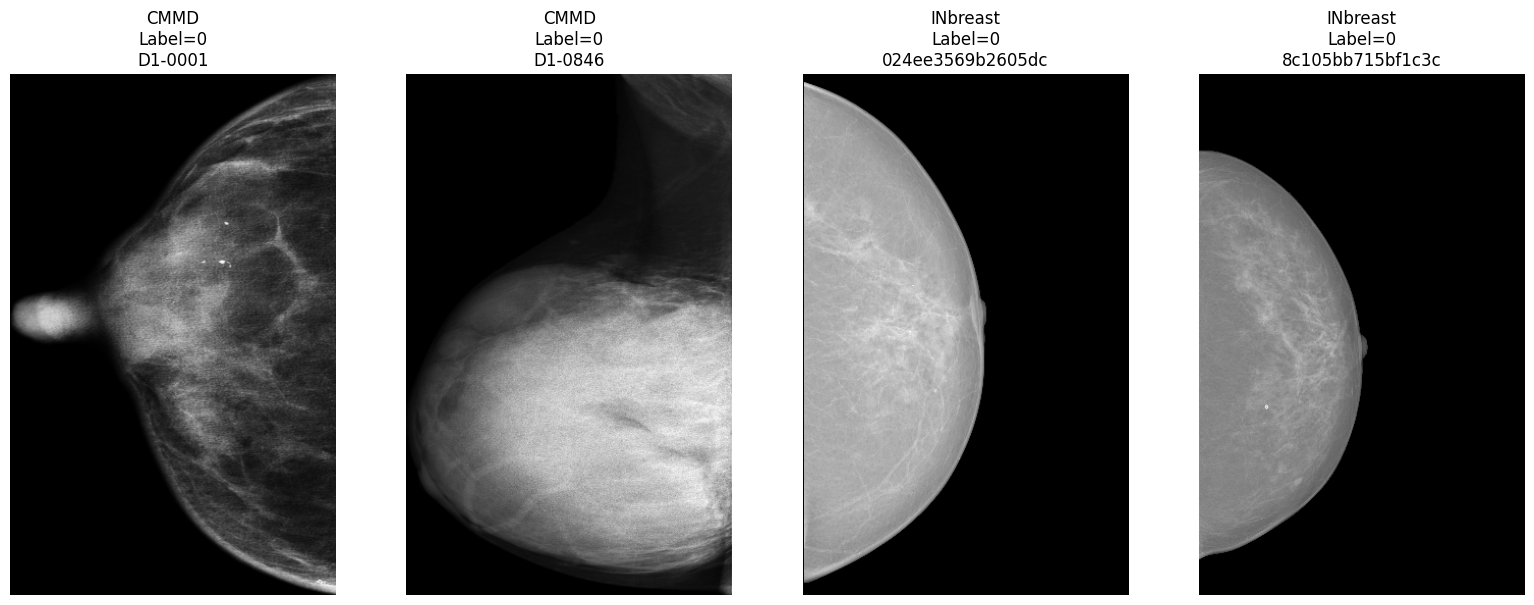

In [103]:
audit_samples = [
    (
        "CMMD",
        cmmd_primary_df,
        CMMD_ZIP_PATH,
        "cmmd",
        0,
    ),

    (
        "CMMD",
        cmmd_primary_df,
        CMMD_ZIP_PATH,
        "cmmd",
        len(
            cmmd_primary_df
        ) // 2,
    ),

    (
        "INbreast",
        inbreast_broad_df,
        INBREAST_ZIP_PATH,
        "inbreast",
        0,
    ),

    (
        "INbreast",
        inbreast_broad_df,
        INBREAST_ZIP_PATH,
        "inbreast",
        len(
            inbreast_broad_df
        ) // 2,
    ),
]


figure, axes = plt.subplots(
    1,
    4,
    figsize=(
        16,
        6,
    ),
)


for axis, (
    display_name,
    dataframe,
    zip_path,
    dataset_name,
    index,
) in zip(
    axes,
    audit_samples,
):

    (
        display_image,
        row,
    ) = load_display_image(
        dataframe=(
            dataframe
        ),

        index=(
            index
        ),

        zip_path=(
            zip_path
        ),

        dataset_name=(
            dataset_name
        ),
    )


    axis.imshow(
        display_image
    )


    axis.set_title(
        (
            f"{display_name}\n"
            f"Label={int(row['label'])}\n"
            f"{row['patient_id']}"
        )
    )


    axis.axis(
        "off"
    )


plt.tight_layout()

plt.show()

### **Deterministic DataLoaders**

In [104]:
EXTERNAL_BATCH_SIZE = 16

EXTERNAL_NUM_WORKERS = 0


cmmd_external_loader = (
    DataLoader(
        cmmd_external_dataset,

        batch_size=(
            EXTERNAL_BATCH_SIZE
        ),

        shuffle=False,

        num_workers=(
            EXTERNAL_NUM_WORKERS
        ),

        pin_memory=(
            torch.cuda.is_available()
        ),

        drop_last=False,
    )
)


inbreast_external_loader = (
    DataLoader(
        inbreast_external_dataset,

        batch_size=(
            EXTERNAL_BATCH_SIZE
        ),

        shuffle=False,

        num_workers=(
            EXTERNAL_NUM_WORKERS
        ),

        pin_memory=(
            torch.cuda.is_available()
        ),

        drop_last=False,
    )
)


print(
    "External batch size:",
    EXTERNAL_BATCH_SIZE,
)


print(
    "CMMD batches:",
    len(
        cmmd_external_loader
    ),
)


print(
    "INbreast batches:",
    len(
        inbreast_external_loader
    ),
)


assert (
    len(
        cmmd_external_loader
    )
    == 128
)


assert (
    len(
        inbreast_external_loader
    )
    == 24
)


print(
    "\nFrozen external DataLoaders ready."
)

External batch size: 16
CMMD batches: 128
INbreast batches: 24

Frozen external DataLoaders ready.


## **LOAD AND AUDIT FROZEN MIXSTYLE CHECKPOINTS**

### **Recover frozen checkpoint paths**

In [105]:
from pathlib import Path


BASELINE_MS_BEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "baseline_mixstyle"
    / "checkpoints"
    / "mobilenetv3_small_baseline_mixstyle_best.pt"
)


MOE_MS_BEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "moe_mixstyle"
    / "checkpoints"
    / "mobilenetv3_small_sparse_top2_moe_mixstyle_best.pt"
)


KD_MS_BEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "exploratory_mixstyle_dg"
    / "moe_kd_mixstyle"
    / "checkpoints"
    / "mobilenetv3_small_sparse_top2_moe_kd_mixstyle_best.pt"
)


DG_CHECKPOINT_PATHS = {
    "Baseline+MixStyle": (
        BASELINE_MS_BEST_PATH
    ),

    "MoE+MixStyle": (
        MOE_MS_BEST_PATH
    ),

    "MoE+KD+MixStyle": (
        KD_MS_BEST_PATH
    ),
}


for (
    model_name,
    checkpoint_path,
) in DG_CHECKPOINT_PATHS.items():

    print(
        f"{model_name:20s}:",
        (
            "FOUND"
            if checkpoint_path.exists()
            else "MISSING"
        ),
    )

    print(
        " ",
        checkpoint_path,
    )

    assert (
        checkpoint_path.exists()
    )


print(
    "\nAll frozen MixStyle "
    "checkpoints found."
)

Baseline+MixStyle   : FOUND
  /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/baseline_mixstyle/checkpoints/mobilenetv3_small_baseline_mixstyle_best.pt
MoE+MixStyle        : FOUND
  /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_mixstyle_best.pt
MoE+KD+MixStyle     : FOUND
  /content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/moe_kd_mixstyle/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_mixstyle_best.pt

All frozen MixStyle checkpoints found.


### **Load checkpoints on CPU**

In [106]:
def load_frozen_checkpoint(
    path,
):
    try:

        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

    except TypeError:

        return torch.load(
            path,
            map_location="cpu",
        )


baseline_ms_checkpoint = (
    load_frozen_checkpoint(
        BASELINE_MS_BEST_PATH
    )
)


moe_ms_checkpoint = (
    load_frozen_checkpoint(
        MOE_MS_BEST_PATH
    )
)


kd_ms_checkpoint = (
    load_frozen_checkpoint(
        KD_MS_BEST_PATH
    )
)


print(
    "Baseline+MS best epoch:",
    baseline_ms_checkpoint[
        "epoch"
    ],
)

print(
    "Baseline+MS best AUC:",
    baseline_ms_checkpoint[
        "best_val_auc"
    ],
)


print(
    "\nMoE+MS best epoch:",
    moe_ms_checkpoint[
        "epoch"
    ],
)

print(
    "MoE+MS best AUC:",
    moe_ms_checkpoint[
        "best_val_auc"
    ],
)


print(
    "\nMoE+KD+MS best epoch:",
    kd_ms_checkpoint[
        "epoch"
    ],
)

print(
    "MoE+KD+MS best AUC:",
    kd_ms_checkpoint[
        "best_val_auc"
    ],
)

Baseline+MS best epoch: 9
Baseline+MS best AUC: 0.7632226835527551

MoE+MS best epoch: 9
MoE+MS best AUC: 0.7732687934236058

MoE+KD+MS best epoch: 11
MoE+KD+MS best AUC: 0.7621586096100482


### **Recover and audit frozen thresholds**

In [107]:
BASELINE_MS_FROZEN_THRESHOLD = float(
    baseline_ms_checkpoint[
        "frozen_internal_threshold"
    ]
)


MOE_MS_FROZEN_THRESHOLD = float(
    moe_ms_checkpoint[
        "frozen_internal_threshold"
    ]
)


KD_MS_FROZEN_THRESHOLD = float(
    kd_ms_checkpoint[
        "frozen_internal_threshold"
    ]
)


DG_FROZEN_THRESHOLDS = {
    "Baseline+MixStyle": (
        BASELINE_MS_FROZEN_THRESHOLD
    ),

    "MoE+MixStyle": (
        MOE_MS_FROZEN_THRESHOLD
    ),

    "MoE+KD+MixStyle": (
        KD_MS_FROZEN_THRESHOLD
    ),
}


for (
    model_name,
    threshold,
) in DG_FROZEN_THRESHOLDS.items():

    print(
        f"{model_name:20s}: "
        f"{threshold:.12f}"
    )


assert np.isclose(
    BASELINE_MS_FROZEN_THRESHOLD,
    0.6552734375,
)


assert np.isclose(
    MOE_MS_FROZEN_THRESHOLD,
    0.3650542199611664,
)


assert np.isclose(
    KD_MS_FROZEN_THRESHOLD,
    0.5193431973457336,
)


print(
    "\nFrozen thresholds verified."
)

Baseline+MixStyle   : 0.655273437500
MoE+MixStyle        : 0.365054219961
MoE+KD+MixStyle     : 0.519343197346

Frozen thresholds verified.


### **Instantiate the three inference models**

In [108]:
baseline_ms_external_model = (
    MobileNetV3SmallMixStyleBaseline(
        pretrained=False
    )
)


moe_ms_external_model = (
    MobileNetV3SmallSparseMoEMixStyle(
        pretrained=False,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,
    )
)


kd_ms_external_model = (
    MobileNetV3SmallSparseMoEKDMixStyle(
        pretrained=False,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,

        teacher_projection_dim=512,
    )
)


print(
    "Frozen inference architectures "
    "instantiated."
)

Frozen inference architectures instantiated.


### **Strict checkpoint loading**

In [109]:
baseline_load_result = (
    baseline_ms_external_model
    .load_state_dict(
        baseline_ms_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )
)


moe_load_result = (
    moe_ms_external_model
    .load_state_dict(
        moe_ms_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )
)


kd_load_result = (
    kd_ms_external_model
    .load_state_dict(
        kd_ms_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )
)


print(
    "Baseline+MS:",
    baseline_load_result,
)


print(
    "MoE+MS:",
    moe_load_result,
)


print(
    "MoE+KD+MS:",
    kd_load_result,
)


print(
    "\nStrict state-dict loading passed."
)

Baseline+MS: <All keys matched successfully>
MoE+MS: <All keys matched successfully>
MoE+KD+MS: <All keys matched successfully>

Strict state-dict loading passed.


### **Parameter-count audit**

In [110]:
def count_parameters(
    model,
):
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
    )


baseline_ms_parameters = (
    count_parameters(
        baseline_ms_external_model
    )
)


moe_ms_parameters = (
    count_parameters(
        moe_ms_external_model
    )
)


kd_ms_training_parameters = (
    count_parameters(
        kd_ms_external_model
    )
)


kd_ms_deployable_parameters = sum(
    parameter.numel()
    for name, parameter
    in kd_ms_external_model
    .named_parameters()
    if not name.startswith(
        "distill_projector"
    )
)


parameter_audit_df = (
    pd.DataFrame([
        {
            "model": (
                "Baseline+MixStyle"
            ),

            "training_parameters": (
                baseline_ms_parameters
            ),

            "deployable_parameters": (
                baseline_ms_parameters
            ),
        },

        {
            "model": (
                "MoE+MixStyle"
            ),

            "training_parameters": (
                moe_ms_parameters
            ),

            "deployable_parameters": (
                moe_ms_parameters
            ),
        },

        {
            "model": (
                "MoE+KD+MixStyle"
            ),

            "training_parameters": (
                kd_ms_training_parameters
            ),

            "deployable_parameters": (
                kd_ms_deployable_parameters
            ),
        },
    ])
)


display(
    parameter_audit_df
)


assert (
    baseline_ms_parameters
    == 927_585
)


assert (
    moe_ms_parameters
    == 1_223_206
)


assert (
    kd_ms_training_parameters
    == 1_519_654
)


assert (
    kd_ms_deployable_parameters
    == 1_223_206
)


print(
    "\nParameter-count audit passed."
)

,model,training_parameters,deployable_parameters
0,Baseline+MixStyle,927585,927585
1,MoE+MixStyle,1223206,1223206
2,MoE+KD+MixStyle,1519654,1223206



Parameter-count audit passed.


### **Move frozen models to device and disable MixStyle**

In [111]:
baseline_ms_external_model = (
    baseline_ms_external_model
    .to(
        DEVICE
    )
    .eval()
)


moe_ms_external_model = (
    moe_ms_external_model
    .to(
        DEVICE
    )
    .eval()
)


kd_ms_external_model = (
    kd_ms_external_model
    .to(
        DEVICE
    )
    .eval()
)


for model in [
    baseline_ms_external_model,
    moe_ms_external_model,
    kd_ms_external_model,
]:

    for parameter in (
        model.parameters()
    ):

        parameter.requires_grad_(
            False
        )


print(
    "Baseline+MS training mode:",
    baseline_ms_external_model.training,
)


print(
    "MoE+MS training mode:",
    moe_ms_external_model.training,
)


print(
    "MoE+KD+MS training mode:",
    kd_ms_external_model.training,
)


assert not (
    baseline_ms_external_model.training
)


assert not (
    moe_ms_external_model.training
)


assert not (
    kd_ms_external_model.training
)


print(
    "\nAll external models frozen "
    "in evaluation mode."
)

Baseline+MS training mode: False
MoE+MS training mode: False
MoE+KD+MS training mode: False

All external models frozen in evaluation mode.


### **Synthetic inference determinism audit**

This is to demonstrate that MixStyle does not alter the output when eval() is called.

In [112]:
synthetic_generator = (
    torch.Generator()
)


synthetic_generator.manual_seed(
    12345
)


synthetic_input = (
    torch.randn(
        (
            4,
            3,
            512,
            320,
        ),

        generator=(
            synthetic_generator
        ),
    )
    .to(
        DEVICE
    )
)


with torch.inference_mode():

    with torch.autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP,
    ):

        # ----------------------------------------------------
        # Baseline+MixStyle
        # ----------------------------------------------------

        baseline_output_1 = (
            baseline_ms_external_model(
                synthetic_input
            )
        )


        baseline_output_2 = (
            baseline_ms_external_model(
                synthetic_input
            )
        )


        # ----------------------------------------------------
        # MoE+MixStyle
        # ----------------------------------------------------

        moe_output_1 = (
            moe_ms_external_model(
                synthetic_input
            )
        )


        moe_output_2 = (
            moe_ms_external_model(
                synthetic_input
            )
        )


        # ----------------------------------------------------
        # KD+MixStyle
        # ----------------------------------------------------

        kd_output_1 = (
            kd_ms_external_model(
                synthetic_input,
                return_features=False,
            )
        )


        kd_output_2 = (
            kd_ms_external_model(
                synthetic_input,
                return_features=False,
            )
        )

In [113]:
baseline_max_difference = float(
    (
        baseline_output_1
        - baseline_output_2
    )
    .abs()
    .max()
    .float()
    .cpu()
)


moe_logit_max_difference = float(
    (
        moe_output_1[
            "logits"
        ]
        -
        moe_output_2[
            "logits"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


moe_router_max_difference = float(
    (
        moe_output_1[
            "router_probabilities"
        ]
        -
        moe_output_2[
            "router_probabilities"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


kd_logit_max_difference = float(
    (
        kd_output_1[
            "logits"
        ]
        -
        kd_output_2[
            "logits"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


kd_router_max_difference = float(
    (
        kd_output_1[
            "router_probabilities"
        ]
        -
        kd_output_2[
            "router_probabilities"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


print(
    "Baseline+MS max difference:",
    baseline_max_difference,
)


print(
    "MoE+MS logit max difference:",
    moe_logit_max_difference,
)


print(
    "MoE+MS router max difference:",
    moe_router_max_difference,
)


print(
    "KD+MS logit max difference:",
    kd_logit_max_difference,
)


print(
    "KD+MS router max difference:",
    kd_router_max_difference,
)


assert (
    baseline_max_difference
    == 0.0
)


assert (
    moe_logit_max_difference
    == 0.0
)


assert (
    moe_router_max_difference
    == 0.0
)


assert (
    kd_logit_max_difference
    == 0.0
)


assert (
    kd_router_max_difference
    == 0.0
)


print(
    "\nMixStyle is functionally inactive "
    "during evaluation."
)

Baseline+MS max difference: 0.0
MoE+MS logit max difference: 0.0
MoE+MS router max difference: 0.0
KD+MS logit max difference: 0.0
KD+MS router max difference: 0.0

MixStyle is functionally inactive during evaluation.


### **Final pre-inference registry**

In [114]:
FROZEN_DG_EXTERNAL_MODELS = {
    "Baseline+MixStyle": {
        "model": (
            baseline_ms_external_model
        ),

        "threshold": (
            BASELINE_MS_FROZEN_THRESHOLD
        ),

        "has_router": False,

        "has_kd_projector": False,
    },


    "MoE+MixStyle": {
        "model": (
            moe_ms_external_model
        ),

        "threshold": (
            MOE_MS_FROZEN_THRESHOLD
        ),

        "has_router": True,

        "has_kd_projector": False,
    },


    "MoE+KD+MixStyle": {
        "model": (
            kd_ms_external_model
        ),

        "threshold": (
            KD_MS_FROZEN_THRESHOLD
        ),

        "has_router": True,

        "has_kd_projector": True,
    },
}


registry_rows = []


for (
    model_name,
    specification,
) in (
    FROZEN_DG_EXTERNAL_MODELS
    .items()
):

    registry_rows.append({
        "model": (
            model_name
        ),

        "threshold": float(
            specification[
                "threshold"
            ]
        ),

        "has_router": (
            specification[
                "has_router"
            ]
        ),

        "has_kd_projector": (
            specification[
                "has_kd_projector"
            ]
        ),

        "training_mode": (
            specification[
                "model"
            ].training
        ),
    })


external_model_registry_df = (
    pd.DataFrame(
        registry_rows
    )
)


display(
    external_model_registry_df
)


assert (
    external_model_registry_df[
        "training_mode"
    ]
    .eq(
        False
    )
    .all()
)


print(
    "\nFrozen external model "
    "registry ready."
)

,model,threshold,has_router,has_kd_projector,training_mode
0,Baseline+MixStyle,0.655273,False,False,False
1,MoE+MixStyle,0.365054,True,False,False
2,MoE+KD+MixStyle,0.519343,True,True,False



Frozen external model registry ready.


### **Build True Deployable KD+MixStyle**

In [115]:
# ------------------------------------------------------------
# Classification architecture only.
# No KD projector at deployment.
# ------------------------------------------------------------

kd_ms_deployable_model = (
    MobileNetV3SmallSparseMoEMixStyle(
        pretrained=False,

        num_experts=3,

        top_k=2,

        expert_hidden_dim=128,

        router_hidden_dim=128,

        expert_dropout=0.2,

        router_dropout=0.1,
    )
)


# ------------------------------------------------------------
# Remove training-only projector weights
# ------------------------------------------------------------

kd_ms_deployable_state_dict = {
    key: value

    for key, value
    in kd_ms_checkpoint[
        "model_state_dict"
    ].items()

    if not key.startswith(
        "distill_projector."
    )
}


kd_deployable_load_result = (
    kd_ms_deployable_model
    .load_state_dict(
        kd_ms_deployable_state_dict,
        strict=True,
    )
)


print(
    "Deployable KD+MS load:",
    kd_deployable_load_result,
)


kd_ms_deployable_parameter_count = sum(
    parameter.numel()
    for parameter
    in kd_ms_deployable_model.parameters()
)


print(
    "Deployable parameters:",
    f"{kd_ms_deployable_parameter_count:,}",
)


assert (
    kd_ms_deployable_parameter_count
    == 1_223_206
)


kd_ms_deployable_model = (
    kd_ms_deployable_model
    .to(
        DEVICE
    )
    .eval()
)


for parameter in (
    kd_ms_deployable_model.parameters()
):

    parameter.requires_grad_(
        False
    )

Deployable KD+MS load: <All keys matched successfully>
Deployable parameters: 1,223,206


In [116]:
# ============================================================
# Classification equivalence audit
# ============================================================

equivalence_generator = (
    torch.Generator()
)

equivalence_generator.manual_seed(
    24680
)


equivalence_input = (
    torch.randn(
        (
            4,
            3,
            512,
            320,
        ),

        generator=(
            equivalence_generator
        ),
    )
    .to(
        DEVICE
    )
)


with torch.inference_mode():

    with torch.autocast(
        device_type=DEVICE.type,
        enabled=USE_AMP,
    ):

        full_kd_output = (
            kd_ms_external_model(
                equivalence_input,
                return_features=False,
            )
        )


        deployable_kd_output = (
            kd_ms_deployable_model(
                equivalence_input
            )
        )


kd_logit_equivalence = float(
    (
        full_kd_output[
            "logits"
        ]
        -
        deployable_kd_output[
            "logits"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


kd_router_equivalence = float(
    (
        full_kd_output[
            "router_probabilities"
        ]
        -
        deployable_kd_output[
            "router_probabilities"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


kd_expert_equivalence = float(
    (
        full_kd_output[
            "expert_logits"
        ]
        -
        deployable_kd_output[
            "expert_logits"
        ]
    )
    .abs()
    .max()
    .float()
    .cpu()
)


print(
    "Logit max difference:",
    kd_logit_equivalence,
)

print(
    "Router max difference:",
    kd_router_equivalence,
)

print(
    "Expert-logit max difference:",
    kd_expert_equivalence,
)


assert (
    kd_logit_equivalence
    == 0.0
)

assert (
    kd_router_equivalence
    == 0.0
)

assert (
    kd_expert_equivalence
    == 0.0
)


print(
    "\nTraining-only KD projector "
    "removed with exact "
    "classification equivalence."
)

Logit max difference: 0.0
Router max difference: 0.0
Expert-logit max difference: 0.0

Training-only KD projector removed with exact classification equivalence.


In [117]:
FROZEN_DG_EXTERNAL_MODELS[
    "MoE+KD+MixStyle"
][
    "model"
] = (
    kd_ms_deployable_model
)


FROZEN_DG_EXTERNAL_MODELS[
    "MoE+KD+MixStyle"
][
    "has_kd_projector"
] = False


print(
    "External KD+MixStyle registry "
    "now uses deployable classifier only."
)

External KD+MixStyle registry now uses deployable classifier only.


## **ONE-SHOT EXTERNAL INFERENCE**

### **External inference utility**

In [118]:
from tqdm.auto import tqdm
import time


def tensor_to_numpy(
    tensor,
):
    return (
        tensor
        .detach()
        .float()
        .cpu()
        .numpy()
    )


def append_moe_records(
    records,
    model_name,
    dataset_name,
    batch,
    output,
    threshold,
):
    logits = (
        output[
            "logits"
        ]
        .view(-1)
    )


    probabilities = (
        torch.sigmoid(
            logits
        )
    )


    router_logits = (
        tensor_to_numpy(
            output[
                "router_logits"
            ]
        )
    )


    router_probabilities = (
        tensor_to_numpy(
            output[
                "router_probabilities"
            ]
        )
    )


    expert_logits = (
        tensor_to_numpy(
            output[
                "expert_logits"
            ]
        )
    )


    sparse_gates = (
        tensor_to_numpy(
            output[
                "sparse_gates"
            ]
        )
    )


    topk_indices = (
        output[
            "topk_indices"
        ]
        .detach()
        .cpu()
        .numpy()
    )


    logits = (
        tensor_to_numpy(
            logits
        )
    )


    probabilities = (
        tensor_to_numpy(
            probabilities
        )
    )


    labels = (
        batch[
            "labels"
        ]
        .detach()
        .cpu()
        .numpy()
    )


    row_indices = (
        batch[
            "row_index"
        ]
        .detach()
        .cpu()
        .numpy()
    )


    batch_size = (
        len(
            labels
        )
    )


    for index in range(
        batch_size
    ):

        records.append({
            "dataset": (
                dataset_name
            ),

            "model": (
                model_name
            ),

            "row_index": int(
                row_indices[
                    index
                ]
            ),

            "image_path": (
                batch[
                    "image_path"
                ][
                    index
                ]
            ),

            "archive_member": (
                batch[
                    "archive_member"
                ][
                    index
                ]
            ),

            "patient_id": (
                batch[
                    "patient_id"
                ][
                    index
                ]
            ),

            "label": int(
                labels[
                    index
                ]
            ),

            "logit": float(
                logits[
                    index
                ]
            ),

            "probability": float(
                probabilities[
                    index
                ]
            ),

            "frozen_threshold": float(
                threshold
            ),

            "router_logit_0": float(
                router_logits[
                    index,
                    0
                ]
            ),

            "router_logit_1": float(
                router_logits[
                    index,
                    1
                ]
            ),

            "router_logit_2": float(
                router_logits[
                    index,
                    2
                ]
            ),

            "router_prob_0": float(
                router_probabilities[
                    index,
                    0
                ]
            ),

            "router_prob_1": float(
                router_probabilities[
                    index,
                    1
                ]
            ),

            "router_prob_2": float(
                router_probabilities[
                    index,
                    2
                ]
            ),

            "expert_logit_0": float(
                expert_logits[
                    index,
                    0
                ]
            ),

            "expert_logit_1": float(
                expert_logits[
                    index,
                    1
                ]
            ),

            "expert_logit_2": float(
                expert_logits[
                    index,
                    2
                ]
            ),

            "sparse_gate_0": float(
                sparse_gates[
                    index,
                    0
                ]
            ),

            "sparse_gate_1": float(
                sparse_gates[
                    index,
                    1
                ]
            ),

            "sparse_gate_2": float(
                sparse_gates[
                    index,
                    2
                ]
            ),

            "top1_expert": int(
                topk_indices[
                    index,
                    0
                ]
            ),

            "top2_expert": int(
                topk_indices[
                    index,
                    1
                ]
            ),
        })

In [119]:
def run_three_model_external_inference(
    loader,
    dataset_name,
):
    records = []


    baseline_model = (
        FROZEN_DG_EXTERNAL_MODELS[
            "Baseline+MixStyle"
        ][
            "model"
        ]
    )


    moe_model = (
        FROZEN_DG_EXTERNAL_MODELS[
            "MoE+MixStyle"
        ][
            "model"
        ]
    )


    kd_model = (
        FROZEN_DG_EXTERNAL_MODELS[
            "MoE+KD+MixStyle"
        ][
            "model"
        ]
    )


    baseline_threshold = float(
        FROZEN_DG_EXTERNAL_MODELS[
            "Baseline+MixStyle"
        ][
            "threshold"
        ]
    )


    moe_threshold = float(
        FROZEN_DG_EXTERNAL_MODELS[
            "MoE+MixStyle"
        ][
            "threshold"
        ]
    )


    kd_threshold = float(
        FROZEN_DG_EXTERNAL_MODELS[
            "MoE+KD+MixStyle"
        ][
            "threshold"
        ]
    )


    start_time = (
        time.perf_counter()
    )


    with torch.inference_mode():

        for batch in tqdm(
            loader,
            desc=(
                f"Inference {dataset_name}"
            ),
        ):

            images = (
                batch[
                    "images"
                ]
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )


            with torch.autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP,
            ):

                # --------------------------------------------
                # Baseline + MixStyle
                # --------------------------------------------

                baseline_logits = (
                    baseline_model(
                        images
                    )
                    .view(-1)
                )


                # --------------------------------------------
                # MoE + MixStyle
                # --------------------------------------------

                moe_output = (
                    moe_model(
                        images
                    )
                )


                # --------------------------------------------
                # MoE + KD + MixStyle
                # Deployable classifier only
                # --------------------------------------------

                kd_output = (
                    kd_model(
                        images
                    )
                )


            # ================================================
            # Baseline records
            # ================================================

            baseline_probabilities = (
                torch.sigmoid(
                    baseline_logits
                )
            )


            baseline_logits_np = (
                tensor_to_numpy(
                    baseline_logits
                )
            )


            baseline_probabilities_np = (
                tensor_to_numpy(
                    baseline_probabilities
                )
            )


            labels_np = (
                batch[
                    "labels"
                ]
                .detach()
                .cpu()
                .numpy()
            )


            row_indices_np = (
                batch[
                    "row_index"
                ]
                .detach()
                .cpu()
                .numpy()
            )


            for index in range(
                len(
                    labels_np
                )
            ):

                records.append({
                    "dataset": (
                        dataset_name
                    ),

                    "model": (
                        "Baseline+MixStyle"
                    ),

                    "row_index": int(
                        row_indices_np[
                            index
                        ]
                    ),

                    "image_path": (
                        batch[
                            "image_path"
                        ][
                            index
                        ]
                    ),

                    "archive_member": (
                        batch[
                            "archive_member"
                        ][
                            index
                        ]
                    ),

                    "patient_id": (
                        batch[
                            "patient_id"
                        ][
                            index
                        ]
                    ),

                    "label": int(
                        labels_np[
                            index
                        ]
                    ),

                    "logit": float(
                        baseline_logits_np[
                            index
                        ]
                    ),

                    "probability": float(
                        baseline_probabilities_np[
                            index
                        ]
                    ),

                    "frozen_threshold": (
                        baseline_threshold
                    ),

                    # No router for baseline.
                    "router_logit_0": np.nan,
                    "router_logit_1": np.nan,
                    "router_logit_2": np.nan,

                    "router_prob_0": np.nan,
                    "router_prob_1": np.nan,
                    "router_prob_2": np.nan,

                    "expert_logit_0": np.nan,
                    "expert_logit_1": np.nan,
                    "expert_logit_2": np.nan,

                    "sparse_gate_0": np.nan,
                    "sparse_gate_1": np.nan,
                    "sparse_gate_2": np.nan,

                    "top1_expert": np.nan,
                    "top2_expert": np.nan,
                })


            # ================================================
            # MoE records
            # ================================================

            append_moe_records(
                records=(
                    records
                ),

                model_name=(
                    "MoE+MixStyle"
                ),

                dataset_name=(
                    dataset_name
                ),

                batch=(
                    batch
                ),

                output=(
                    moe_output
                ),

                threshold=(
                    moe_threshold
                ),
            )


            # ================================================
            # KD records
            # ================================================

            append_moe_records(
                records=(
                    records
                ),

                model_name=(
                    "MoE+KD+MixStyle"
                ),

                dataset_name=(
                    dataset_name
                ),

                batch=(
                    batch
                ),

                output=(
                    kd_output
                ),

                threshold=(
                    kd_threshold
                ),
            )


    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )


    prediction_dataframe = (
        pd.DataFrame(
            records
        )
    )


    return (
        prediction_dataframe,
        elapsed_seconds,
    )


print(
    "One-shot external inference "
    "function ready."
)

One-shot external inference function ready.


### **Run CMMD one-shot inference**

In [120]:
(
    cmmd_dg_predictions,
    cmmd_dg_inference_seconds,
) = (
    run_three_model_external_inference(
        loader=(
            cmmd_external_loader
        ),

        dataset_name=(
            "CMMD Expanded Primary"
        ),
    )
)


print(
    "CMMD prediction rows:",
    len(
        cmmd_dg_predictions
    ),
)


print(
    "Expected:",
    2046 * 3,
)


print(
    "Elapsed:",
    f"{cmmd_dg_inference_seconds:.2f} seconds",
)


assert (
    len(
        cmmd_dg_predictions
    )
    ==
    2046 * 3
)


print(
    "\nCMMD one-shot inference completed."
)

Inference CMMD Expanded Primary:   0%|          | 0/128 [00:00<?, ?it/s]

CMMD prediction rows: 6138
Expected: 6138
Elapsed: 40.28 seconds

CMMD one-shot inference completed.


### **Immediately save raw CMMD predictions**

In [121]:
CMMD_DG_RAW_PREDICTIONS_PATH = (
    DG_EXTERNAL_PREDICTION_ROOT
    / "cmmd_primary_mixstyle_models_raw_predictions.csv"
)


cmmd_dg_predictions.to_csv(
    CMMD_DG_RAW_PREDICTIONS_PATH,
    index=False,
)


assert (
    CMMD_DG_RAW_PREDICTIONS_PATH
    .exists()
)


print(
    "Raw CMMD predictions saved:"
)

print(
    CMMD_DG_RAW_PREDICTIONS_PATH
)

Raw CMMD predictions saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/predictions/cmmd_primary_mixstyle_models_raw_predictions.csv


### **Run INbreast one-shot inference**

In [122]:
(
    inbreast_dg_predictions,
    inbreast_dg_inference_seconds,
) = (
    run_three_model_external_inference(
        loader=(
            inbreast_external_loader
        ),

        dataset_name=(
            "INbreast Broad"
        ),
    )
)


print(
    "INbreast prediction rows:",
    len(
        inbreast_dg_predictions
    ),
)


print(
    "Expected:",
    383 * 3,
)


print(
    "Elapsed:",
    f"{inbreast_dg_inference_seconds:.2f} seconds",
)


assert (
    len(
        inbreast_dg_predictions
    )
    ==
    383 * 3
)


print(
    "\nINbreast one-shot inference completed."
)

Inference INbreast Broad:   0%|          | 0/24 [00:00<?, ?it/s]

INbreast prediction rows: 1149
Expected: 1149
Elapsed: 101.42 seconds

INbreast one-shot inference completed.


### **Immediately save raw INbreast predictions**

In [123]:
INBREAST_DG_RAW_PREDICTIONS_PATH = (
    DG_EXTERNAL_PREDICTION_ROOT
    / "inbreast_broad_mixstyle_models_raw_predictions.csv"
)


inbreast_dg_predictions.to_csv(
    INBREAST_DG_RAW_PREDICTIONS_PATH,
    index=False,
)


assert (
    INBREAST_DG_RAW_PREDICTIONS_PATH
    .exists()
)


print(
    "Raw INbreast predictions saved:"
)

print(
    INBREAST_DG_RAW_PREDICTIONS_PATH
)

Raw INbreast predictions saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/predictions/inbreast_broad_mixstyle_models_raw_predictions.csv


### **Integrity and alignment audit**

In [124]:
EXPECTED_MODELS = [
    "Baseline+MixStyle",
    "MoE+MixStyle",
    "MoE+KD+MixStyle",
]


def audit_prediction_dataframe(
    prediction_dataframe,
    source_dataframe,
    expected_images,
    dataset_name,
):
    print(
        "\n"
        + "=" * 72
    )

    print(
        dataset_name
    )

    print(
        "=" * 72
    )


    # --------------------------------------------------------
    # Counts
    # --------------------------------------------------------

    model_counts = (
        prediction_dataframe[
            "model"
        ]
        .value_counts()
        .reindex(
            EXPECTED_MODELS
        )
    )


    print(
        "Rows per model:"
    )

    print(
        model_counts
    )


    assert (
        model_counts
        .eq(
            expected_images
        )
        .all()
    )


    # --------------------------------------------------------
    # Finite classification outputs
    # --------------------------------------------------------

    assert np.isfinite(
        prediction_dataframe[
            "logit"
        ]
    ).all()


    assert np.isfinite(
        prediction_dataframe[
            "probability"
        ]
    ).all()


    assert (
        prediction_dataframe[
            "probability"
        ]
        .between(
            0.0,
            1.0,
        )
        .all()
    )


    # --------------------------------------------------------
    # Image alignment
    # --------------------------------------------------------

    expected_paths = (
        source_dataframe[
            "image_path"
        ]
        .astype(str)
        .tolist()
    )


    for model_name in (
        EXPECTED_MODELS
    ):

        model_frame = (
            prediction_dataframe[
                prediction_dataframe[
                    "model"
                ]
                ==
                model_name
            ]
            .sort_values(
                "row_index"
            )
            .reset_index(
                drop=True
            )
        )


        observed_paths = (
            model_frame[
                "image_path"
            ]
            .astype(str)
            .tolist()
        )


        assert (
            observed_paths
            ==
            expected_paths
        )


        expected_labels = (
            source_dataframe[
                "label"
            ]
            .astype(int)
            .to_numpy()
        )


        observed_labels = (
            model_frame[
                "label"
            ]
            .astype(int)
            .to_numpy()
        )


        assert np.array_equal(
            observed_labels,
            expected_labels,
        )


    # --------------------------------------------------------
    # Router outputs only required for MoE models
    # --------------------------------------------------------

    moe_rows = (
        prediction_dataframe[
            prediction_dataframe[
                "model"
            ]
            .isin(
                [
                    "MoE+MixStyle",
                    "MoE+KD+MixStyle",
                ]
            )
        ]
    )


    router_columns = [
        "router_prob_0",
        "router_prob_1",
        "router_prob_2",
    ]


    assert np.isfinite(
        moe_rows[
            router_columns
        ]
        .to_numpy()
    ).all()


    router_sum = (
        moe_rows[
            router_columns
        ]
        .sum(
            axis=1
        )
        .to_numpy()
    )


    assert np.allclose(
        router_sum,
        1.0,
        atol=1e-5,
    )


    print(
        "Alignment passed."
    )

    print(
        "Classification outputs finite."
    )

    print(
        "Router probabilities valid."
    )


audit_prediction_dataframe(
    prediction_dataframe=(
        cmmd_dg_predictions
    ),

    source_dataframe=(
        cmmd_primary_df
    ),

    expected_images=2046,

    dataset_name=(
        "CMMD Expanded Primary"
    ),
)


audit_prediction_dataframe(
    prediction_dataframe=(
        inbreast_dg_predictions
    ),

    source_dataframe=(
        inbreast_broad_df
    ),

    expected_images=383,

    dataset_name=(
        "INbreast Broad"
    ),
)


print(
    "\nAll raw external predictions "
    "passed integrity audit."
)


CMMD Expanded Primary
Rows per model:
model
Baseline+MixStyle    2046
MoE+MixStyle         2046
MoE+KD+MixStyle      2046
Name: count, dtype: int64
Alignment passed.
Classification outputs finite.
Router probabilities valid.

INbreast Broad
Rows per model:
model
Baseline+MixStyle    383
MoE+MixStyle         383
MoE+KD+MixStyle      383
Name: count, dtype: int64
Alignment passed.
Classification outputs finite.
Router probabilities valid.

All raw external predictions passed integrity audit.


### **Produce frozen strict subsets from raw predictions**

In [125]:
cmmd_strict_image_paths = set(
    cmmd_strict_df[
        "image_path"
    ]
    .astype(str)
)


inbreast_strict_image_paths = set(
    inbreast_strict_df[
        "image_path"
    ]
    .astype(str)
)


cmmd_strict_dg_predictions = (
    cmmd_dg_predictions[
        cmmd_dg_predictions[
            "image_path"
        ]
        .astype(str)
        .isin(
            cmmd_strict_image_paths
        )
    ]
    .copy()
)


inbreast_strict_dg_predictions = (
    inbreast_dg_predictions[
        inbreast_dg_predictions[
            "image_path"
        ]
        .astype(str)
        .isin(
            inbreast_strict_image_paths
        )
    ]
    .copy()
)


print(
    "CMMD Strict rows:",
    len(
        cmmd_strict_dg_predictions
    ),
)

print(
    "Expected:",
    1886 * 3,
)


print(
    "\nINbreast Strict rows:",
    len(
        inbreast_strict_dg_predictions
    ),
)

print(
    "Expected:",
    341 * 3,
)


assert (
    len(
        cmmd_strict_dg_predictions
    )
    ==
    1886 * 3
)


assert (
    len(
        inbreast_strict_dg_predictions
    )
    ==
    341 * 3
)

CMMD Strict rows: 5658
Expected: 5658

INbreast Strict rows: 1023
Expected: 1023


In [126]:
CMMD_DG_STRICT_PREDICTIONS_PATH = (
    DG_EXTERNAL_PREDICTION_ROOT
    / "cmmd_strict_mixstyle_models_predictions.csv"
)


INBREAST_DG_STRICT_PREDICTIONS_PATH = (
    DG_EXTERNAL_PREDICTION_ROOT
    / "inbreast_strict_mixstyle_models_predictions.csv"
)


cmmd_strict_dg_predictions.to_csv(
    CMMD_DG_STRICT_PREDICTIONS_PATH,
    index=False,
)


inbreast_strict_dg_predictions.to_csv(
    INBREAST_DG_STRICT_PREDICTIONS_PATH,
    index=False,
)


print(
    "CMMD Strict predictions:"
)

print(
    CMMD_DG_STRICT_PREDICTIONS_PATH
)


print(
    "\nINbreast Strict predictions:"
)

print(
    INBREAST_DG_STRICT_PREDICTIONS_PATH
)

CMMD Strict predictions:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/predictions/cmmd_strict_mixstyle_models_predictions.csv

INbreast Strict predictions:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/predictions/inbreast_strict_mixstyle_models_predictions.csv


### **EXTERNAL POINT ESTIMATES**

### **External metric utility**

In [127]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


def compute_frozen_external_metrics(
    prediction_dataframe,
    cohort_name,
    model_name,
):
    model_frame = (
        prediction_dataframe[
            prediction_dataframe[
                "model"
            ]
            ==
            model_name
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    assert (
        len(
            model_frame
        )
        > 0
    )


    labels = (
        model_frame[
            "label"
        ]
        .astype(
            np.int64
        )
        .to_numpy()
    )


    probabilities = (
        model_frame[
            "probability"
        ]
        .astype(
            np.float64
        )
        .to_numpy()
    )


    # --------------------------------------------------------
    # Threshold MUST already be frozen.
    # --------------------------------------------------------

    threshold_values = (
        model_frame[
            "frozen_threshold"
        ]
        .astype(
            np.float64
        )
        .unique()
    )


    assert (
        len(
            threshold_values
        )
        == 1
    )


    threshold = float(
        threshold_values[
            0
        ]
    )


    predictions = (
        probabilities
        >= threshold
    ).astype(
        np.int64
    )


    (
        tn,
        fp,
        fn,
        tp,
    ) = (
        confusion_matrix(
            labels,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    sensitivity = (
        tp
        /
        (
            tp
            + fn
        )
        if (
            tp
            + fn
        ) > 0
        else np.nan
    )


    specificity = (
        tn
        /
        (
            tn
            + fp
        )
        if (
            tn
            + fp
        ) > 0
        else np.nan
    )


    patient_count = int(
        model_frame[
            "patient_id"
        ]
        .astype(str)
        .nunique()
    )


    prevalence = float(
        labels.mean()
    )


    predicted_positive_fraction = float(
        predictions.mean()
    )


    return {
        "cohort": (
            cohort_name
        ),

        "model": (
            model_name
        ),

        "n_images": int(
            len(
                model_frame
            )
        ),

        "n_patients": (
            patient_count
        ),

        "prevalence": (
            prevalence
        ),

        "roc_auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),

        "average_precision": float(
            average_precision_score(
                labels,
                probabilities,
            )
        ),

        "frozen_threshold": (
            threshold
        ),

        "sensitivity": float(
            sensitivity
        ),

        "specificity": float(
            specificity
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),

        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),

        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "predicted_positive_fraction": (
            predicted_positive_fraction
        ),

        "tn": int(
            tn
        ),

        "fp": int(
            fp
        ),

        "fn": int(
            fn
        ),

        "tp": int(
            tp
        ),
    }


print(
    "Frozen external metric "
    "utility ready."
)

Frozen external metric utility ready.


### **Primary external point estimates**

In [128]:
# ============================================================
# Cell 17.2 — PRIMARY external point estimates
# ============================================================

DG_MODEL_ORDER = [
    "Baseline+MixStyle",
    "MoE+MixStyle",
    "MoE+KD+MixStyle",
]


primary_metric_rows = []


# ------------------------------------------------------------
# CMMD Expanded Primary
# ------------------------------------------------------------

for model_name in (
    DG_MODEL_ORDER
):

    primary_metric_rows.append(
        compute_frozen_external_metrics(
            prediction_dataframe=(
                cmmd_dg_predictions
            ),

            cohort_name=(
                "CMMD Expanded Primary"
            ),

            model_name=(
                model_name
            ),
        )
    )


# ------------------------------------------------------------
# INbreast Strict
# ------------------------------------------------------------

for model_name in (
    DG_MODEL_ORDER
):

    primary_metric_rows.append(
        compute_frozen_external_metrics(
            prediction_dataframe=(
                inbreast_strict_dg_predictions
            ),

            cohort_name=(
                "INbreast Strict"
            ),

            model_name=(
                model_name
            ),
        )
    )


dg_primary_metrics_df = (
    pd.DataFrame(
        primary_metric_rows
    )
)


display_columns = [
    "cohort",
    "model",
    "n_images",
    "n_patients",
    "prevalence",
    "roc_auc",
    "average_precision",
    "frozen_threshold",
    "sensitivity",
    "specificity",
    "balanced_accuracy",
    "precision",
    "f1",
    "predicted_positive_fraction",
    "tn",
    "fp",
    "fn",
    "tp",
]


display(
    dg_primary_metrics_df[
        display_columns
    ]
)

,cohort,model,n_images,n_patients,prevalence,roc_auc,average_precision,frozen_threshold,sensitivity,specificity,balanced_accuracy,precision,f1,predicted_positive_fraction,tn,fp,fn,tp
0,CMMD Expanded Primary,Baseline+MixStyle,2046,1023,0.538612,0.497060,0.548956,0.655273,0.995463,0.008475,0.501969,0.539597,0.699841,0.993646,8,936,5,1097
1,CMMD Expanded Primary,MoE+MixStyle,2046,1023,0.538612,0.549414,0.577229,0.365054,0.998185,0.002119,0.500152,0.538688,0.699746,0.998045,2,942,2,1100
2,CMMD Expanded Primary,MoE+KD+MixStyle,2046,1023,0.538612,0.548066,0.598416,0.519343,0.990018,0.014831,0.502424,0.539832,0.698687,0.987781,14,930,11,1091
3,INbreast Strict,Baseline+MixStyle,341,100,0.164223,0.552068,0.203342,0.655273,0.178571,0.880702,0.529637,0.227273,0.200000,0.129032,251,34,46,10
4,INbreast Strict,MoE+MixStyle,341,100,0.164223,0.530263,0.171002,0.365054,0.839286,0.231579,0.535432,0.176692,0.291925,0.780059,66,219,9,47
5,INbreast Strict,MoE+KD+MixStyle,341,100,0.164223,0.519674,0.172640,0.519343,0.535714,0.508772,0.522243,0.176471,0.265487,0.498534,145,140,26,30


### **Sensitivity-cohort point estimates**

In [129]:
sensitivity_metric_rows = []


# ------------------------------------------------------------
# CMMD Strict Two-Image
# ------------------------------------------------------------

for model_name in (
    DG_MODEL_ORDER
):

    sensitivity_metric_rows.append(
        compute_frozen_external_metrics(
            prediction_dataframe=(
                cmmd_strict_dg_predictions
            ),

            cohort_name=(
                "CMMD Strict Two-Image"
            ),

            model_name=(
                model_name
            ),
        )
    )


# ------------------------------------------------------------
# INbreast Broad
# ------------------------------------------------------------

for model_name in (
    DG_MODEL_ORDER
):

    sensitivity_metric_rows.append(
        compute_frozen_external_metrics(
            prediction_dataframe=(
                inbreast_dg_predictions
            ),

            cohort_name=(
                "INbreast Broad"
            ),

            model_name=(
                model_name
            ),
        )
    )


dg_sensitivity_metrics_df = (
    pd.DataFrame(
        sensitivity_metric_rows
    )
)


display(
    dg_sensitivity_metrics_df[
        display_columns
    ]
)

,cohort,model,n_images,n_patients,prevalence,roc_auc,average_precision,frozen_threshold,sensitivity,specificity,balanced_accuracy,precision,f1,predicted_positive_fraction,tn,fp,fn,tp
0,CMMD Strict Two-Image,Baseline+MixStyle,1886,943,0.572641,0.495759,0.582866,0.655273,0.995370,0.006203,0.500787,0.573028,0.727334,0.994698,5,801,5,1075
1,CMMD Strict Two-Image,MoE+MixStyle,1886,943,0.572641,0.547953,0.608943,0.365054,0.998148,0.002481,0.500315,0.572795,0.727887,0.997879,2,804,2,1078
2,CMMD Strict Two-Image,MoE+KD+MixStyle,1886,943,0.572641,0.545507,0.627985,0.519343,0.989815,0.016129,0.502972,0.574114,0.726717,0.987275,13,793,11,1069
3,INbreast Broad,Baseline+MixStyle,383,103,0.255875,0.548013,0.323310,0.655273,0.234694,0.880702,0.557698,0.403509,0.296774,0.148825,251,34,75,23
4,INbreast Broad,MoE+MixStyle,383,103,0.255875,0.488901,0.274498,0.365054,0.755102,0.231579,0.493340,0.252560,0.378517,0.765013,66,219,24,74
5,INbreast Broad,MoE+KD+MixStyle,383,103,0.255875,0.499893,0.278039,0.519343,0.500000,0.508772,0.504386,0.259259,0.341463,0.493473,145,140,49,49


### **Save point estimates immediately**

In [130]:
DG_PRIMARY_METRICS_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "mixstyle_primary_external_point_estimates.csv"
)


DG_SENSITIVITY_METRICS_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "mixstyle_sensitivity_external_point_estimates.csv"
)


dg_primary_metrics_df.to_csv(
    DG_PRIMARY_METRICS_PATH,
    index=False,
)


dg_sensitivity_metrics_df.to_csv(
    DG_SENSITIVITY_METRICS_PATH,
    index=False,
)


print(
    "Primary metrics:"
)

print(
    DG_PRIMARY_METRICS_PATH
)


print(
    "\nSensitivity metrics:"
)

print(
    DG_SENSITIVITY_METRICS_PATH
)


assert (
    DG_PRIMARY_METRICS_PATH.exists()
)


assert (
    DG_SENSITIVITY_METRICS_PATH.exists()
)

Primary metrics:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/mixstyle_primary_external_point_estimates.csv

Sensitivity metrics:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/mixstyle_sensitivity_external_point_estimates.csv


### **External score-distribution summary**

In [131]:
def summarize_external_scores(
    prediction_dataframe,
    cohort_name,
):
    rows = []


    for model_name in (
        DG_MODEL_ORDER
    ):

        model_frame = (
            prediction_dataframe[
                prediction_dataframe[
                    "model"
                ]
                ==
                model_name
            ]
        )


        probabilities = (
            model_frame[
                "probability"
            ]
            .astype(
                np.float64
            )
            .to_numpy()
        )


        rows.append({
            "cohort": (
                cohort_name
            ),

            "model": (
                model_name
            ),

            "minimum": float(
                np.min(
                    probabilities
                )
            ),

            "q25": float(
                np.quantile(
                    probabilities,
                    0.25,
                )
            ),

            "median": float(
                np.median(
                    probabilities
                )
            ),

            "mean": float(
                np.mean(
                    probabilities
                )
            ),

            "q75": float(
                np.quantile(
                    probabilities,
                    0.75,
                )
            ),

            "maximum": float(
                np.max(
                    probabilities
                )
            ),
        })


    return (
        rows
    )


score_distribution_rows = []


score_distribution_rows.extend(
    summarize_external_scores(
        cmmd_dg_predictions,
        "CMMD Expanded Primary",
    )
)


score_distribution_rows.extend(
    summarize_external_scores(
        inbreast_strict_dg_predictions,
        "INbreast Strict",
    )
)


dg_external_score_summary_df = (
    pd.DataFrame(
        score_distribution_rows
    )
)


display(
    dg_external_score_summary_df
)

,cohort,model,minimum,q25,median,mean,q75,maximum
0,CMMD Expanded Primary,Baseline+MixStyle,0.351074,0.928711,0.957031,0.940520,0.972656,0.995605
1,CMMD Expanded Primary,MoE+MixStyle,0.188335,0.853552,0.921635,0.885697,0.956236,0.996746
2,CMMD Expanded Primary,MoE+KD+MixStyle,0.161729,0.893344,0.939045,0.913273,0.966632,0.998838
3,INbreast Strict,Baseline+MixStyle,0.033386,0.310791,0.436035,0.441346,0.593262,0.880371
4,INbreast Strict,MoE+MixStyle,0.026934,0.388018,0.543033,0.529239,0.680355,0.921486
5,INbreast Strict,MoE+KD+MixStyle,0.054557,0.329013,0.519214,0.528153,0.754622,0.931031


### **Generalization-gap point estimates**

In [132]:
DG_INTERNAL_AUC = {
    "Baseline+MixStyle": (
        0.7632226835527551
    ),

    "MoE+MixStyle": (
        0.7732687934236058
    ),

    "MoE+KD+MixStyle": (
        0.7621586096100482
    ),
}


generalization_gap_rows = []


for _, row in (
    dg_primary_metrics_df
    .iterrows()
):

    model_name = (
        row[
            "model"
        ]
    )


    internal_auc = float(
        DG_INTERNAL_AUC[
            model_name
        ]
    )


    external_auc = float(
        row[
            "roc_auc"
        ]
    )


    generalization_gap_rows.append({
        "cohort": (
            row[
                "cohort"
            ]
        ),

        "model": (
            model_name
        ),

        "internal_auc": (
            internal_auc
        ),

        "external_auc": (
            external_auc
        ),

        "auc_generalization_gap": (
            internal_auc
            - external_auc
        ),
    })


dg_generalization_gap_df = (
    pd.DataFrame(
        generalization_gap_rows
    )
)


display(
    dg_generalization_gap_df
)

,cohort,model,internal_auc,external_auc,auc_generalization_gap
0,CMMD Expanded Primary,Baseline+MixStyle,0.763223,0.497060,0.266162
1,CMMD Expanded Primary,MoE+MixStyle,0.773269,0.549414,0.223855
2,CMMD Expanded Primary,MoE+KD+MixStyle,0.762159,0.548066,0.214093
3,INbreast Strict,Baseline+MixStyle,0.763223,0.552068,0.211155
4,INbreast Strict,MoE+MixStyle,0.773269,0.530263,0.243006
5,INbreast Strict,MoE+KD+MixStyle,0.762159,0.519674,0.242484


### **Compare gap against original models**

In [133]:
ORIGINAL_GENERALIZATION_GAPS = {
    (
        "CMMD Expanded Primary",
        "Baseline",
    ): (
        0.7716466022658517
        - 0.5531
    ),

    (
        "CMMD Expanded Primary",
        "MoE",
    ): (
        0.7523524379811806
        - 0.5359
    ),

    (
        "CMMD Expanded Primary",
        "MoE+KD",
    ): (
        0.7488994137161217
        - 0.5199
    ),

    (
        "INbreast Strict",
        "Baseline",
    ): (
        0.7716466022658517
        - 0.5628
    ),

    (
        "INbreast Strict",
        "MoE",
    ): (
        0.7523524379811806
        - 0.5206
    ),

    (
        "INbreast Strict",
        "MoE+KD",
    ): (
        0.7488994137161217
        - 0.5521
    ),
}


MIXSTYLE_TO_ORIGINAL = {
    "Baseline+MixStyle": (
        "Baseline"
    ),

    "MoE+MixStyle": (
        "MoE"
    ),

    "MoE+KD+MixStyle": (
        "MoE+KD"
    ),
}


mixstyle_gap_comparison_rows = []


for _, row in (
    dg_generalization_gap_df
    .iterrows()
):

    cohort = (
        row[
            "cohort"
        ]
    )


    mixstyle_model = (
        row[
            "model"
        ]
    )


    original_model = (
        MIXSTYLE_TO_ORIGINAL[
            mixstyle_model
        ]
    )


    original_gap = float(
        ORIGINAL_GENERALIZATION_GAPS[
            (
                cohort,
                original_model,
            )
        ]
    )


    mixstyle_gap = float(
        row[
            "auc_generalization_gap"
        ]
    )


    mixstyle_gap_comparison_rows.append({
        "cohort": (
            cohort
        ),

        "original_model": (
            original_model
        ),

        "mixstyle_model": (
            mixstyle_model
        ),

        "original_gap": (
            original_gap
        ),

        "mixstyle_gap": (
            mixstyle_gap
        ),

        # Positive means the gap became smaller.
        "gap_reduction": (
            original_gap
            - mixstyle_gap
        ),
    })


mixstyle_gap_comparison_df = (
    pd.DataFrame(
        mixstyle_gap_comparison_rows
    )
)


display(
    mixstyle_gap_comparison_df
)

,cohort,original_model,mixstyle_model,original_gap,mixstyle_gap,gap_reduction
0,CMMD Expanded Primary,Baseline,Baseline+MixStyle,0.218547,0.266162,-0.047616
1,CMMD Expanded Primary,MoE,MoE+MixStyle,0.216452,0.223855,-0.007402
2,CMMD Expanded Primary,MoE+KD,MoE+KD+MixStyle,0.228999,0.214093,0.014906
3,INbreast Strict,Baseline,Baseline+MixStyle,0.208847,0.211155,-0.002308
4,INbreast Strict,MoE,MoE+MixStyle,0.231752,0.243006,-0.011253
5,INbreast Strict,MoE+KD,MoE+KD+MixStyle,0.196799,0.242484,-0.045685


## **PATIENT-CLUSTER BOOTSTRAP**

### **Bootstrap configuration**

In [134]:
BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42

BOOTSTRAP_METRICS = [
    "roc_auc",
    "average_precision",
    "sensitivity",
    "specificity",
    "balanced_accuracy",
]


print(
    "Bootstrap replicates:",
    BOOTSTRAP_REPLICATES,
)

print(
    "Bootstrap unit: patient_id"
)

print(
    "Random seed:",
    BOOTSTRAP_SEED,
)

print(
    "Primary cohorts only."
)

Bootstrap replicates: 2000
Bootstrap unit: patient_id
Random seed: 42
Primary cohorts only.


### **Prepare aligned model arrays**

In [135]:
def prepare_aligned_bootstrap_data(
    prediction_dataframe,
    model_order,
):
    model_frames = {}


    for model_name in (
        model_order
    ):

        frame = (
            prediction_dataframe[
                prediction_dataframe[
                    "model"
                ]
                ==
                model_name
            ]
            .sort_values(
                "row_index"
            )
            .reset_index(
                drop=True
            )
            .copy()
        )


        assert (
            len(
                frame
            )
            > 0
        )


        model_frames[
            model_name
        ] = frame


    reference_model = (
        model_order[
            0
        ]
    )


    reference_frame = (
        model_frames[
            reference_model
        ]
    )


    reference_paths = (
        reference_frame[
            "image_path"
        ]
        .astype(str)
        .to_numpy()
    )


    reference_patients = (
        reference_frame[
            "patient_id"
        ]
        .astype(str)
        .to_numpy()
    )


    reference_labels = (
        reference_frame[
            "label"
        ]
        .astype(
            np.int64
        )
        .to_numpy()
    )


    # --------------------------------------------------------
    # Verify alignment across all models
    # --------------------------------------------------------

    for model_name in (
        model_order[
            1:
        ]
    ):

        frame = (
            model_frames[
                model_name
            ]
        )


        assert np.array_equal(
            frame[
                "image_path"
            ]
            .astype(str)
            .to_numpy(),
            reference_paths,
        )


        assert np.array_equal(
            frame[
                "patient_id"
            ]
            .astype(str)
            .to_numpy(),
            reference_patients,
        )


        assert np.array_equal(
            frame[
                "label"
            ]
            .astype(
                np.int64
            )
            .to_numpy(),
            reference_labels,
        )


    # --------------------------------------------------------
    # Patient clusters
    # --------------------------------------------------------

    unique_patients = (
        pd.unique(
            reference_patients
        )
    )


    patient_cluster_indices = []


    for patient_id in (
        unique_patients
    ):

        indices = np.flatnonzero(
            reference_patients
            ==
            patient_id
        )


        patient_cluster_indices.append(
            indices
        )


    # --------------------------------------------------------
    # Per-model probabilities + frozen threshold
    # --------------------------------------------------------

    model_data = {}


    for model_name in (
        model_order
    ):

        frame = (
            model_frames[
                model_name
            ]
        )


        threshold_values = (
            frame[
                "frozen_threshold"
            ]
            .astype(
                np.float64
            )
            .unique()
        )


        assert (
            len(
                threshold_values
            )
            == 1
        )


        model_data[
            model_name
        ] = {
            "probabilities": (
                frame[
                    "probability"
                ]
                .astype(
                    np.float64
                )
                .to_numpy()
            ),

            "threshold": float(
                threshold_values[
                    0
                ]
            ),
        }


    return {
        "labels": (
            reference_labels
        ),

        "patients": (
            reference_patients
        ),

        "unique_patients": (
            unique_patients
        ),

        "patient_cluster_indices": (
            patient_cluster_indices
        ),

        "models": (
            model_data
        ),
    }

### **Bootstrap metric computation**

In [136]:
def compute_bootstrap_metrics(
    labels,
    probabilities,
    threshold,
):
    predictions = (
        probabilities
        >= threshold
    ).astype(
        np.int64
    )


    (
        tn,
        fp,
        fn,
        tp,
    ) = (
        confusion_matrix(
            labels,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    # AUC requires both classes.
    if (
        np.unique(
            labels
        ).size
        < 2
    ):

        return None


    sensitivity = (
        tp
        /
        (
            tp
            + fn
        )
        if (
            tp
            + fn
        ) > 0
        else np.nan
    )


    specificity = (
        tn
        /
        (
            tn
            + fp
        )
        if (
            tn
            + fp
        ) > 0
        else np.nan
    )


    return {
        "roc_auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),

        "average_precision": float(
            average_precision_score(
                labels,
                probabilities,
            )
        ),

        "sensitivity": float(
            sensitivity
        ),

        "specificity": float(
            specificity
        ),

        "balanced_accuracy": float(
            (
                sensitivity
                +
                specificity
            )
            / 2.0
        ),
    }

### **Patient-cluster bootstrap runner**

In [137]:
def run_patient_cluster_bootstrap(
    prediction_dataframe,
    cohort_name,
    model_order,
    n_replicates=2000,
    seed=42,
):
    prepared = (
        prepare_aligned_bootstrap_data(
            prediction_dataframe=(
                prediction_dataframe
            ),

            model_order=(
                model_order
            ),
        )
    )


    labels = (
        prepared[
            "labels"
        ]
    )


    patient_clusters = (
        prepared[
            "patient_cluster_indices"
        ]
    )


    model_data = (
        prepared[
            "models"
        ]
    )


    n_patients = (
        len(
            patient_clusters
        )
    )


    rng = (
        np.random.default_rng(
            seed
        )
    )


    bootstrap_rows = []

    valid_replicates = 0
    attempted_replicates = 0


    progress_bar = tqdm(
        total=n_replicates,
        desc=(
            f"Bootstrap {cohort_name}"
        ),
    )


    while (
        valid_replicates
        <
        n_replicates
    ):

        attempted_replicates += 1


        sampled_patient_indices = (
            rng.integers(
                low=0,
                high=n_patients,
                size=n_patients,
            )
        )


        sampled_row_indices = (
            np.concatenate(
                [
                    patient_clusters[
                        patient_index
                    ]

                    for patient_index
                    in sampled_patient_indices
                ]
            )
        )


        sampled_labels = (
            labels[
                sampled_row_indices
            ]
        )


        # ----------------------------------------------------
        # Invalid if one class disappears.
        # ----------------------------------------------------

        if (
            np.unique(
                sampled_labels
            ).size
            < 2
        ):

            continue


        replicate_results = []


        for model_name in (
            model_order
        ):

            probabilities = (
                model_data[
                    model_name
                ][
                    "probabilities"
                ][
                    sampled_row_indices
                ]
            )


            threshold = (
                model_data[
                    model_name
                ][
                    "threshold"
                ]
            )


            metrics = (
                compute_bootstrap_metrics(
                    labels=(
                        sampled_labels
                    ),

                    probabilities=(
                        probabilities
                    ),

                    threshold=(
                        threshold
                    ),
                )
            )


            if metrics is None:

                replicate_results = []

                break


            replicate_results.append(
                (
                    model_name,
                    metrics,
                )
            )


        if (
            len(
                replicate_results
            )
            != len(
                model_order
            )
        ):

            continue


        valid_replicates += 1


        for (
            model_name,
            metrics,
        ) in (
            replicate_results
        ):

            bootstrap_rows.append({
                "cohort": (
                    cohort_name
                ),

                "replicate": int(
                    valid_replicates
                ),

                "model": (
                    model_name
                ),

                **metrics,
            })


        progress_bar.update(
            1
        )


    progress_bar.close()


    bootstrap_dataframe = (
        pd.DataFrame(
            bootstrap_rows
        )
    )


    print(
        "\nRequested valid replicates:",
        n_replicates,
    )


    print(
        "Valid replicates:",
        valid_replicates,
    )


    print(
        "Total attempts:",
        attempted_replicates,
    )


    print(
        "Patients per bootstrap sample:",
        n_patients,
    )


    return (
        bootstrap_dataframe
    )

### **Run bootstrap on CMMD Primary**

In [138]:
cmmd_dg_bootstrap_df = (
    run_patient_cluster_bootstrap(
        prediction_dataframe=(
            cmmd_dg_predictions
        ),

        cohort_name=(
            "CMMD Expanded Primary"
        ),

        model_order=(
            DG_MODEL_ORDER
        ),

        n_replicates=(
            BOOTSTRAP_REPLICATES
        ),

        seed=(
            BOOTSTRAP_SEED
        ),
    )
)


print(
    "\nCMMD bootstrap rows:",
    len(
        cmmd_dg_bootstrap_df
    ),
)


assert (
    len(
        cmmd_dg_bootstrap_df
    )
    ==
    BOOTSTRAP_REPLICATES
    * len(
        DG_MODEL_ORDER
    )
)

Bootstrap CMMD Expanded Primary:   0%|          | 0/2000 [00:00<?, ?it/s]


Requested valid replicates: 2000
Valid replicates: 2000
Total attempts: 2000
Patients per bootstrap sample: 1023

CMMD bootstrap rows: 6000


### **Run bootstrap on INbreast Strict**

In [139]:
inbreast_dg_bootstrap_df = (
    run_patient_cluster_bootstrap(
        prediction_dataframe=(
            inbreast_strict_dg_predictions
        ),

        cohort_name=(
            "INbreast Strict"
        ),

        model_order=(
            DG_MODEL_ORDER
        ),

        n_replicates=(
            BOOTSTRAP_REPLICATES
        ),

        seed=(
            BOOTSTRAP_SEED
        ),
    )
)


print(
    "\nINbreast bootstrap rows:",
    len(
        inbreast_dg_bootstrap_df
    ),
)


assert (
    len(
        inbreast_dg_bootstrap_df
    )
    ==
    BOOTSTRAP_REPLICATES
    * len(
        DG_MODEL_ORDER
    )
)

Bootstrap INbreast Strict:   0%|          | 0/2000 [00:00<?, ?it/s]


Requested valid replicates: 2000
Valid replicates: 2000
Total attempts: 2000
Patients per bootstrap sample: 100

INbreast bootstrap rows: 6000


### **Build 95% bootstrap intervals**

In [140]:
all_dg_bootstrap_df = (
    pd.concat(
        [
            cmmd_dg_bootstrap_df,
            inbreast_dg_bootstrap_df,
        ],

        ignore_index=True,
    )
)


bootstrap_summary_rows = []


for _, point_row in (
    dg_primary_metrics_df
    .iterrows()
):

    cohort_name = (
        point_row[
            "cohort"
        ]
    )


    model_name = (
        point_row[
            "model"
        ]
    )


    bootstrap_subset = (
        all_dg_bootstrap_df[
            (
                all_dg_bootstrap_df[
                    "cohort"
                ]
                ==
                cohort_name
            )
            &
            (
                all_dg_bootstrap_df[
                    "model"
                ]
                ==
                model_name
            )
        ]
    )


    assert (
        len(
            bootstrap_subset
        )
        ==
        BOOTSTRAP_REPLICATES
    )


    for metric_name in (
        BOOTSTRAP_METRICS
    ):

        values = (
            bootstrap_subset[
                metric_name
            ]
            .astype(
                np.float64
            )
            .to_numpy()
        )


        lower = float(
            np.quantile(
                values,
                0.025,
            )
        )


        upper = float(
            np.quantile(
                values,
                0.975,
            )
        )


        point_estimate = float(
            point_row[
                metric_name
            ]
        )


        bootstrap_summary_rows.append({
            "cohort": (
                cohort_name
            ),

            "model": (
                model_name
            ),

            "metric": (
                metric_name
            ),

            "point_estimate": (
                point_estimate
            ),

            "ci_lower_95": (
                lower
            ),

            "ci_upper_95": (
                upper
            ),

            "bootstrap_mean": float(
                values.mean()
            ),

            "valid_replicates": int(
                len(
                    values
                )
            ),
        })


dg_bootstrap_summary_df = (
    pd.DataFrame(
        bootstrap_summary_rows
    )
)


display(
    dg_bootstrap_summary_df
)

,cohort,model,metric,point_estimate,ci_lower_95,ci_upper_95,bootstrap_mean,valid_replicates
0,CMMD Expanded Primary,Baseline+MixStyle,roc_auc,0.497060,0.470488,0.524098,0.497149,2000
1,CMMD Expanded Primary,Baseline+MixStyle,average_precision,0.548956,0.510088,0.586743,0.549301,2000
2,CMMD Expanded Primary,Baseline+MixStyle,sensitivity,0.995463,0.991039,0.999074,0.995375,2000
3,CMMD Expanded Primary,Baseline+MixStyle,specificity,0.008475,0.003125,0.015690,0.008397,2000
4,CMMD Expanded Primary,Baseline+MixStyle,balanced_accuracy,0.501969,0.498329,0.505889,0.501886,2000
5,CMMD Expanded Primary,MoE+MixStyle,roc_auc,0.549414,0.522990,0.575325,0.549284,2000
6,CMMD Expanded Primary,MoE+MixStyle,average_precision,0.577229,0.538872,0.617733,0.577950,2000
7,CMMD Expanded Primary,MoE+MixStyle,sensitivity,0.998185,0.995379,1.000000,0.998210,2000
8,CMMD Expanded Primary,MoE+MixStyle,specificity,0.002119,0.000000,0.005411,0.002067,2000
9,CMMD Expanded Primary,MoE+MixStyle,balanced_accuracy,0.500152,0.498199,0.502131,0.500138,2000


### **Compact AUC/AP table**

In [141]:
auc_ap_bootstrap_summary = (
    dg_bootstrap_summary_df[
        dg_bootstrap_summary_df[
            "metric"
        ]
        .isin(
            [
                "roc_auc",
                "average_precision",
            ]
        )
    ]
    .copy()
)


auc_ap_bootstrap_summary[
    "estimate_95ci"
] = (
    auc_ap_bootstrap_summary
    .apply(
        lambda row:
        (
            f"{row['point_estimate']:.4f} "
            f"[{row['ci_lower_95']:.4f}, "
            f"{row['ci_upper_95']:.4f}]"
        ),
        axis=1,
    )
)


display(
    auc_ap_bootstrap_summary[
        [
            "cohort",
            "model",
            "metric",
            "estimate_95ci",
        ]
    ]
)

,cohort,model,metric,estimate_95ci
0,CMMD Expanded Primary,Baseline+MixStyle,roc_auc,"0.4971 [0.4705, 0.5241]"
1,CMMD Expanded Primary,Baseline+MixStyle,average_precision,"0.5490 [0.5101, 0.5867]"
5,CMMD Expanded Primary,MoE+MixStyle,roc_auc,"0.5494 [0.5230, 0.5753]"
6,CMMD Expanded Primary,MoE+MixStyle,average_precision,"0.5772 [0.5389, 0.6177]"
10,CMMD Expanded Primary,MoE+KD+MixStyle,roc_auc,"0.5481 [0.5223, 0.5751]"
11,CMMD Expanded Primary,MoE+KD+MixStyle,average_precision,"0.5984 [0.5606, 0.6339]"
15,INbreast Strict,Baseline+MixStyle,roc_auc,"0.5521 [0.4665, 0.6293]"
16,INbreast Strict,Baseline+MixStyle,average_precision,"0.2033 [0.1315, 0.3027]"
20,INbreast Strict,MoE+MixStyle,roc_auc,"0.5303 [0.4391, 0.6152]"
21,INbreast Strict,MoE+MixStyle,average_precision,"0.1710 [0.1169, 0.2477]"


### **Compact threshold-metric table**

In [142]:
threshold_bootstrap_summary = (
    dg_bootstrap_summary_df[
        dg_bootstrap_summary_df[
            "metric"
        ]
        .isin(
            [
                "sensitivity",
                "specificity",
                "balanced_accuracy",
            ]
        )
    ]
    .copy()
)


threshold_bootstrap_summary[
    "estimate_95ci"
] = (
    threshold_bootstrap_summary
    .apply(
        lambda row:
        (
            f"{row['point_estimate']:.4f} "
            f"[{row['ci_lower_95']:.4f}, "
            f"{row['ci_upper_95']:.4f}]"
        ),
        axis=1,
    )
)


display(
    threshold_bootstrap_summary[
        [
            "cohort",
            "model",
            "metric",
            "estimate_95ci",
        ]
    ]
)

,cohort,model,metric,estimate_95ci
2,CMMD Expanded Primary,Baseline+MixStyle,sensitivity,"0.9955 [0.9910, 0.9991]"
3,CMMD Expanded Primary,Baseline+MixStyle,specificity,"0.0085 [0.0031, 0.0157]"
4,CMMD Expanded Primary,Baseline+MixStyle,balanced_accuracy,"0.5020 [0.4983, 0.5059]"
7,CMMD Expanded Primary,MoE+MixStyle,sensitivity,"0.9982 [0.9954, 1.0000]"
8,CMMD Expanded Primary,MoE+MixStyle,specificity,"0.0021 [0.0000, 0.0054]"
9,CMMD Expanded Primary,MoE+MixStyle,balanced_accuracy,"0.5002 [0.4982, 0.5021]"
12,CMMD Expanded Primary,MoE+KD+MixStyle,sensitivity,"0.9900 [0.9821, 0.9963]"
13,CMMD Expanded Primary,MoE+KD+MixStyle,specificity,"0.0148 [0.0074, 0.0237]"
14,CMMD Expanded Primary,MoE+KD+MixStyle,balanced_accuracy,"0.5024 [0.4972, 0.5076]"
17,INbreast Strict,Baseline+MixStyle,sensitivity,"0.1786 [0.0800, 0.2858]"


### **Save all bootstrap draws and summaries**

In [143]:
DG_BOOTSTRAP_DRAWS_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "mixstyle_primary_patient_cluster_bootstrap_draws.csv"
)


DG_BOOTSTRAP_SUMMARY_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "mixstyle_primary_patient_cluster_bootstrap_summary.csv"
)


all_dg_bootstrap_df.to_csv(
    DG_BOOTSTRAP_DRAWS_PATH,
    index=False,
)


dg_bootstrap_summary_df.to_csv(
    DG_BOOTSTRAP_SUMMARY_PATH,
    index=False,
)


print(
    "Bootstrap draws:"
)

print(
    DG_BOOTSTRAP_DRAWS_PATH
)


print(
    "\nBootstrap summary:"
)

print(
    DG_BOOTSTRAP_SUMMARY_PATH
)


assert (
    DG_BOOTSTRAP_DRAWS_PATH.exists()
)


assert (
    DG_BOOTSTRAP_SUMMARY_PATH.exists()
)

Bootstrap draws:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/mixstyle_primary_patient_cluster_bootstrap_draws.csv

Bootstrap summary:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/mixstyle_primary_patient_cluster_bootstrap_summary.csv


### **PAIRED MIXSTYLE VS ORIGINAL ANALYSIS**

### **Discover Original Notebook 08 Prediction Artifacts**

In [144]:
ORIGINAL_EXTERNAL_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "external_validation"
)


ORIGINAL_PREDICTION_ROOT = (
    ORIGINAL_EXTERNAL_OUTPUT_ROOT
    / "predictions"
)


assert (
    ORIGINAL_PREDICTION_ROOT.exists()
), (
    f"Prediction directory not found: "
    f"{ORIGINAL_PREDICTION_ROOT}"
)


original_prediction_files = sorted(
    ORIGINAL_PREDICTION_ROOT.glob(
        "*.csv"
    )
)


print(
    "Original Notebook 08 prediction directory:"
)

print(
    ORIGINAL_PREDICTION_ROOT
)


print(
    "\nCSV files found:",
    len(
        original_prediction_files
    ),
)


original_prediction_inventory = []


for path in (
    original_prediction_files
):

    dataframe = (
        pd.read_csv(
            path
        )
    )


    if (
        "model"
        in dataframe.columns
    ):

        model_values = (
            dataframe[
                "model"
            ]
            .astype(str)
            .drop_duplicates()
            .tolist()
        )

    else:

        model_values = []


    if (
        "image_path"
        in dataframe.columns
    ):

        unique_images = int(
            dataframe[
                "image_path"
            ]
            .astype(str)
            .nunique()
        )

    else:

        unique_images = np.nan


    if (
        "patient_id"
        in dataframe.columns
    ):

        unique_patients = int(
            dataframe[
                "patient_id"
            ]
            .astype(str)
            .nunique()
        )

    else:

        unique_patients = np.nan


    original_prediction_inventory.append({
        "file": (
            path.name
        ),

        "rows": int(
            len(
                dataframe
            )
        ),

        "columns": int(
            len(
                dataframe.columns
            )
        ),

        "unique_images": (
            unique_images
        ),

        "unique_patients": (
            unique_patients
        ),

        "models": (
            ", ".join(
                model_values
            )
        ),

        "has_image_path": (
            "image_path"
            in dataframe.columns
        ),

        "has_patient_id": (
            "patient_id"
            in dataframe.columns
        ),

        "has_label": (
            "label"
            in dataframe.columns
        ),

        "has_probability": (
            "probability"
            in dataframe.columns
        ),
    })


original_prediction_inventory_df = (
    pd.DataFrame(
        original_prediction_inventory
    )
)


display(
    original_prediction_inventory_df
)

Original Notebook 08 prediction directory:
/content/drive/MyDrive/Research/outputs/external_validation/predictions

CSV files found: 4


,file,rows,columns,unique_images,unique_patients,models,has_image_path,has_patient_id,has_label,has_probability
0,cmmd_primary_all_models_predictions.csv,6138,19,NaN,1023,"Baseline, MoE, MoE+KD",False,True,True,True
1,cmmd_strict_all_models_predictions.csv,5658,19,NaN,943,"Baseline, MoE, MoE+KD",False,True,True,True
2,inbreast_broad_all_models_predictions.csv,1149,19,NaN,103,"Baseline, MoE, MoE+KD",False,True,True,True
3,inbreast_strict_all_models_predictions.csv,1023,19,NaN,100,"Baseline, MoE, MoE+KD",False,True,True,True


In [145]:
# ============================================================
# Detailed schema audit
# ============================================================

for path in (
    original_prediction_files
):

    dataframe = (
        pd.read_csv(
            path,
            nrows=5,
        )
    )


    print(
        "\n"
        + "=" * 72
    )

    print(
        path.name
    )

    print(
        "=" * 72
    )

    print(
        "Columns:"
    )

    print(
        dataframe.columns.tolist()
    )


    if (
        "model"
        in dataframe.columns
    ):

        print(
            "Example model values:"
        )

        print(
            dataframe[
                "model"
            ]
            .astype(str)
            .unique()
            .tolist()
        )


cmmd_primary_all_models_predictions.csv
Columns:
['model', 'dataset_name', 'patient_id', 'image_id', 'relative_path', 'label', 'logit', 'probability', 'router_probability_e1', 'expert_logit_e1', 'sparse_gate_e1', 'router_probability_e2', 'expert_logit_e2', 'sparse_gate_e2', 'router_probability_e3', 'expert_logit_e3', 'sparse_gate_e3', 'top1_expert', 'top2_expert']
Example model values:
['Baseline']

cmmd_strict_all_models_predictions.csv
Columns:
['model', 'dataset_name', 'patient_id', 'image_id', 'relative_path', 'label', 'logit', 'probability', 'router_probability_e1', 'expert_logit_e1', 'sparse_gate_e1', 'router_probability_e2', 'expert_logit_e2', 'sparse_gate_e2', 'router_probability_e3', 'expert_logit_e3', 'sparse_gate_e3', 'top1_expert', 'top2_expert']
Example model values:
['Baseline']

inbreast_broad_all_models_predictions.csv
Columns:
['model', 'dataset_name', 'patient_id', 'image_id', 'relative_path', 'label', 'logit', 'probability', 'router_probability_e1', 'expert_logit_e1

### **Load exact original primary predictions**

In [146]:
ORIGINAL_CMMD_PRIMARY_PATH = (
    ORIGINAL_PREDICTION_ROOT
    / "cmmd_primary_all_models_predictions.csv"
)


ORIGINAL_INBREAST_STRICT_PATH = (
    ORIGINAL_PREDICTION_ROOT
    / "inbreast_strict_all_models_predictions.csv"
)


original_cmmd_primary_predictions = (
    pd.read_csv(
        ORIGINAL_CMMD_PRIMARY_PATH
    )
)


original_inbreast_strict_predictions = (
    pd.read_csv(
        ORIGINAL_INBREAST_STRICT_PATH
    )
)


ORIGINAL_MODEL_ORDER = [
    "Baseline",
    "MoE",
    "MoE+KD",
]


def audit_original_primary_predictions(
    dataframe,
    expected_images,
    expected_patients,
    dataset_name,
):
    print(
        "\n"
        + "=" * 72
    )

    print(
        dataset_name
    )

    print(
        "=" * 72
    )


    model_counts = (
        dataframe[
            "model"
        ]
        .value_counts()
        .reindex(
            ORIGINAL_MODEL_ORDER
        )
    )


    print(
        "Rows per model:"
    )

    print(
        model_counts
    )


    assert (
        model_counts
        .eq(
            expected_images
        )
        .all()
    )


    for model_name in (
        ORIGINAL_MODEL_ORDER
    ):

        model_frame = (
            dataframe[
                dataframe[
                    "model"
                ]
                ==
                model_name
            ]
        )


        assert (
            model_frame[
                "relative_path"
            ]
            .astype(str)
            .nunique()
            ==
            expected_images
        )


        assert (
            model_frame[
                "patient_id"
            ]
            .astype(str)
            .nunique()
            ==
            expected_patients
        )


        assert np.isfinite(
            model_frame[
                "probability"
            ]
        ).all()


    print(
        "\nOriginal prediction audit passed."
    )


audit_original_primary_predictions(
    dataframe=(
        original_cmmd_primary_predictions
    ),

    expected_images=2046,

    expected_patients=1023,

    dataset_name=(
        "CMMD Expanded Primary"
    ),
)


audit_original_primary_predictions(
    dataframe=(
        original_inbreast_strict_predictions
    ),

    expected_images=341,

    expected_patients=100,

    dataset_name=(
        "INbreast Strict"
    ),
)


CMMD Expanded Primary
Rows per model:
model
Baseline    2046
MoE         2046
MoE+KD      2046
Name: count, dtype: int64

Original prediction audit passed.

INbreast Strict
Rows per model:
model
Baseline    341
MoE         341
MoE+KD      341
Name: count, dtype: int64

Original prediction audit passed.


### **Attach canonical relative_path to MixStyle predictions**

In [147]:
def normalize_relative_path(
    value,
):
    return (
        str(
            value
        )
        .replace(
            "\\",
            "/",
        )
        .strip()
        .lstrip("/")
    )


def attach_relative_path_to_mixstyle(
    prediction_dataframe,
    source_dataframe,
):
    path_mapping = (
        source_dataframe[
            [
                "image_path",
                "relative_path",
            ]
        ]
        .copy()
    )


    path_mapping[
        "image_path"
    ] = (
        path_mapping[
            "image_path"
        ]
        .astype(str)
    )


    assert (
        path_mapping[
            "image_path"
        ]
        .is_unique
    )


    result = (
        prediction_dataframe
        .copy()
    )


    result[
        "image_path"
    ] = (
        result[
            "image_path"
        ]
        .astype(str)
    )


    result = (
        result.merge(
            path_mapping,

            on=(
                "image_path"
            ),

            how="left",

            validate=(
                "many_to_one"
            ),
        )
    )


    assert (
        result[
            "relative_path"
        ]
        .notna()
        .all()
    )


    result[
        "canonical_relative_path"
    ] = (
        result[
            "relative_path"
        ]
        .map(
            normalize_relative_path
        )
    )


    return (
        result
    )

In [148]:
cmmd_mixstyle_aligned_predictions = (
    attach_relative_path_to_mixstyle(
        prediction_dataframe=(
            cmmd_dg_predictions
        ),

        source_dataframe=(
            cmmd_primary_df
        ),
    )
)


inbreast_mixstyle_aligned_predictions = (
    attach_relative_path_to_mixstyle(
        prediction_dataframe=(
            inbreast_strict_dg_predictions
        ),

        source_dataframe=(
            inbreast_strict_df
        ),
    )
)


# ------------------------------------------------------------
# Normalize Notebook 08 keys too
# ------------------------------------------------------------

original_cmmd_primary_predictions = (
    original_cmmd_primary_predictions
    .copy()
)


original_inbreast_strict_predictions = (
    original_inbreast_strict_predictions
    .copy()
)


original_cmmd_primary_predictions[
    "canonical_relative_path"
] = (
    original_cmmd_primary_predictions[
        "relative_path"
    ]
    .map(
        normalize_relative_path
    )
)


original_inbreast_strict_predictions[
    "canonical_relative_path"
] = (
    original_inbreast_strict_predictions[
        "relative_path"
    ]
    .map(
        normalize_relative_path
    )
)


print(
    "CMMD MixStyle rows:",
    len(
        cmmd_mixstyle_aligned_predictions
    ),
)


print(
    "INbreast MixStyle Strict rows:",
    len(
        inbreast_mixstyle_aligned_predictions
    ),
)


print(
    "\nCanonical relative_path "
    "recovery passed."
)

CMMD MixStyle rows: 6138
INbreast MixStyle Strict rows: 1023

Canonical relative_path recovery passed.


### **Construct exact paired comparison frames**

In [149]:
ORIGINAL_FROZEN_THRESHOLDS = {
    "Baseline": (
        0.5166015625
    ),

    "MoE": (
        0.3496335447
    ),

    "MoE+KD": (
        0.2529684305
    ),
}


MIXSTYLE_FROZEN_THRESHOLDS = {
    "Baseline+MixStyle": (
        0.6552734375
    ),

    "MoE+MixStyle": (
        0.3650542199611664
    ),

    "MoE+KD+MixStyle": (
        0.5193431973457336
    ),
}


PAIRED_MODEL_CONTRASTS = {
    "Baseline+MixStyle - Baseline": {
        "original_model": (
            "Baseline"
        ),

        "mixstyle_model": (
            "Baseline+MixStyle"
        ),
    },

    "MoE+MixStyle - MoE": {
        "original_model": (
            "MoE"
        ),

        "mixstyle_model": (
            "MoE+MixStyle"
        ),
    },

    "MoE+KD+MixStyle - MoE+KD": {
        "original_model": (
            "MoE+KD"
        ),

        "mixstyle_model": (
            "MoE+KD+MixStyle"
        ),
    },
}

In [150]:
def construct_paired_frame(
    original_predictions,
    mixstyle_predictions,
    original_model,
    mixstyle_model,
    expected_images,
    expected_patients,
):
    original_frame = (
        original_predictions[
            original_predictions[
                "model"
            ]
            ==
            original_model
        ][
            [
                "canonical_relative_path",
                "patient_id",
                "label",
                "probability",
            ]
        ]
        .copy()
        .rename(
            columns={
                "patient_id": (
                    "original_patient_id"
                ),

                "label": (
                    "original_label"
                ),

                "probability": (
                    "original_probability"
                ),
            }
        )
    )


    mixstyle_frame = (
        mixstyle_predictions[
            mixstyle_predictions[
                "model"
            ]
            ==
            mixstyle_model
        ][
            [
                "canonical_relative_path",
                "patient_id",
                "label",
                "probability",
            ]
        ]
        .copy()
        .rename(
            columns={
                "patient_id": (
                    "mixstyle_patient_id"
                ),

                "label": (
                    "mixstyle_label"
                ),

                "probability": (
                    "mixstyle_probability"
                ),
            }
        )
    )


    assert (
        original_frame[
            "canonical_relative_path"
        ]
        .is_unique
    )


    assert (
        mixstyle_frame[
            "canonical_relative_path"
        ]
        .is_unique
    )


    paired = (
        original_frame.merge(
            mixstyle_frame,

            on=(
                "canonical_relative_path"
            ),

            how="inner",

            validate=(
                "one_to_one"
            ),
        )
    )


    assert (
        len(
            paired
        )
        ==
        expected_images
    )


    # --------------------------------------------------------
    # Exact metadata alignment
    # --------------------------------------------------------

    assert np.array_equal(
        paired[
            "original_patient_id"
        ]
        .astype(str)
        .to_numpy(),

        paired[
            "mixstyle_patient_id"
        ]
        .astype(str)
        .to_numpy(),
    )


    assert np.array_equal(
        paired[
            "original_label"
        ]
        .astype(
            np.int64
        )
        .to_numpy(),

        paired[
            "mixstyle_label"
        ]
        .astype(
            np.int64
        )
        .to_numpy(),
    )


    paired[
        "patient_id"
    ] = (
        paired[
            "original_patient_id"
        ]
        .astype(str)
    )


    paired[
        "label"
    ] = (
        paired[
            "original_label"
        ]
        .astype(
            np.int64
        )
    )


    paired = paired[
        [
            "canonical_relative_path",
            "patient_id",
            "label",
            "original_probability",
            "mixstyle_probability",
        ]
    ].copy()


    assert (
        paired[
            "patient_id"
        ]
        .nunique()
        ==
        expected_patients
    )


    assert np.isfinite(
        paired[
            [
                "original_probability",
                "mixstyle_probability",
            ]
        ]
        .to_numpy()
    ).all()


    return (
        paired
    )

In [151]:
PAIRED_PRIMARY_FRAMES = {
    "CMMD Expanded Primary": {},

    "INbreast Strict": {},
}


for (
    contrast_name,
    specification,
) in (
    PAIRED_MODEL_CONTRASTS.items()
):

    PAIRED_PRIMARY_FRAMES[
        "CMMD Expanded Primary"
    ][
        contrast_name
    ] = (
        construct_paired_frame(
            original_predictions=(
                original_cmmd_primary_predictions
            ),

            mixstyle_predictions=(
                cmmd_mixstyle_aligned_predictions
            ),

            original_model=(
                specification[
                    "original_model"
                ]
            ),

            mixstyle_model=(
                specification[
                    "mixstyle_model"
                ]
            ),

            expected_images=2046,

            expected_patients=1023,
        )
    )


    PAIRED_PRIMARY_FRAMES[
        "INbreast Strict"
    ][
        contrast_name
    ] = (
        construct_paired_frame(
            original_predictions=(
                original_inbreast_strict_predictions
            ),

            mixstyle_predictions=(
                inbreast_mixstyle_aligned_predictions
            ),

            original_model=(
                specification[
                    "original_model"
                ]
            ),

            mixstyle_model=(
                specification[
                    "mixstyle_model"
                ]
            ),

            expected_images=341,

            expected_patients=100,
        )
    )

In [152]:
for (
    cohort_name,
    contrast_frames,
) in (
    PAIRED_PRIMARY_FRAMES.items()
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        cohort_name
    )

    print(
        "=" * 72
    )


    for (
        contrast_name,
        frame,
    ) in (
        contrast_frames.items()
    ):

        print(
            f"{contrast_name:35s} "
            f"| images={len(frame):4d} "
            f"| patients="
            f"{frame['patient_id'].nunique():4d}"
        )


print(
    "\nExact original-vs-MixStyle "
    "alignment passed."
)


CMMD Expanded Primary
Baseline+MixStyle - Baseline        | images=2046 | patients=1023
MoE+MixStyle - MoE                  | images=2046 | patients=1023
MoE+KD+MixStyle - MoE+KD            | images=2046 | patients=1023

INbreast Strict
Baseline+MixStyle - Baseline        | images= 341 | patients= 100
MoE+MixStyle - MoE                  | images= 341 | patients= 100
MoE+KD+MixStyle - MoE+KD            | images= 341 | patients= 100

Exact original-vs-MixStyle alignment passed.


### **Paired point-estimate differences**

In [153]:
PAIRED_METRICS = [
    "roc_auc",
    "average_precision",
    "balanced_accuracy",
]


paired_point_difference_rows = []


for (
    cohort_name,
    contrast_frames,
) in (
    PAIRED_PRIMARY_FRAMES.items()
):

    for (
        contrast_name,
        paired_frame,
    ) in (
        contrast_frames.items()
    ):

        specification = (
            PAIRED_MODEL_CONTRASTS[
                contrast_name
            ]
        )


        original_model = (
            specification[
                "original_model"
            ]
        )


        mixstyle_model = (
            specification[
                "mixstyle_model"
            ]
        )


        labels = (
            paired_frame[
                "label"
            ]
            .to_numpy(
                dtype=np.int64
            )
        )


        original_metrics = (
            compute_bootstrap_metrics(
                labels=(
                    labels
                ),

                probabilities=(
                    paired_frame[
                        "original_probability"
                    ]
                    .to_numpy(
                        dtype=np.float64
                    )
                ),

                threshold=(
                    ORIGINAL_FROZEN_THRESHOLDS[
                        original_model
                    ]
                ),
            )
        )


        mixstyle_metrics = (
            compute_bootstrap_metrics(
                labels=(
                    labels
                ),

                probabilities=(
                    paired_frame[
                        "mixstyle_probability"
                    ]
                    .to_numpy(
                        dtype=np.float64
                    )
                ),

                threshold=(
                    MIXSTYLE_FROZEN_THRESHOLDS[
                        mixstyle_model
                    ]
                ),
            )
        )


        for metric_name in (
            PAIRED_METRICS
        ):

            original_value = float(
                original_metrics[
                    metric_name
                ]
            )


            mixstyle_value = float(
                mixstyle_metrics[
                    metric_name
                ]
            )


            paired_point_difference_rows.append({
                "cohort": (
                    cohort_name
                ),

                "contrast": (
                    contrast_name
                ),

                "metric": (
                    metric_name
                ),

                "original_value": (
                    original_value
                ),

                "mixstyle_value": (
                    mixstyle_value
                ),

                "difference": (
                    mixstyle_value
                    -
                    original_value
                ),
            })


paired_point_differences_df = (
    pd.DataFrame(
        paired_point_difference_rows
    )
)


display(
    paired_point_differences_df
)

,cohort,contrast,metric,original_value,mixstyle_value,difference
0,CMMD Expanded Primary,Baseline+MixStyle - Baseline,roc_auc,0.553065,0.497060,-0.056005
1,CMMD Expanded Primary,Baseline+MixStyle - Baseline,average_precision,0.573856,0.548956,-0.024900
2,CMMD Expanded Primary,Baseline+MixStyle - Baseline,balanced_accuracy,0.534470,0.501969,-0.032502
3,CMMD Expanded Primary,MoE+MixStyle - MoE,roc_auc,0.535884,0.549414,0.013530
4,CMMD Expanded Primary,MoE+MixStyle - MoE,average_precision,0.562234,0.577229,0.014995
5,CMMD Expanded Primary,MoE+MixStyle - MoE,balanced_accuracy,0.508101,0.500152,-0.007949
6,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,roc_auc,0.519897,0.548066,0.028168
7,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,average_precision,0.540685,0.598416,0.057731
8,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,balanced_accuracy,0.502045,0.502424,0.000380
9,INbreast Strict,Baseline+MixStyle - Baseline,roc_auc,0.562782,0.552068,-0.010714


### **True paired patient-cluster bootstrap**

In [154]:
def run_paired_patient_cluster_bootstrap(
    contrast_frames,
    cohort_name,
    n_replicates=2000,
    seed=42,
):
    contrast_names = list(
        contrast_frames.keys()
    )


    reference_frame = (
        contrast_frames[
            contrast_names[
                0
            ]
        ]
        .reset_index(
            drop=True
        )
    )


    reference_paths = (
        reference_frame[
            "canonical_relative_path"
        ]
        .astype(str)
        .to_numpy()
    )


    reference_patients = (
        reference_frame[
            "patient_id"
        ]
        .astype(str)
        .to_numpy()
    )


    reference_labels = (
        reference_frame[
            "label"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )


    # --------------------------------------------------------
    # All contrasts must be exactly image-aligned
    # --------------------------------------------------------

    for contrast_name in (
        contrast_names[
            1:
        ]
    ):

        frame = (
            contrast_frames[
                contrast_name
            ]
            .reset_index(
                drop=True
            )
        )


        assert np.array_equal(
            frame[
                "canonical_relative_path"
            ]
            .astype(str)
            .to_numpy(),
            reference_paths,
        )


        assert np.array_equal(
            frame[
                "patient_id"
            ]
            .astype(str)
            .to_numpy(),
            reference_patients,
        )


        assert np.array_equal(
            frame[
                "label"
            ]
            .to_numpy(
                dtype=np.int64
            ),
            reference_labels,
        )


    unique_patients = (
        pd.unique(
            reference_patients
        )
    )


    patient_clusters = [
        np.flatnonzero(
            reference_patients
            ==
            patient_id
        )

        for patient_id in (
            unique_patients
        )
    ]


    n_patients = len(
        patient_clusters
    )


    rng = (
        np.random.default_rng(
            seed
        )
    )


    bootstrap_rows = []

    valid_replicates = 0
    attempts = 0


    progress_bar = tqdm(
        total=n_replicates,

        desc=(
            f"Paired bootstrap "
            f"{cohort_name}"
        ),
    )


    while (
        valid_replicates
        <
        n_replicates
    ):

        attempts += 1


        sampled_patient_positions = (
            rng.integers(
                low=0,
                high=n_patients,
                size=n_patients,
            )
        )


        sampled_indices = (
            np.concatenate([
                patient_clusters[
                    patient_position
                ]

                for patient_position
                in sampled_patient_positions
            ])
        )


        sampled_labels = (
            reference_labels[
                sampled_indices
            ]
        )


        if (
            np.unique(
                sampled_labels
            ).size
            < 2
        ):

            continue


        replicate_results = []


        for contrast_name in (
            contrast_names
        ):

            frame = (
                contrast_frames[
                    contrast_name
                ]
                .reset_index(
                    drop=True
                )
            )


            specification = (
                PAIRED_MODEL_CONTRASTS[
                    contrast_name
                ]
            )


            original_model = (
                specification[
                    "original_model"
                ]
            )


            mixstyle_model = (
                specification[
                    "mixstyle_model"
                ]
            )


            original_metrics = (
                compute_bootstrap_metrics(
                    labels=(
                        sampled_labels
                    ),

                    probabilities=(
                        frame[
                            "original_probability"
                        ]
                        .to_numpy(
                            dtype=np.float64
                        )[
                            sampled_indices
                        ]
                    ),

                    threshold=(
                        ORIGINAL_FROZEN_THRESHOLDS[
                            original_model
                        ]
                    ),
                )
            )


            mixstyle_metrics = (
                compute_bootstrap_metrics(
                    labels=(
                        sampled_labels
                    ),

                    probabilities=(
                        frame[
                            "mixstyle_probability"
                        ]
                        .to_numpy(
                            dtype=np.float64
                        )[
                            sampled_indices
                        ]
                    ),

                    threshold=(
                        MIXSTYLE_FROZEN_THRESHOLDS[
                            mixstyle_model
                        ]
                    ),
                )
            )


            if (
                original_metrics is None
                or
                mixstyle_metrics is None
            ):

                replicate_results = []

                break


            replicate_results.append(
                (
                    contrast_name,
                    original_metrics,
                    mixstyle_metrics,
                )
            )


        if (
            len(
                replicate_results
            )
            != len(
                contrast_names
            )
        ):

            continue


        valid_replicates += 1


        for (
            contrast_name,
            original_metrics,
            mixstyle_metrics,
        ) in (
            replicate_results
        ):

            bootstrap_rows.append({
                "cohort": (
                    cohort_name
                ),

                "replicate": (
                    valid_replicates
                ),

                "contrast": (
                    contrast_name
                ),

                "roc_auc_difference": (
                    mixstyle_metrics[
                        "roc_auc"
                    ]
                    -
                    original_metrics[
                        "roc_auc"
                    ]
                ),

                "average_precision_difference": (
                    mixstyle_metrics[
                        "average_precision"
                    ]
                    -
                    original_metrics[
                        "average_precision"
                    ]
                ),

                "balanced_accuracy_difference": (
                    mixstyle_metrics[
                        "balanced_accuracy"
                    ]
                    -
                    original_metrics[
                        "balanced_accuracy"
                    ]
                ),
            })


        progress_bar.update(
            1
        )


    progress_bar.close()


    print(
        "\nRequested valid replicates:",
        n_replicates,
    )

    print(
        "Valid replicates:",
        valid_replicates,
    )

    print(
        "Total attempts:",
        attempts,
    )

    print(
        "Patients per resample:",
        n_patients,
    )


    return (
        pd.DataFrame(
            bootstrap_rows
        )
    )

### **Run paired bootstrap for both primary cohorts**

In [155]:
cmmd_paired_bootstrap_df = (
    run_paired_patient_cluster_bootstrap(
        contrast_frames=(
            PAIRED_PRIMARY_FRAMES[
                "CMMD Expanded Primary"
            ]
        ),

        cohort_name=(
            "CMMD Expanded Primary"
        ),

        n_replicates=2000,

        seed=42,
    )
)


inbreast_paired_bootstrap_df = (
    run_paired_patient_cluster_bootstrap(
        contrast_frames=(
            PAIRED_PRIMARY_FRAMES[
                "INbreast Strict"
            ]
        ),

        cohort_name=(
            "INbreast Strict"
        ),

        n_replicates=2000,

        seed=42,
    )
)


print(
    "\nCMMD paired bootstrap rows:",
    len(
        cmmd_paired_bootstrap_df
    ),
)


print(
    "INbreast paired bootstrap rows:",
    len(
        inbreast_paired_bootstrap_df
    ),
)


assert (
    len(
        cmmd_paired_bootstrap_df
    )
    == 6000
)


assert (
    len(
        inbreast_paired_bootstrap_df
    )
    == 6000
)

Paired bootstrap CMMD Expanded Primary:   0%|          | 0/2000 [00:00<?, ?it/s]


Requested valid replicates: 2000
Valid replicates: 2000
Total attempts: 2000
Patients per resample: 1023


Paired bootstrap INbreast Strict:   0%|          | 0/2000 [00:00<?, ?it/s]


Requested valid replicates: 2000
Valid replicates: 2000
Total attempts: 2000
Patients per resample: 100

CMMD paired bootstrap rows: 6000
INbreast paired bootstrap rows: 6000


### **Build paired 95% difference intervals**

In [156]:
all_paired_bootstrap_df = (
    pd.concat(
        [
            cmmd_paired_bootstrap_df,
            inbreast_paired_bootstrap_df,
        ],

        ignore_index=True,
    )
)


BOOTSTRAP_DIFFERENCE_COLUMNS = {
    "roc_auc": (
        "roc_auc_difference"
    ),

    "average_precision": (
        "average_precision_difference"
    ),

    "balanced_accuracy": (
        "balanced_accuracy_difference"
    ),
}


paired_difference_summary_rows = []


for _, point_row in (
    paired_point_differences_df
    .iterrows()
):

    cohort_name = (
        point_row[
            "cohort"
        ]
    )


    contrast_name = (
        point_row[
            "contrast"
        ]
    )


    metric_name = (
        point_row[
            "metric"
        ]
    )


    bootstrap_column = (
        BOOTSTRAP_DIFFERENCE_COLUMNS[
            metric_name
        ]
    )


    bootstrap_subset = (
        all_paired_bootstrap_df[
            (
                all_paired_bootstrap_df[
                    "cohort"
                ]
                ==
                cohort_name
            )
            &
            (
                all_paired_bootstrap_df[
                    "contrast"
                ]
                ==
                contrast_name
            )
        ]
    )


    values = (
        bootstrap_subset[
            bootstrap_column
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    assert (
        len(
            values
        )
        == 2000
    )


    lower = float(
        np.quantile(
            values,
            0.025,
        )
    )


    upper = float(
        np.quantile(
            values,
            0.975,
        )
    )


    difference = float(
        point_row[
            "difference"
        ]
    )


    paired_difference_summary_rows.append({
        "cohort": (
            cohort_name
        ),

        "contrast": (
            contrast_name
        ),

        "metric": (
            metric_name
        ),

        "original_value": float(
            point_row[
                "original_value"
            ]
        ),

        "mixstyle_value": float(
            point_row[
                "mixstyle_value"
            ]
        ),

        "difference": (
            difference
        ),

        "ci_lower_95": (
            lower
        ),

        "ci_upper_95": (
            upper
        ),

        "interval_excludes_zero": bool(
            (
                lower > 0
            )
            or
            (
                upper < 0
            )
        ),
    })


paired_difference_summary_df = (
    pd.DataFrame(
        paired_difference_summary_rows
    )
)


display(
    paired_difference_summary_df
)

,cohort,contrast,metric,original_value,mixstyle_value,difference,ci_lower_95,ci_upper_95,interval_excludes_zero
0,CMMD Expanded Primary,Baseline+MixStyle - Baseline,roc_auc,0.553065,0.497060,-0.056005,-0.084884,-0.026643,True
1,CMMD Expanded Primary,Baseline+MixStyle - Baseline,average_precision,0.573856,0.548956,-0.024900,-0.050525,0.000495,False
2,CMMD Expanded Primary,Baseline+MixStyle - Baseline,balanced_accuracy,0.534470,0.501969,-0.032502,-0.050678,-0.013962,True
3,CMMD Expanded Primary,MoE+MixStyle - MoE,roc_auc,0.535884,0.549414,0.013530,-0.017705,0.044914,False
4,CMMD Expanded Primary,MoE+MixStyle - MoE,average_precision,0.562234,0.577229,0.014995,-0.013108,0.044584,False
5,CMMD Expanded Primary,MoE+MixStyle - MoE,balanced_accuracy,0.508101,0.500152,-0.007949,-0.015228,-0.000769,True
6,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,roc_auc,0.519897,0.548066,0.028168,-0.001136,0.056124,False
7,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,average_precision,0.540685,0.598416,0.057731,0.030795,0.082165,True
8,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,balanced_accuracy,0.502045,0.502424,0.000380,-0.004528,0.005091,False
9,INbreast Strict,Baseline+MixStyle - Baseline,roc_auc,0.562782,0.552068,-0.010714,-0.071918,0.054067,False


### **Compact paired AUC table**

In [157]:
paired_auc_summary = (
    paired_difference_summary_df[
        paired_difference_summary_df[
            "metric"
        ]
        ==
        "roc_auc"
    ]
    .copy()
)


paired_auc_summary[
    "difference_95ci"
] = (
    paired_auc_summary
    .apply(
        lambda row:
        (
            f"{row['difference']:+.4f} "
            f"[{row['ci_lower_95']:+.4f}, "
            f"{row['ci_upper_95']:+.4f}]"
        ),

        axis=1,
    )
)


display(
    paired_auc_summary[
        [
            "cohort",
            "contrast",
            "original_value",
            "mixstyle_value",
            "difference_95ci",
            "interval_excludes_zero",
        ]
    ]
)

,cohort,contrast,original_value,mixstyle_value,difference_95ci,interval_excludes_zero
0,CMMD Expanded Primary,Baseline+MixStyle - Baseline,0.553065,0.497060,"-0.0560 [-0.0849, -0.0266]",True
3,CMMD Expanded Primary,MoE+MixStyle - MoE,0.535884,0.549414,"+0.0135 [-0.0177, +0.0449]",False
6,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,0.519897,0.548066,"+0.0282 [-0.0011, +0.0561]",False
9,INbreast Strict,Baseline+MixStyle - Baseline,0.562782,0.552068,"-0.0107 [-0.0719, +0.0541]",False
12,INbreast Strict,MoE+MixStyle - MoE,0.520551,0.530263,"+0.0097 [-0.0645, +0.0911]",False
15,INbreast Strict,MoE+KD+MixStyle - MoE+KD,0.552130,0.519674,"-0.0325 [-0.0869, +0.0178]",False


### **Compact AP and BAcc table**

In [158]:
paired_secondary_summary = (
    paired_difference_summary_df[
        paired_difference_summary_df[
            "metric"
        ]
        .isin(
            [
                "average_precision",
                "balanced_accuracy",
            ]
        )
    ]
    .copy()
)


paired_secondary_summary[
    "difference_95ci"
] = (
    paired_secondary_summary
    .apply(
        lambda row:
        (
            f"{row['difference']:+.4f} "
            f"[{row['ci_lower_95']:+.4f}, "
            f"{row['ci_upper_95']:+.4f}]"
        ),

        axis=1,
    )
)


display(
    paired_secondary_summary[
        [
            "cohort",
            "contrast",
            "metric",
            "difference_95ci",
            "interval_excludes_zero",
        ]
    ]
)

,cohort,contrast,metric,difference_95ci,interval_excludes_zero
1,CMMD Expanded Primary,Baseline+MixStyle - Baseline,average_precision,"-0.0249 [-0.0505, +0.0005]",False
2,CMMD Expanded Primary,Baseline+MixStyle - Baseline,balanced_accuracy,"-0.0325 [-0.0507, -0.0140]",True
4,CMMD Expanded Primary,MoE+MixStyle - MoE,average_precision,"+0.0150 [-0.0131, +0.0446]",False
5,CMMD Expanded Primary,MoE+MixStyle - MoE,balanced_accuracy,"-0.0079 [-0.0152, -0.0008]",True
7,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,average_precision,"+0.0577 [+0.0308, +0.0822]",True
8,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,balanced_accuracy,"+0.0004 [-0.0045, +0.0051]",False
10,INbreast Strict,Baseline+MixStyle - Baseline,average_precision,"+0.0036 [-0.0583, +0.0635]",False
11,INbreast Strict,Baseline+MixStyle - Baseline,balanced_accuracy,"-0.0168 [-0.0839, +0.0560]",False
13,INbreast Strict,MoE+MixStyle - MoE,average_precision,"-0.0056 [-0.0600, +0.0363]",False
14,INbreast Strict,MoE+MixStyle - MoE,balanced_accuracy,"+0.0587 [+0.0100, +0.1082]",True


### **Save paired bootstrap artifacts**

In [159]:
PAIRED_BOOTSTRAP_DRAWS_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "original_vs_mixstyle_paired_bootstrap_draws.csv"
)


PAIRED_BOOTSTRAP_SUMMARY_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "original_vs_mixstyle_paired_bootstrap_summary.csv"
)


PAIRED_POINT_DIFFERENCES_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "original_vs_mixstyle_paired_point_differences.csv"
)


all_paired_bootstrap_df.to_csv(
    PAIRED_BOOTSTRAP_DRAWS_PATH,
    index=False,
)


paired_difference_summary_df.to_csv(
    PAIRED_BOOTSTRAP_SUMMARY_PATH,
    index=False,
)


paired_point_differences_df.to_csv(
    PAIRED_POINT_DIFFERENCES_PATH,
    index=False,
)


print(
    "Paired bootstrap draws:"
)

print(
    PAIRED_BOOTSTRAP_DRAWS_PATH
)


print(
    "\nPaired summary:"
)

print(
    PAIRED_BOOTSTRAP_SUMMARY_PATH
)


print(
    "\nPaired point differences:"
)

print(
    PAIRED_POINT_DIFFERENCES_PATH
)

Paired bootstrap draws:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/original_vs_mixstyle_paired_bootstrap_draws.csv

Paired summary:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/original_vs_mixstyle_paired_bootstrap_summary.csv

Paired point differences:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/original_vs_mixstyle_paired_point_differences.csv


## **INTERNAL VS EXTERNAL ROUTER BEHAVIOR**

### **Router summary utility**

In [160]:
def summarize_router_behavior(
    prediction_dataframe,
    cohort_name,
    model_name,
):
    frame = (
        prediction_dataframe[
            prediction_dataframe[
                "model"
            ]
            ==
            model_name
        ]
        .copy()
    )


    assert (
        len(
            frame
        )
        > 0
    )


    router_probabilities = (
        frame[
            [
                "router_prob_0",
                "router_prob_1",
                "router_prob_2",
            ]
        ]
        .to_numpy(
            dtype=np.float64
        )
    )


    assert np.isfinite(
        router_probabilities
    ).all()


    assert np.allclose(
        router_probabilities.sum(
            axis=1
        ),
        1.0,
        atol=1e-5,
    )


    # --------------------------------------------------------
    # Mean soft-routing probability
    # --------------------------------------------------------

    mean_router_probability = (
        router_probabilities
        .mean(
            axis=0
        )
    )


    # --------------------------------------------------------
    # Normalized entropy
    # --------------------------------------------------------

    normalized_entropy = float(
        -(
            router_probabilities
            *
            np.log(
                np.clip(
                    router_probabilities,
                    1e-8,
                    1.0,
                )
            )
        )
        .sum(
            axis=1
        )
        .mean()
        /
        np.log(3)
    )


    top1 = (
        frame[
            "top1_expert"
        ]
        .astype(int)
        .to_numpy()
    )


    top2 = (
        frame[
            "top2_expert"
        ]
        .astype(int)
        .to_numpy()
    )


    # --------------------------------------------------------
    # Top-1 selection frequency
    # --------------------------------------------------------

    top1_usage = np.asarray([
        np.mean(
            top1
            ==
            expert_index
        )

        for expert_index
        in range(3)
    ])


    # --------------------------------------------------------
    # Share of all Top-2 slots.
    # Sum across experts = 1.
    # --------------------------------------------------------

    stacked_top2 = (
        np.stack(
            [
                top1,
                top2,
            ],
            axis=1,
        )
    )


    top2_slot_share = np.asarray([
        (
            stacked_top2
            ==
            expert_index
        ).sum()
        /
        stacked_top2.size

        for expert_index
        in range(3)
    ])


    return {
        "cohort": (
            cohort_name
        ),

        "model": (
            model_name
        ),

        "n_images": int(
            len(
                frame
            )
        ),

        "router_entropy": (
            normalized_entropy
        ),

        "mean_router_prob_e0": float(
            mean_router_probability[
                0
            ]
        ),

        "mean_router_prob_e1": float(
            mean_router_probability[
                1
            ]
        ),

        "mean_router_prob_e2": float(
            mean_router_probability[
                2
            ]
        ),

        "top1_usage_e0": float(
            top1_usage[
                0
            ]
        ),

        "top1_usage_e1": float(
            top1_usage[
                1
            ]
        ),

        "top1_usage_e2": float(
            top1_usage[
                2
            ]
        ),

        "top2_slot_share_e0": float(
            top2_slot_share[
                0
            ]
        ),

        "top2_slot_share_e1": float(
            top2_slot_share[
                1
            ]
        ),

        "top2_slot_share_e2": float(
            top2_slot_share[
                2
            ]
        ),
    }


print(
    "Router summary utility ready."
)

Router summary utility ready.


### **External router summaries**

In [161]:
ROUTER_MODELS = [
    "MoE+MixStyle",
    "MoE+KD+MixStyle",
]


external_router_rows = []


for model_name in (
    ROUTER_MODELS
):

    external_router_rows.append(
        summarize_router_behavior(
            prediction_dataframe=(
                cmmd_dg_predictions
            ),

            cohort_name=(
                "CMMD Expanded Primary"
            ),

            model_name=(
                model_name
            ),
        )
    )


    external_router_rows.append(
        summarize_router_behavior(
            prediction_dataframe=(
                inbreast_strict_dg_predictions
            ),

            cohort_name=(
                "INbreast Strict"
            ),

            model_name=(
                model_name
            ),
        )
    )


external_router_summary_df = (
    pd.DataFrame(
        external_router_rows
    )
)


display(
    external_router_summary_df
)

,cohort,model,n_images,router_entropy,mean_router_prob_e0,mean_router_prob_e1,mean_router_prob_e2,top1_usage_e0,top1_usage_e1,top1_usage_e2,top2_slot_share_e0,top2_slot_share_e1,top2_slot_share_e2
0,CMMD Expanded Primary,MoE+MixStyle,2046,0.987851,0.401573,0.323140,0.275287,0.984848,0.015152,0.000000,0.499756,0.500000,0.000244
1,INbreast Strict,MoE+MixStyle,341,0.998460,0.338855,0.346395,0.314750,0.439883,0.560117,0.000000,0.441349,0.500000,0.058651
2,CMMD Expanded Primary,MoE+KD+MixStyle,2046,0.839973,0.591493,0.148242,0.260265,0.991691,0.008309,0.000000,0.499022,0.016618,0.484360
3,INbreast Strict,MoE+KD+MixStyle,341,0.978822,0.333420,0.345238,0.321342,0.489736,0.504399,0.005865,0.268328,0.272727,0.458944


### **Recover internal routing references**

In [162]:
moe_ms_internal_router = (
    moe_ms_checkpoint[
        "internal_router_reference"
    ]
)


kd_ms_internal_router = (
    kd_ms_checkpoint[
        "internal_router_reference"
    ]
)


internal_router_rows = [
    {
        "cohort": (
            "CBIS-DDSM Validation"
        ),

        "model": (
            "MoE+MixStyle"
        ),

        "router_entropy": float(
            moe_ms_internal_router[
                "normalized_router_entropy"
            ]
        ),

        "mean_router_prob_e0": float(
            moe_ms_internal_router[
                "mean_router_probability"
            ][
                0
            ]
        ),

        "mean_router_prob_e1": float(
            moe_ms_internal_router[
                "mean_router_probability"
            ][
                1
            ]
        ),

        "mean_router_prob_e2": float(
            moe_ms_internal_router[
                "mean_router_probability"
            ][
                2
            ]
        ),

        "top2_slot_share_e0": float(
            moe_ms_internal_router[
                "top2_expert_usage"
            ][
                0
            ]
        ),

        "top2_slot_share_e1": float(
            moe_ms_internal_router[
                "top2_expert_usage"
            ][
                1
            ]
        ),

        "top2_slot_share_e2": float(
            moe_ms_internal_router[
                "top2_expert_usage"
            ][
                2
            ]
        ),
    },

    {
        "cohort": (
            "CBIS-DDSM Validation"
        ),

        "model": (
            "MoE+KD+MixStyle"
        ),

        "router_entropy": float(
            kd_ms_internal_router[
                "normalized_router_entropy"
            ]
        ),

        "mean_router_prob_e0": float(
            kd_ms_internal_router[
                "mean_router_probability"
            ][
                0
            ]
        ),

        "mean_router_prob_e1": float(
            kd_ms_internal_router[
                "mean_router_probability"
            ][
                1
            ]
        ),

        "mean_router_prob_e2": float(
            kd_ms_internal_router[
                "mean_router_probability"
            ][
                2
            ]
        ),

        "top2_slot_share_e0": float(
            kd_ms_internal_router[
                "top2_expert_usage"
            ][
                0
            ]
        ),

        "top2_slot_share_e1": float(
            kd_ms_internal_router[
                "top2_expert_usage"
            ][
                1
            ]
        ),

        "top2_slot_share_e2": float(
            kd_ms_internal_router[
                "top2_expert_usage"
            ][
                2
            ]
        ),
    },
]


internal_router_summary_df = (
    pd.DataFrame(
        internal_router_rows
    )
)


display(
    internal_router_summary_df
)

,cohort,model,router_entropy,mean_router_prob_e0,mean_router_prob_e1,mean_router_prob_e2,top2_slot_share_e0,top2_slot_share_e1,top2_slot_share_e2
0,CBIS-DDSM Validation,MoE+MixStyle,0.991552,0.342107,0.367464,0.290429,0.482287,0.500000,0.017713
1,CBIS-DDSM Validation,MoE+KD+MixStyle,0.936834,0.354228,0.345906,0.299865,0.297907,0.275362,0.426731


### **Combined internal-to-external routing table**

In [163]:
router_comparison_df = (
    pd.concat(
        [
            internal_router_summary_df,
            external_router_summary_df,
        ],

        ignore_index=True,
        sort=False,
    )
)


display_columns = [
    "cohort",
    "model",
    "router_entropy",
    "mean_router_prob_e0",
    "mean_router_prob_e1",
    "mean_router_prob_e2",
    "top2_slot_share_e0",
    "top2_slot_share_e1",
    "top2_slot_share_e2",
]


display(
    router_comparison_df[
        display_columns
    ]
)

,cohort,model,router_entropy,mean_router_prob_e0,mean_router_prob_e1,mean_router_prob_e2,top2_slot_share_e0,top2_slot_share_e1,top2_slot_share_e2
0,CBIS-DDSM Validation,MoE+MixStyle,0.991552,0.342107,0.367464,0.290429,0.482287,0.500000,0.017713
1,CBIS-DDSM Validation,MoE+KD+MixStyle,0.936834,0.354228,0.345906,0.299865,0.297907,0.275362,0.426731
2,CMMD Expanded Primary,MoE+MixStyle,0.987851,0.401573,0.323140,0.275287,0.499756,0.500000,0.000244
3,INbreast Strict,MoE+MixStyle,0.998460,0.338855,0.346395,0.314750,0.441349,0.500000,0.058651
4,CMMD Expanded Primary,MoE+KD+MixStyle,0.839973,0.591493,0.148242,0.260265,0.499022,0.016618,0.484360
5,INbreast Strict,MoE+KD+MixStyle,0.978822,0.333420,0.345238,0.321342,0.268328,0.272727,0.458944


### **Most common Top-2 expert pairs**

In [164]:
def summarize_top2_pairs(
    prediction_dataframe,
    cohort_name,
    model_name,
):
    frame = (
        prediction_dataframe[
            prediction_dataframe[
                "model"
            ]
            ==
            model_name
        ]
        .copy()
    )


    top1 = (
        frame[
            "top1_expert"
        ]
        .astype(int)
        .to_numpy()
    )


    top2 = (
        frame[
            "top2_expert"
        ]
        .astype(int)
        .to_numpy()
    )


    # Pair identity ignores order.
    pairs = [
        tuple(
            sorted(
                (
                    int(first),
                    int(second),
                )
            )
        )

        for first, second
        in zip(
            top1,
            top2,
        )
    ]


    pair_series = (
        pd.Series(
            pairs
        )
        .value_counts(
            normalize=True
        )
    )


    rows = []


    for pair, fraction in (
        pair_series.items()
    ):

        rows.append({
            "cohort": (
                cohort_name
            ),

            "model": (
                model_name
            ),

            "expert_pair": (
                f"E{pair[0]}-E{pair[1]}"
            ),

            "fraction": float(
                fraction
            ),
        })


    return rows

In [165]:
router_pair_rows = []


for model_name in (
    ROUTER_MODELS
):

    router_pair_rows.extend(
        summarize_top2_pairs(
            cmmd_dg_predictions,
            "CMMD Expanded Primary",
            model_name,
        )
    )


    router_pair_rows.extend(
        summarize_top2_pairs(
            inbreast_strict_dg_predictions,
            "INbreast Strict",
            model_name,
        )
    )


router_pair_summary_df = (
    pd.DataFrame(
        router_pair_rows
    )
)


display(
    router_pair_summary_df
)

,cohort,model,expert_pair,fraction
0,CMMD Expanded Primary,MoE+MixStyle,E0-E1,0.999511
1,CMMD Expanded Primary,MoE+MixStyle,E1-E2,0.000489
2,INbreast Strict,MoE+MixStyle,E0-E1,0.882698
3,INbreast Strict,MoE+MixStyle,E1-E2,0.117302
4,CMMD Expanded Primary,MoE+KD+MixStyle,E0-E2,0.966764
5,CMMD Expanded Primary,MoE+KD+MixStyle,E0-E1,0.031281
6,CMMD Expanded Primary,MoE+KD+MixStyle,E1-E2,0.001955
7,INbreast Strict,MoE+KD+MixStyle,E1-E2,0.463343
8,INbreast Strict,MoE+KD+MixStyle,E0-E2,0.454545
9,INbreast Strict,MoE+KD+MixStyle,E0-E1,0.082111


### **Save router artifacts**

In [166]:
ROUTER_COMPARISON_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "mixstyle_internal_external_router_summary.csv"
)


ROUTER_PAIR_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "mixstyle_external_top2_pair_summary.csv"
)


router_comparison_df.to_csv(
    ROUTER_COMPARISON_PATH,
    index=False,
)


router_pair_summary_df.to_csv(
    ROUTER_PAIR_PATH,
    index=False,
)


print(
    "Router summary:"
)

print(
    ROUTER_COMPARISON_PATH
)


print(
    "\nTop-2 pair summary:"
)

print(
    ROUTER_PAIR_PATH
)

Router summary:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/mixstyle_internal_external_router_summary.csv

Top-2 pair summary:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/mixstyle_external_top2_pair_summary.csv


## **FINAL SUMMARY**

### **Final six-model primary external comparison**

In [167]:
ORIGINAL_PRIMARY_RESULTS = {
    "CMMD Expanded Primary": {
        "Baseline": {
            "internal_auc": 0.7716466022658517,
            "external_auc": 0.553065,
            "external_ap": 0.573856,
            "balanced_accuracy": 0.534470,
        },

        "MoE": {
            "internal_auc": 0.7523524379811806,
            "external_auc": 0.535884,
            "external_ap": 0.562234,
            "balanced_accuracy": 0.508101,
        },

        "MoE+KD": {
            "internal_auc": 0.7488994137161217,
            "external_auc": 0.519897,
            "external_ap": 0.540685,
            "balanced_accuracy": 0.502045,
        },
    },

    "INbreast Strict": {
        "Baseline": {
            "internal_auc": 0.7716466022658517,
            "external_auc": 0.562782,
            "external_ap": 0.199756,
            "balanced_accuracy": 0.546460,
        },

        "MoE": {
            "internal_auc": 0.7523524379811806,
            "external_auc": 0.520551,
            "external_ap": 0.176635,
            "balanced_accuracy": 0.476754,
        },

        "MoE+KD": {
            "internal_auc": 0.7488994137161217,
            "external_auc": 0.552130,
            "external_ap": 0.207859,
            "balanced_accuracy": 0.506234,
        },
    },
}

In [168]:
final_six_model_rows = []


# ------------------------------------------------------------
# Original models
# ------------------------------------------------------------

for (
    cohort_name,
    cohort_results,
) in ORIGINAL_PRIMARY_RESULTS.items():

    for (
        model_name,
        metrics,
    ) in cohort_results.items():

        final_six_model_rows.append({
            "cohort": cohort_name,
            "model": model_name,

            "moe": (
                "MoE"
                in model_name
            ),

            "kd": (
                "KD"
                in model_name
            ),

            "mixstyle": False,

            "internal_auc": (
                metrics[
                    "internal_auc"
                ]
            ),

            "external_auc": (
                metrics[
                    "external_auc"
                ]
            ),

            "external_ap": (
                metrics[
                    "external_ap"
                ]
            ),

            "balanced_accuracy": (
                metrics[
                    "balanced_accuracy"
                ]
            ),

            "auc_generalization_gap": (
                metrics[
                    "internal_auc"
                ]
                -
                metrics[
                    "external_auc"
                ]
            ),
        })


# ------------------------------------------------------------
# MixStyle models
# ------------------------------------------------------------

for _, row in (
    dg_primary_metrics_df
    .iterrows()
):

    model_name = (
        row[
            "model"
        ]
    )


    final_six_model_rows.append({
        "cohort": (
            row[
                "cohort"
            ]
        ),

        "model": (
            model_name
        ),

        "moe": (
            "MoE"
            in model_name
        ),

        "kd": (
            "KD"
            in model_name
        ),

        "mixstyle": True,

        "internal_auc": (
            DG_INTERNAL_AUC[
                model_name
            ]
        ),

        "external_auc": float(
            row[
                "roc_auc"
            ]
        ),

        "external_ap": float(
            row[
                "average_precision"
            ]
        ),

        "balanced_accuracy": float(
            row[
                "balanced_accuracy"
            ]
        ),

        "auc_generalization_gap": (
            DG_INTERNAL_AUC[
                model_name
            ]
            -
            float(
                row[
                    "roc_auc"
                ]
            )
        ),
    })


final_six_model_external_df = (
    pd.DataFrame(
        final_six_model_rows
    )
)


display(
    final_six_model_external_df
    .sort_values(
        [
            "cohort",
            "external_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

,cohort,model,moe,kd,mixstyle,internal_auc,external_auc,external_ap,balanced_accuracy,auc_generalization_gap
0,CMMD Expanded Primary,Baseline,False,False,False,0.771647,0.553065,0.573856,0.534470,0.218582
7,CMMD Expanded Primary,MoE+MixStyle,True,False,True,0.773269,0.549414,0.577229,0.500152,0.223855
8,CMMD Expanded Primary,MoE+KD+MixStyle,True,True,True,0.762159,0.548066,0.598416,0.502424,0.214093
1,CMMD Expanded Primary,MoE,True,False,False,0.752352,0.535884,0.562234,0.508101,0.216468
2,CMMD Expanded Primary,MoE+KD,True,True,False,0.748899,0.519897,0.540685,0.502045,0.229002
6,CMMD Expanded Primary,Baseline+MixStyle,False,False,True,0.763223,0.497060,0.548956,0.501969,0.266162
3,INbreast Strict,Baseline,False,False,False,0.771647,0.562782,0.199756,0.546460,0.208865
5,INbreast Strict,MoE+KD,True,True,False,0.748899,0.552130,0.207859,0.506234,0.196769
9,INbreast Strict,Baseline+MixStyle,False,False,True,0.763223,0.552068,0.203342,0.529637,0.211155
10,INbreast Strict,MoE+MixStyle,True,False,True,0.773269,0.530263,0.171002,0.535432,0.243006


### **Final within-architecture MixStyle conclusion table**

In [169]:
final_mixstyle_auc_effect_df = (
    paired_difference_summary_df[
        paired_difference_summary_df[
            "metric"
        ]
        ==
        "roc_auc"
    ]
    .copy()
)


def classify_auc_effect(
    row,
):
    lower = (
        row[
            "ci_lower_95"
        ]
    )

    upper = (
        row[
            "ci_upper_95"
        ]
    )


    if lower > 0:

        return (
            "interval favors MixStyle"
        )


    if upper < 0:

        return (
            "interval favors original"
        )


    return (
        "interval includes zero"
    )


final_mixstyle_auc_effect_df[
    "interpretation"
] = (
    final_mixstyle_auc_effect_df
    .apply(
        classify_auc_effect,
        axis=1,
    )
)


display(
    final_mixstyle_auc_effect_df[
        [
            "cohort",
            "contrast",
            "original_value",
            "mixstyle_value",
            "difference",
            "ci_lower_95",
            "ci_upper_95",
            "interpretation",
        ]
    ]
)

,cohort,contrast,original_value,mixstyle_value,difference,ci_lower_95,ci_upper_95,interpretation
0,CMMD Expanded Primary,Baseline+MixStyle - Baseline,0.553065,0.497060,-0.056005,-0.084884,-0.026643,interval favors original
3,CMMD Expanded Primary,MoE+MixStyle - MoE,0.535884,0.549414,0.013530,-0.017705,0.044914,interval includes zero
6,CMMD Expanded Primary,MoE+KD+MixStyle - MoE+KD,0.519897,0.548066,0.028168,-0.001136,0.056124,interval includes zero
9,INbreast Strict,Baseline+MixStyle - Baseline,0.562782,0.552068,-0.010714,-0.071918,0.054067,interval includes zero
12,INbreast Strict,MoE+MixStyle - MoE,0.520551,0.530263,0.009712,-0.064474,0.091099,interval includes zero
15,INbreast Strict,MoE+KD+MixStyle - MoE+KD,0.552130,0.519674,-0.032456,-0.086853,0.017805,interval includes zero


### **Final Generalization Gap Table**

In [170]:
final_gap_table = (
    final_six_model_external_df[
        [
            "cohort",
            "model",
            "internal_auc",
            "external_auc",
            "auc_generalization_gap",
        ]
    ]
    .copy()
)


display(
    final_gap_table
    .sort_values(
        [
            "cohort",
            "auc_generalization_gap",
        ]
    )
)

,cohort,model,internal_auc,external_auc,auc_generalization_gap
8,CMMD Expanded Primary,MoE+KD+MixStyle,0.762159,0.548066,0.214093
1,CMMD Expanded Primary,MoE,0.752352,0.535884,0.216468
0,CMMD Expanded Primary,Baseline,0.771647,0.553065,0.218582
7,CMMD Expanded Primary,MoE+MixStyle,0.773269,0.549414,0.223855
2,CMMD Expanded Primary,MoE+KD,0.748899,0.519897,0.229002
6,CMMD Expanded Primary,Baseline+MixStyle,0.763223,0.497060,0.266162
5,INbreast Strict,MoE+KD,0.748899,0.552130,0.196769
3,INbreast Strict,Baseline,0.771647,0.562782,0.208865
9,INbreast Strict,Baseline+MixStyle,0.763223,0.552068,0.211155
4,INbreast Strict,MoE,0.752352,0.520551,0.231801


### **Save Final Tables**

In [171]:
FINAL_SIX_MODEL_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "final_six_model_primary_external_comparison.csv"
)


FINAL_MIXSTYLE_EFFECT_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "final_mixstyle_paired_auc_effect.csv"
)


FINAL_GENERALIZATION_GAP_PATH = (
    DG_EXTERNAL_METRIC_ROOT
    / "final_six_model_generalization_gap.csv"
)


final_six_model_external_df.to_csv(
    FINAL_SIX_MODEL_PATH,
    index=False,
)


final_mixstyle_auc_effect_df.to_csv(
    FINAL_MIXSTYLE_EFFECT_PATH,
    index=False,
)


final_gap_table.to_csv(
    FINAL_GENERALIZATION_GAP_PATH,
    index=False,
)


print(
    "Six-model comparison:"
)

print(
    FINAL_SIX_MODEL_PATH
)


print(
    "\nMixStyle paired effect:"
)

print(
    FINAL_MIXSTYLE_EFFECT_PATH
)


print(
    "\nGeneralization gaps:"
)

print(
    FINAL_GENERALIZATION_GAP_PATH
)

Six-model comparison:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/final_six_model_primary_external_comparison.csv

MixStyle paired effect:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/final_mixstyle_paired_auc_effect.csv

Generalization gaps:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/external_evaluation/metrics/final_six_model_generalization_gap.csv


### **Final Notebook manifest**

In [172]:
NOTEBOOK09_FINAL_MANIFEST_PATH = (
    NOTEBOOK09_OUTPUT_ROOT
    / "notebook09_final_manifest.json"
)


NOTEBOOK09_FINAL_MANIFEST = {
    "experiment": (
        "Post-hoc exploratory source-only "
        "MixStyle domain generalization"
    ),

    "source_dataset": (
        "CBIS-DDSM"
    ),

    "external_primary_cohorts": [
        "CMMD Expanded Primary",
        "INbreast Strict",
    ],

    "external_sensitivity_cohorts": [
        "CMMD Strict Two-Image",
        "INbreast Broad",
    ],

    "mixstyle_configuration": {
        "probability": 0.5,
        "alpha": 0.1,
        "feature_indices": [
            3,
            6,
        ],

        "probability_scope": (
            "independent_per_injection_call"
        ),
    },

    "models": [
        "Baseline",
        "MoE",
        "MoE+KD",
        "Baseline+MixStyle",
        "MoE+MixStyle",
        "MoE+KD+MixStyle",
    ],

    "primary_metric": (
        "ROC-AUC"
    ),

    "external_model_selection": False,

    "external_threshold_tuning": False,

    "external_fine_tuning": False,

    "external_hyperparameter_tuning": False,

    "bootstrap": {
        "unit": (
            "patient_id"
        ),

        "replicates": 2000,

        "paired_comparison": True,
    },

    "primary_conclusion": (
        "MixStyle did not produce a consistent "
        "improvement in cross-dataset ROC-AUC "
        "relative to the corresponding original models."
    ),

    "artifacts": {
        "six_model_comparison": str(
            FINAL_SIX_MODEL_PATH
        ),

        "paired_mixstyle_effect": str(
            FINAL_MIXSTYLE_EFFECT_PATH
        ),

        "generalization_gap": str(
            FINAL_GENERALIZATION_GAP_PATH
        ),

        "router_summary": str(
            ROUTER_COMPARISON_PATH
        ),

        "router_pairs": str(
            ROUTER_PAIR_PATH
        ),

        "paired_bootstrap_summary": str(
            PAIRED_BOOTSTRAP_SUMMARY_PATH
        ),

        "external_bootstrap_summary": str(
            DG_BOOTSTRAP_SUMMARY_PATH
        ),
    },
}


with open(
    NOTEBOOK09_FINAL_MANIFEST_PATH,
    "w",
) as file:

    json.dump(
        NOTEBOOK09_FINAL_MANIFEST,
        file,
        indent=4,
    )


print(
    "Notebook 09 final manifest saved:"
)

print(
    NOTEBOOK09_FINAL_MANIFEST_PATH
)


print(
    "\nNotebook 09 analysis COMPLETE."
)

Notebook 09 final manifest saved:
/content/drive/MyDrive/Research/outputs/exploratory_mixstyle_dg/notebook09_final_manifest.json

Notebook 09 analysis COMPLETE.
